# Stomata classification in maize microscope images — HOG + classical classifiers (minimal demonstration)

**Paper:** Alexandre H. Aono, James S. Nagai, Gabriella da S. M. Dickel, Rafaela C. Marinho, Paulo E. A. M. de Oliveira, Joao P. Papa, Fabio A. Faria,
*"A stomata classification and detection system in microscope images of maize cultivars"*, **PLOS ONE 16(10): e0258679 (2021)**. DOI: [10.1371/journal.pone.0258679](https://doi.org/10.1371/journal.pone.0258679)

**Author code (pinned):** [`jsnagai/Automated-Stomata-Classification-and-Detection-in-Microscope-Images-of-Maize-Cultivars`](https://github.com/jsnagai/Automated-Stomata-Classification-and-Detection-in-Microscope-Images-of-Maize-Cultivars) @ commit `cff0d6975280bc2aac63986b97f4404438220dcd` (MIT license).

**Scope — executed:** the paper's best *handcrafted* classification branch. HOG features are extracted from the **2,000 manually labeled 151×258 sub-images** (1,000 `STOMA` / 1,000 `ERRO`) and the author's three classifier configurations — `SVC(kernel="linear", C=0.025, probability=True)`, `MLPClassifier(alpha=1)`, `AdaBoostClassifier()` — are evaluated under **5-fold cross-validation** (`src/image_descriptors/Descritores.ipynb`).

**Scope — omitted:** the DAISY/GIST/Haralick/LBP descriptor tuples, the DCNN deep-feature branch (DenseNet121…VGG16 + SVM, the paper's best tuple, requires ImageNet-pretrained weights), and the sliding-window detection stage over the 455 MB of full microscope images.

**Execution status:** fully executed (CPU runtime). This one-example-scale run does **not** reproduce the paper's full benchmark tables.

/ 最小再現デモ: トウモロコシ顕微鏡画像から作られた 2,000 枚のラベル付き部分画像（気孔 STOMA / 非気孔 ERRO, 各1,000枚, 151×258 px）に HOG 特徴量を抽出し, 著者コードと同じ 3 種の分類器（線形SVM C=0.025, MLP alpha=1, AdaBoost）を 5 分割交差検証で評価します。DCNN 深層特徴量ブランチとスライディングウィンドウ検出段階は対象外です。完全実行済み（CPU）。

## 1. Runtime selection and how to run

**Recommended Colab runtime: CPU** (`ランタイム` → `ランタイムのタイプを変更` → `CPU`). This notebook uses only scikit-learn / scikit-image / OpenCV; no GPU is used, and the GPU (T4) runtime is **not required**. Then `ランタイム` → `すべてのセルを実行` (Run all).

Expected duration on a free CPU runtime: ~5–10 minutes, ~26 MB of downloads. All dataset bytes are downloaded **inside this notebook** from the pinned author repository revision; nothing is fetched from the DGX host or your Drive.

In [ ]:
import platform, sys, datetime
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("Run started (UTC):", datetime.datetime.utcnow().isoformat(), "s")

Python: 3.13.15
Platform: Linux-6.6.122+-x86_64-with-glibc2.39
Run started (UTC): 2026-10-01T15:16:29.752863 s


/tmp/ipykernel_777/2711140135.py:4: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  print("Run started (UTC):", datetime.datetime.utcnow().isoformat(), "s")


## 2. Environment

scikit-learn, scikit-image, OpenCV and pandas are preinstalled on standard Colab runtimes. We only print the versions actually used (no installs needed).

/ scikit-learn, scikit-image, OpenCV, pandas は Colab に標準搭載のため, インストール不要。バージョンのみ表示します。

In [ ]:
import sklearn, skimage, cv2, numpy, pandas, matplotlib
print("scikit-learn", sklearn.__version__)
print("scikit-image", skimage.__version__)
print("opencv", cv2.__version__)
print("numpy", numpy.__version__)
print("pandas", pandas.__version__)
print("matplotlib", matplotlib.__version__)

scikit-learn 1.6.1
scikit-image 0.25.2
opencv 4.14.0
numpy 2.1.3
pandas 2.2.3
matplotlib 3.10.0


## 3. Download the labeled classification dataset (pinned revision)

The 2,000 labeled sub-images live in the author repository under `data/dataset/STOMA` and `data/dataset/ERRO` (also mirrored in the Zenodo archive [10.5281/zenodo.3938047](https://doi.org/10.5281/zenodo.3938047), v10). We download each file from `raw.githubusercontent.com` at the pinned commit `cff0d697…` using the file list + byte sizes recorded from the pinned GitHub tree, then verify every file with the GitHub blob hash (`sha1("blob <size>\0" + content)`).

/ 2,000 枚の部分画像を pinned コミットの raw URL から Colab 内でダウンロードし, 全ファイルの GitHub blob SHA-1 で検証します（約 26 MB）。

In [ ]:
import json, hashlib, os, urllib.request
from concurrent.futures import ThreadPoolExecutor

# File list recorded from the pinned GitHub tree (commit cff0d6975280bc2aac63986b97f4404438220dcd).
# Each entry: repository path, byte size, GitHub blob SHA-1 (metadata only; bytes fetched below in Colab).
DATASET_MANIFEST = json.loads(r'''[{"path": "data/dataset/ERRO/100_112.jpeg", "size": 10154, "sha": "b2a488aed346725306bf039c5192ee964cce8bd1"}, {"path": "data/dataset/ERRO/100_2.jpeg", "size": 9753, "sha": "ef9289f1dd4786f66b34f5e75086563973555772"}, {"path": "data/dataset/ERRO/100_57.jpeg", "size": 10041, "sha": "1700282f33d933f8635730f93ad7bfb6112c2297"}, {"path": "data/dataset/ERRO/100_59.jpeg", "size": 11281, "sha": "e96deb27a88d4d5333f1470a93385f300e1a082a"}, {"path": "data/dataset/ERRO/100_83.jpeg", "size": 10084, "sha": "8dcae99ade5e4ab672ac7652228aeaad74310cef"}, {"path": "data/dataset/ERRO/101_1.jpeg", "size": 9957, "sha": "ebaf754bfc6a14bf40f156136933cb824648fbfd"}, {"path": "data/dataset/ERRO/101_104.jpeg", "size": 11867, "sha": "6cb76ad88ad63918c5cdae0b36f7b268a2126b59"}, {"path": "data/dataset/ERRO/101_25.jpeg", "size": 12725, "sha": "b2e3248f47ad3994b7084314fa238a1d7dda9cd5"}, {"path": "data/dataset/ERRO/101_68.jpeg", "size": 12961, "sha": "1e6569891e1bff8df60f7fa7d7cfd097ad3982c2"}, {"path": "data/dataset/ERRO/101_72.jpeg", "size": 10846, "sha": "530c6d52de3cab342988ab26baaf74d11ec81575"}, {"path": "data/dataset/ERRO/102_105.jpeg", "size": 11530, "sha": "b980db728a46da2f7f87eef95d61da5cda3b5407"}, {"path": "data/dataset/ERRO/102_127.jpeg", "size": 13378, "sha": "46ec0820c0f5018a015ce6a404b759ee587a72fc"}, {"path": "data/dataset/ERRO/102_3.jpeg", "size": 12518, "sha": "7064435a7c5866c57e31e1cfb99d271eef0564e2"}, {"path": "data/dataset/ERRO/102_62.jpeg", "size": 13366, "sha": "82f156aefcc7eecf2c07fd5b6d0481b2bdd970f0"}, {"path": "data/dataset/ERRO/102_93.jpeg", "size": 10516, "sha": "fa9db085c3110fdad35dc8a039d0eb6c676a17f0"}, {"path": "data/dataset/ERRO/103_2.jpeg", "size": 11221, "sha": "4450f8eb02fa0ccc016b15e75856004847a7436f"}, {"path": "data/dataset/ERRO/103_29.jpeg", "size": 11673, "sha": "f20ca7561cdd7cbfeb199c078f2e4f8685a356d1"}, {"path": "data/dataset/ERRO/103_30.jpeg", "size": 13510, "sha": "95db0c76ed2b44ed3dbc923dee143cf32b183482"}, {"path": "data/dataset/ERRO/103_83.jpeg", "size": 11586, "sha": "1721757977309510aff853bb311690b4910b51b5"}, {"path": "data/dataset/ERRO/103_84.jpeg", "size": 12513, "sha": "d222c9da487df28551a1d559be4624a0ae435730"}, {"path": "data/dataset/ERRO/104_29.jpeg", "size": 12531, "sha": "976dd928b325a3adbb4cd28c7abf75b128717768"}, {"path": "data/dataset/ERRO/104_39.jpeg", "size": 9615, "sha": "6dec40231017e402b613ac9d31120ba145123928"}, {"path": "data/dataset/ERRO/104_5.jpeg", "size": 7898, "sha": "ffe95d59a6af6980510cf33f2550777f19418708"}, {"path": "data/dataset/ERRO/104_72.jpeg", "size": 14394, "sha": "57408f4379b71220e62f8ee2c8092b8a70b1e68b"}, {"path": "data/dataset/ERRO/104_81.jpeg", "size": 13258, "sha": "37ab724a14892fb492333919b2c16ee4dda876d1"}, {"path": "data/dataset/ERRO/105_159.jpeg", "size": 12311, "sha": "760603663037c1f56605f8cd56d49c297020b54c"}, {"path": "data/dataset/ERRO/105_2.jpeg", "size": 13189, "sha": "9b3919f922356cfa4b6776a7a1e40b4641b016fc"}, {"path": "data/dataset/ERRO/105_245.jpeg", "size": 13616, "sha": "c53cd914c465e862820731f8215cda57ba1eabc0"}, {"path": "data/dataset/ERRO/105_82.jpeg", "size": 13978, "sha": "ea3ed431fdcb2795532c61dbeab3f004523d80bc"}, {"path": "data/dataset/ERRO/105_83.jpeg", "size": 14145, "sha": "0dac5a528a22d5645ac51ebf9ffdd6fb60280e0e"}, {"path": "data/dataset/ERRO/106_103.jpeg", "size": 11049, "sha": "50711f9148723c37ec94213b6cfbf6df2880f0ea"}, {"path": "data/dataset/ERRO/106_118.jpeg", "size": 10481, "sha": "6d13c2b55df807f908dc4e0bbdc8af207a3f429e"}, {"path": "data/dataset/ERRO/106_130.jpeg", "size": 11103, "sha": "eaa2a506b60d26117bac69f9703ad9984e7e8318"}, {"path": "data/dataset/ERRO/106_25.jpeg", "size": 11384, "sha": "b18756a76381449540ec8d778560021d4cb9a740"}, {"path": "data/dataset/ERRO/106_39.jpeg", "size": 11592, "sha": "02cdd4c03a2b6feac070a1aa2c22147f52096999"}, {"path": "data/dataset/ERRO/107_115.jpeg", "size": 11669, "sha": "610fec52cec97103b0538cbd6459bde27d5afad5"}, {"path": "data/dataset/ERRO/107_25.jpeg", "size": 12650, "sha": "6b834a595eb1cacaa40f728007249e93301d6cd4"}, {"path": "data/dataset/ERRO/107_48.jpeg", "size": 11787, "sha": "1719343ed310b7caa2128aace689fe7c11b86707"}, {"path": "data/dataset/ERRO/107_69.jpeg", "size": 13316, "sha": "62df27e82736039c5c1d485fccc5f2d4fd75aee0"}, {"path": "data/dataset/ERRO/107_83.jpeg", "size": 12219, "sha": "731dad9412b0260dbb7ada67d8f3b5970e3fc18b"}, {"path": "data/dataset/ERRO/108_118.jpeg", "size": 9964, "sha": "2e0f7bef12a1bc36ff956b7f3f478b2e9e48d7f0"}, {"path": "data/dataset/ERRO/108_3.jpeg", "size": 9249, "sha": "8f7c8751fbc7edb9645ef5fb1ee05079d61005fc"}, {"path": "data/dataset/ERRO/108_49.jpeg", "size": 10019, "sha": "b7ac7474f8450453306f54017ba8665e8612d456"}, {"path": "data/dataset/ERRO/108_51.jpeg", "size": 9037, "sha": "8ce4003a3aa468bee052435d9132c603ca6c73fb"}, {"path": "data/dataset/ERRO/108_93.jpeg", "size": 10278, "sha": "742412559cf2e8033d8bbcd267ea461f8f6747a9"}, {"path": "data/dataset/ERRO/109_103.jpeg", "size": 12674, "sha": "fe256a5e5b19ac89fcda5a49cf5bb39b0e289fac"}, {"path": "data/dataset/ERRO/109_13.jpeg", "size": 9339, "sha": "2ac4951c916f842aa4c8954cdef5e7fd2a47f01f"}, {"path": "data/dataset/ERRO/109_26.jpeg", "size": 11143, "sha": "99cc2601b1192ff2d7fc47b99607a967723bcf5d"}, {"path": "data/dataset/ERRO/109_47.jpeg", "size": 9498, "sha": "2e90947fb7fe7848f847853ba69e020fa0d709a0"}, {"path": "data/dataset/ERRO/109_82.jpeg", "size": 12727, "sha": "0edbf3a701dd87c02b2acab4cef6e3b0335a09b7"}, {"path": "data/dataset/ERRO/10_103.jpeg", "size": 15946, "sha": "87b01bfbce5beb1c16920be511601d5561edf6bb"}, {"path": "data/dataset/ERRO/10_117.jpeg", "size": 14727, "sha": "ecf12fc0d303eda097ecfb426b8c4694fced689a"}, {"path": "data/dataset/ERRO/10_25.jpeg", "size": 10546, "sha": "7a09d7882f8b812500b5f0b461d0bfec39b69937"}, {"path": "data/dataset/ERRO/10_36.jpeg", "size": 11474, "sha": "ac0dc8a4984e3807ae42f9dbcf162ba6d0eece6b"}, {"path": "data/dataset/ERRO/10_84.jpeg", "size": 14921, "sha": "6420599a11e8ebb8faac4238337221ed8699140d"}, {"path": "data/dataset/ERRO/110_105.jpeg", "size": 12240, "sha": "be5626cbe2f3891b401ee2ff769e0eca14638a8a"}, {"path": "data/dataset/ERRO/110_126.jpeg", "size": 10880, "sha": "7e3c66d4afffaa53bdd175e3c3a0b4848e9f0d4b"}, {"path": "data/dataset/ERRO/110_14.jpeg", "size": 10604, "sha": "76922227790d081dc59a933809475917248c41a3"}, {"path": "data/dataset/ERRO/110_29.jpeg", "size": 12175, "sha": "b1c89ed9dad83a1a65d73a57b4f60be878180842"}, {"path": "data/dataset/ERRO/110_50.jpeg", "size": 12429, "sha": "54dd61933f5b55bafd62d7ef183125358a2935ec"}, {"path": "data/dataset/ERRO/111_108.jpeg", "size": 12730, "sha": "a69197a9a71c7125b189b2678cda29bf34c7b1e9"}, {"path": "data/dataset/ERRO/111_138.jpeg", "size": 12552, "sha": "5a7190a90805b696c59159112c4a9e91dab26848"}, {"path": "data/dataset/ERRO/111_147.jpeg", "size": 13773, "sha": "f9e25496e138fb7437a8932a6ee6aa0ff84b3155"}, {"path": "data/dataset/ERRO/111_25.jpeg", "size": 11646, "sha": "a3cb5e6c521f4b90f6b7d75fc115236ba7f812af"}, {"path": "data/dataset/ERRO/111_94.jpeg", "size": 13716, "sha": "de8b1f6e0def5bcc9a871766aac3becc56fff3cb"}, {"path": "data/dataset/ERRO/112_158.jpeg", "size": 13100, "sha": "701a8229098ea33623ae3eab3cbb9c0b0246741a"}, {"path": "data/dataset/ERRO/112_159.jpeg", "size": 12367, "sha": "88fc1176e08cade9f3af1a4f3b80aacdc773f99c"}, {"path": "data/dataset/ERRO/112_39.jpeg", "size": 10777, "sha": "110a285ab2aae7d986ffc88bad82c35477cd76bf"}, {"path": "data/dataset/ERRO/112_59.jpeg", "size": 12318, "sha": "926da7af4df92afa90880d7482658eabc6fa1f60"}, {"path": "data/dataset/ERRO/112_95.jpeg", "size": 12609, "sha": "74967a669e12b70103bd9a3f911027cf6a96fad2"}, {"path": "data/dataset/ERRO/113_137.jpeg", "size": 11949, "sha": "44c733bbbde80bb2e5856540dc1d1f61672ed8c7"}, {"path": "data/dataset/ERRO/113_191.jpeg", "size": 10470, "sha": "3eb7c96f5e8aa3bc6325c3264c9e6bb9c96175da"}, {"path": "data/dataset/ERRO/113_200.jpeg", "size": 12536, "sha": "0ec0b980eb19a4a181b445b467f03c488d7e7eca"}, {"path": "data/dataset/ERRO/113_25.jpeg", "size": 12298, "sha": "ed8124a1ce3d72345ba130c4ed5ba0db64ff4a95"}, {"path": "data/dataset/ERRO/113_50.jpeg", "size": 10423, "sha": "a36c55ceee4ca8a54c1b78cc41d063bc29b5548b"}, {"path": "data/dataset/ERRO/114_126.jpeg", "size": 11273, "sha": "d8b7e9ade761a40df154dabc79c779e4f4357bb4"}, {"path": "data/dataset/ERRO/114_14.jpeg", "size": 10979, "sha": "c760c03e12ada28b559cd59d0fa4d8f7b9c5121c"}, {"path": "data/dataset/ERRO/114_2.jpeg", "size": 8601, "sha": "297d4a962119aaa80c66823d8ffa7f67f8d51065"}, {"path": "data/dataset/ERRO/114_49.jpeg", "size": 11342, "sha": "8fe01dc05d4b26043d06b539a584da402322ef43"}, {"path": "data/dataset/ERRO/114_81.jpeg", "size": 11134, "sha": "786df4e2684cb5c20b87d39856beeb448b0f8625"}, {"path": "data/dataset/ERRO/115_113.jpeg", "size": 6855, "sha": "fd05ec8e79039520f657b81ea609e8d31c956b36"}, {"path": "data/dataset/ERRO/115_117.jpeg", "size": 10198, "sha": "3cf6416ee2561bfd89e97609e6a75461df85b203"}, {"path": "data/dataset/ERRO/115_13.jpeg", "size": 9982, "sha": "7e4ff1ca0a1a18421d2940de68b1d82264e9a69c"}, {"path": "data/dataset/ERRO/115_26.jpeg", "size": 12416, "sha": "b0c9138b85b2a47d4cd3e8357e3711dabf31f5bf"}, {"path": "data/dataset/ERRO/115_80.jpeg", "size": 14019, "sha": "b931a5c7693a83ec3d50e98c9aeded74f7862376"}, {"path": "data/dataset/ERRO/116_115.jpeg", "size": 12956, "sha": "9eec0bd592b36f5019e666301a044483688f47cd"}, {"path": "data/dataset/ERRO/116_126.jpeg", "size": 13693, "sha": "c6e0267ab430ec378fdb15b8c5c13d8983d9c43d"}, {"path": "data/dataset/ERRO/116_2.jpeg", "size": 9368, "sha": "ba088cf11f16bf3287ed92072e1f519e74e6f256"}, {"path": "data/dataset/ERRO/116_47.jpeg", "size": 13838, "sha": "1eb48b34713c8503400e5a8504cacd7c0b296834"}, {"path": "data/dataset/ERRO/116_72.jpeg", "size": 10593, "sha": "13c10144036edb4e7ca09f3ac7e9df9ceb14906b"}, {"path": "data/dataset/ERRO/117_104.jpeg", "size": 11619, "sha": "c70061341e7102c702670c8a31d726ce37945303"}, {"path": "data/dataset/ERRO/117_13.jpeg", "size": 11012, "sha": "106059bc088ec4e97d28f0c18c71f9526929e540"}, {"path": "data/dataset/ERRO/117_148.jpeg", "size": 12455, "sha": "ff3c6f98f91ddb53187276c569cd5424c9d8650b"}, {"path": "data/dataset/ERRO/117_35.jpeg", "size": 14558, "sha": "ebd7bce01857810ec98e1c22912bde3ed14abca2"}, {"path": "data/dataset/ERRO/117_62.jpeg", "size": 12811, "sha": "ddf3705ea1b2ed6078bb238c7b811a84b216ca43"}, {"path": "data/dataset/ERRO/118_112.jpeg", "size": 12456, "sha": "78f9c3767a6bc5e23759ac91bb401dd6a1080422"}, {"path": "data/dataset/ERRO/118_24.jpeg", "size": 13690, "sha": "0257581aed7520ef0c57b370963b0d8a6f2ae71e"}, {"path": "data/dataset/ERRO/118_58.jpeg", "size": 13433, "sha": "89d31f3548b437a2023a5f837d813f65f482e9f7"}, {"path": "data/dataset/ERRO/118_72.jpeg", "size": 13177, "sha": "0b51285da3825a29d9c5ad0dd850f3a1e167ae0f"}, {"path": "data/dataset/ERRO/118_93.jpeg", "size": 11965, "sha": "99f89c0ee169f69dba71bf62534219e8b0ceb4eb"}, {"path": "data/dataset/ERRO/119_38.jpeg", "size": 10706, "sha": "4ac0d6fbe6731b23f8b8af63c15425d80b624b99"}, {"path": "data/dataset/ERRO/119_48.jpeg", "size": 10219, "sha": "0dc9aecd1d3a95c0ee2f42465bc5214c2d965c73"}, {"path": "data/dataset/ERRO/119_64.jpeg", "size": 12010, "sha": "b0f5f22594067c0054195d92d6c94128f19b0351"}, {"path": "data/dataset/ERRO/119_91.jpeg", "size": 11427, "sha": "2a2d3079f6dc5d96e0c364c172d3ce1bcab0153e"}, {"path": "data/dataset/ERRO/119_92.jpeg", "size": 12961, "sha": "f5d4907c99230055c1759c5cf1db92d501e99588"}, {"path": "data/dataset/ERRO/11_13.jpeg", "size": 9670, "sha": "326f77ec75426df09942ccbffd729330b5d7f8c3"}, {"path": "data/dataset/ERRO/11_47.jpeg", "size": 11873, "sha": "87d5c59ea67688cac39234c8b6a5c980a1760419"}, {"path": "data/dataset/ERRO/11_49.jpeg", "size": 12708, "sha": "31a0b42d8eab0bd2932d75c166f38fc71a53cb99"}, {"path": "data/dataset/ERRO/11_52.jpeg", "size": 13143, "sha": "a6268031e2f78b1291ad5a0817f500fde2e57af3"}, {"path": "data/dataset/ERRO/11_76.jpeg", "size": 11301, "sha": "515459a1788eadb57228bb27f4cdedf91d30c80b"}, {"path": "data/dataset/ERRO/120_1.jpeg", "size": 10801, "sha": "b3af8251c56947a410537406576b09fadeb9cf29"}, {"path": "data/dataset/ERRO/120_105.jpeg", "size": 10330, "sha": "4ce41a0cc3d7b84439b1d67636ed874ddd948e02"}, {"path": "data/dataset/ERRO/120_107.jpeg", "size": 8610, "sha": "fd131599f0451126f5c6de41ac3c87ad7d5d1d26"}, {"path": "data/dataset/ERRO/120_63.jpeg", "size": 11273, "sha": "1dcecac1538650149e4d2f8a4890f112b02875c3"}, {"path": "data/dataset/ERRO/120_72.jpeg", "size": 10308, "sha": "ecd7c92a809649c21f374ed258c5e857645f3cd1"}, {"path": "data/dataset/ERRO/121_105.jpeg", "size": 13384, "sha": "016faa0496112317f82ac6f8e6e743681bc3e3b3"}, {"path": "data/dataset/ERRO/121_13.jpeg", "size": 7550, "sha": "e15b41d3f8855cca98c0b702bc056bfd87263e70"}, {"path": "data/dataset/ERRO/121_192.jpeg", "size": 13410, "sha": "8a0b0810544cfbf41129c79b04ecb4b5540652e0"}, {"path": "data/dataset/ERRO/121_2.jpeg", "size": 8352, "sha": "5b20b52867a6875bf1f690a82725b2e2b4147287"}, {"path": "data/dataset/ERRO/121_94.jpeg", "size": 10873, "sha": "e30300d874dc2d05cf312a7d04775d4868070100"}, {"path": "data/dataset/ERRO/122_106.jpeg", "size": 14012, "sha": "b39085db14a930359f35d4e108dce42021555918"}, {"path": "data/dataset/ERRO/122_126.jpeg", "size": 14299, "sha": "952ee3f584b2ba131061e4891385900ce29e83a9"}, {"path": "data/dataset/ERRO/122_147.jpeg", "size": 15092, "sha": "2b81af93c8d8cf3d197129c2c9731ea063dcc1e1"}, {"path": "data/dataset/ERRO/122_2.jpeg", "size": 14294, "sha": "6118db8e1515626cb619a523e487ddbda3c9ffe7"}, {"path": "data/dataset/ERRO/122_25.jpeg", "size": 16109, "sha": "4ca0f331d6be8e5194b350f053ca574f0674edcd"}, {"path": "data/dataset/ERRO/123_69.jpeg", "size": 12036, "sha": "7653ba354000573a869e3e99fa0081b0ea08891e"}, {"path": "data/dataset/ERRO/123_74.jpeg", "size": 13375, "sha": "fc6fb2022f6406290eb7f72e66bee7f9610ceadf"}, {"path": "data/dataset/ERRO/123_85.jpeg", "size": 12432, "sha": "15cbd38cc9ade9595409c44bee33f946b96489fe"}, {"path": "data/dataset/ERRO/123_86.jpeg", "size": 12347, "sha": "043dcc7e0597b687d9a5244ace4bf51b2212f229"}, {"path": "data/dataset/ERRO/123_87.jpeg", "size": 12989, "sha": "40594d4ce71c694bbb9a55fca7049f10af4b230b"}, {"path": "data/dataset/ERRO/124_1.jpeg", "size": 8897, "sha": "f2e06baaad3f149b58ab119d77fa91cf1ff18545"}, {"path": "data/dataset/ERRO/124_106.jpeg", "size": 12520, "sha": "c06d3f85670f0ddce3afe500e5aa4afae5daf39a"}, {"path": "data/dataset/ERRO/124_165.jpeg", "size": 13387, "sha": "1a883497a1838f8256bb0423fd955bd7bd7a332f"}, {"path": "data/dataset/ERRO/124_246.jpeg", "size": 12651, "sha": "123308f38ad767cf7bca96fca52f66f295d213f4"}, {"path": "data/dataset/ERRO/124_73.jpeg", "size": 14323, "sha": "eba06727574052096251947ee3df689a5ef9d713"}, {"path": "data/dataset/ERRO/125_140.jpeg", "size": 10213, "sha": "c27cce06bc4333df9eccaa86e285c21c95853800"}, {"path": "data/dataset/ERRO/125_3.jpeg", "size": 9000, "sha": "b3e9ca6a4296cb498d3bdfa17a03fc889804d1f9"}, {"path": "data/dataset/ERRO/125_50.jpeg", "size": 11557, "sha": "d5e36c0e69c7d57bad7261983acebfa7d554b1a7"}, {"path": "data/dataset/ERRO/125_59.jpeg", "size": 11766, "sha": "3aced52d7ceb430041a54185ed8e2edf0fc89abb"}, {"path": "data/dataset/ERRO/125_80.jpeg", "size": 10459, "sha": "fccba05a0b36f8898c62b65d3879413120ac8d04"}, {"path": "data/dataset/ERRO/126_126.jpeg", "size": 11884, "sha": "1e830f6a2778095193f3fc8857df2e01fe8c33c2"}, {"path": "data/dataset/ERRO/126_134.jpeg", "size": 11681, "sha": "285c9163d4f592d9f58c27a764597f1d8b88a482"}, {"path": "data/dataset/ERRO/126_6.jpeg", "size": 12239, "sha": "ac6f101e19440f2e0ebae3debf6bb8071405ab3e"}, {"path": "data/dataset/ERRO/126_84.jpeg", "size": 11798, "sha": "240b44dc3755aeef15bb259d3f4877ce3457a11b"}, {"path": "data/dataset/ERRO/126_94.jpeg", "size": 10259, "sha": "19de88fd932e07312f8c0c570df78dfe1cc5cd29"}, {"path": "data/dataset/ERRO/127_13.jpeg", "size": 10101, "sha": "c0febd85f88a45459928323b4bdbd07f2a2520f3"}, {"path": "data/dataset/ERRO/127_37.jpeg", "size": 10500, "sha": "d6ab74ef3f0ee7871dad78d9f29b25bd8ec69a5c"}, {"path": "data/dataset/ERRO/127_38.jpeg", "size": 12369, "sha": "0c11525a9d4ac97ea3bcfe69137e02e175dccb21"}, {"path": "data/dataset/ERRO/127_75.jpeg", "size": 11505, "sha": "a75e7a3648ff2e72f4214b1e11cec791fb965592"}, {"path": "data/dataset/ERRO/127_81.jpeg", "size": 13542, "sha": "99b88870334ea4c5cd4c109a247aa20cb7856664"}, {"path": "data/dataset/ERRO/128_113.jpeg", "size": 11040, "sha": "a18ff656a6b41ba2f47012a82001de78db365439"}, {"path": "data/dataset/ERRO/128_114.jpeg", "size": 15051, "sha": "478a80e41858c6d3a7d7056008c8daf5006c1552"}, {"path": "data/dataset/ERRO/128_128.jpeg", "size": 13798, "sha": "b003c1a8aa5a9e588337704fdbcebbcc6ff2a959"}, {"path": "data/dataset/ERRO/128_141.jpeg", "size": 12096, "sha": "9e26f510c8995d02dcbf1e7d2ce8ab617163b44a"}, {"path": "data/dataset/ERRO/128_142.jpeg", "size": 13073, "sha": "78c4b4161637f0239f916b9a6c426dad19f8462d"}, {"path": "data/dataset/ERRO/129_127.jpeg", "size": 11293, "sha": "c7262c743cd4be9187e5157af63be03de5737ad0"}, {"path": "data/dataset/ERRO/129_144.jpeg", "size": 12081, "sha": "e79c04a5b18a5797ef6217e8106d14cc08e29a95"}, {"path": "data/dataset/ERRO/129_146.jpeg", "size": 11451, "sha": "6a19cf08c146813b8b38b883aa8aa7d7e483e1bb"}, {"path": "data/dataset/ERRO/129_3.jpeg", "size": 8800, "sha": "6f5a86094d7f5772d58aa0b5e6d4e0a6e8427dc5"}, {"path": "data/dataset/ERRO/129_64.jpeg", "size": 10509, "sha": "32b7395cc53922204d472a1a3d6daa3a582661b2"}, {"path": "data/dataset/ERRO/12_127.jpeg", "size": 12004, "sha": "3c613b3dd411dd4113572ab0e3416fa0b6078e35"}, {"path": "data/dataset/ERRO/12_13.jpeg", "size": 8830, "sha": "49157c91a1620551811f69ee3c1d9ef2e4264a22"}, {"path": "data/dataset/ERRO/12_50.jpeg", "size": 14663, "sha": "d4aae450bbfd57a3fa005eb871a6df8b1705b93d"}, {"path": "data/dataset/ERRO/12_51.jpeg", "size": 14128, "sha": "38eaade0210e7722c64d68a2e6fbfcae063ffe19"}, {"path": "data/dataset/ERRO/12_93.jpeg", "size": 12407, "sha": "c2ce0eeb3d2bc4b1fadd1d4435ee74487ed7fc9a"}, {"path": "data/dataset/ERRO/130_146.jpeg", "size": 12252, "sha": "aaa7dd18be0e68e0181aea43bf6e5d368db9d07f"}, {"path": "data/dataset/ERRO/130_187.jpeg", "size": 12132, "sha": "9c9ed0179f53f3ca8c8a1da6eecd511ecb846664"}, {"path": "data/dataset/ERRO/130_213.jpeg", "size": 12029, "sha": "6523b713ddfa0c131ed9d9352cce81bbbe87161a"}, {"path": "data/dataset/ERRO/130_245.jpeg", "size": 11871, "sha": "c0617a4b29304921dae263b1de08ac735fd6ec7a"}, {"path": "data/dataset/ERRO/130_250.jpeg", "size": 12399, "sha": "fb63db0282cd0b7e74afdc51d4604dc9d56c4819"}, {"path": "data/dataset/ERRO/131_179.jpeg", "size": 12979, "sha": "2b7dca4c888f05e4fee7fd99c9fdb6b4469bcd44"}, {"path": "data/dataset/ERRO/131_211.jpeg", "size": 13332, "sha": "6741c24fc87b464694920ae02f7ae815fffcae4c"}, {"path": "data/dataset/ERRO/131_243.jpeg", "size": 9797, "sha": "054fa5cd298de76bf7de592bf9d49f3208767939"}, {"path": "data/dataset/ERRO/131_78.jpeg", "size": 10414, "sha": "61543eb1dde00425804fad2bd1efb561a6ecbab4"}, {"path": "data/dataset/ERRO/131_81.jpeg", "size": 13520, "sha": "16a648a1cc8f7521933f16d8a48a01d4bdab591c"}, {"path": "data/dataset/ERRO/132_174.jpeg", "size": 13683, "sha": "d41d075116b2dbf7832c9f48bfd1f96ddf7e1a19"}, {"path": "data/dataset/ERRO/132_190.jpeg", "size": 11707, "sha": "1bcae908cb01b2127bca3780f9453d6e1e7d2adf"}, {"path": "data/dataset/ERRO/132_244.jpeg", "size": 12069, "sha": "869472d8104c8135a7784e220fdf3869e5d3314c"}, {"path": "data/dataset/ERRO/132_25.jpeg", "size": 13674, "sha": "2d2b289eef5a57683cd942aa0b2ebbb532c7223a"}, {"path": "data/dataset/ERRO/132_83.jpeg", "size": 12766, "sha": "19ff51205b8cf9fa99a5f648044174fc26f165e4"}, {"path": "data/dataset/ERRO/133_172.jpeg", "size": 12036, "sha": "42cfb2e0c8b051af0c4677f4ae277d8ab16e5051"}, {"path": "data/dataset/ERRO/133_2.jpeg", "size": 9268, "sha": "a39c9180944781aa93143b99f063860be1532b63"}, {"path": "data/dataset/ERRO/133_204.jpeg", "size": 10790, "sha": "71428545ee69e3099a593653603f63c249b202cc"}, {"path": "data/dataset/ERRO/133_211.jpeg", "size": 9294, "sha": "4ddefaa015a6c9ef2e2ed48e4e70105ad3a2dab3"}, {"path": "data/dataset/ERRO/133_83.jpeg", "size": 9786, "sha": "a1cf44503e664ce547a86ba6e31ca8963c1d5d6a"}, {"path": "data/dataset/ERRO/134_1.jpeg", "size": 8929, "sha": "026aac2f1b60af6c8c0285df075d0629e3c00cd7"}, {"path": "data/dataset/ERRO/134_108.jpeg", "size": 11520, "sha": "42d2b5669f1e8c238a7d4352b36c2068770051a0"}, {"path": "data/dataset/ERRO/134_181.jpeg", "size": 10070, "sha": "2bbc5581251d95324b8ed7dc543e39bedf00b48d"}, {"path": "data/dataset/ERRO/134_39.jpeg", "size": 12489, "sha": "add6f588ab91bef49a8f675800b495ffbea20a6e"}, {"path": "data/dataset/ERRO/134_49.jpeg", "size": 11169, "sha": "2cdec88d61608b999a4b125f29075d3ec3f23c45"}, {"path": "data/dataset/ERRO/135_114.jpeg", "size": 13883, "sha": "79fdf2545a54cd13cc4babe184195550ab6afea9"}, {"path": "data/dataset/ERRO/135_14.jpeg", "size": 13217, "sha": "39213f1cd5273526560bec013bc8d2ddfef15e38"}, {"path": "data/dataset/ERRO/135_170.jpeg", "size": 13897, "sha": "5250da7f6ff415f9b62980b457ee715fed05223e"}, {"path": "data/dataset/ERRO/135_2.jpeg", "size": 14464, "sha": "fef95f7923385cbb26c1955007a6985ee6e0b4c1"}, {"path": "data/dataset/ERRO/135_51.jpeg", "size": 12325, "sha": "33b3818910a36f9083e3b5fe2db2cec3301e1d8e"}, {"path": "data/dataset/ERRO/136_139.jpeg", "size": 10160, "sha": "2e33abccd8d29bb1b0c49b97baaae08c6bbdaf52"}, {"path": "data/dataset/ERRO/136_14.jpeg", "size": 9401, "sha": "7b5f9dd7298d8b6d79045350ca43a82b4c1408f8"}, {"path": "data/dataset/ERRO/136_181.jpeg", "size": 9409, "sha": "7aa15bbba5e597bd11e5fc8125bf38bfe54f965e"}, {"path": "data/dataset/ERRO/136_26.jpeg", "size": 11310, "sha": "f1d71397c74d876e4279f4efcf6c490e0c28ba3f"}, {"path": "data/dataset/ERRO/136_83.jpeg", "size": 10302, "sha": "c6f8d3651b0ea5826e6e670c32324365b04f8e40"}, {"path": "data/dataset/ERRO/137_1.jpeg", "size": 9590, "sha": "a305d62fecff905a9835552c39a556d17836bdf9"}, {"path": "data/dataset/ERRO/137_116.jpeg", "size": 11368, "sha": "8b8023e6fcc4cb230a62cabbb1d065b870a6b698"}, {"path": "data/dataset/ERRO/137_138.jpeg", "size": 13980, "sha": "6886bfd15742eae235d4d6ca38d096d62006086a"}, {"path": "data/dataset/ERRO/137_15.jpeg", "size": 12274, "sha": "8e296fca568cc0183164b97911af5c447adf79df"}, {"path": "data/dataset/ERRO/137_61.jpeg", "size": 10444, "sha": "c82176f56a049bce204134d0d557ad73d93ba622"}, {"path": "data/dataset/ERRO/138_2.jpeg", "size": 10484, "sha": "eabe8e919c7e441a37994368386a4fb6c24be8cd"}, {"path": "data/dataset/ERRO/138_233.jpeg", "size": 9482, "sha": "7d98cc3cf2ae0634caaf0b21c463f3a38f6f3d87"}, {"path": "data/dataset/ERRO/138_246.jpeg", "size": 11666, "sha": "075f8bca41ae30b3d3d5f3d4c3e4d774c643bf80"}, {"path": "data/dataset/ERRO/138_87.jpeg", "size": 12166, "sha": "4ef8d4ba6e9647d1c102c429cd346b599fa2c5c6"}, {"path": "data/dataset/ERRO/138_99.jpeg", "size": 11496, "sha": "07d918b265eb14d2fc412a99b185ad5e57a1f2f9"}, {"path": "data/dataset/ERRO/139_166.jpeg", "size": 12583, "sha": "c759ff64ad9bf6ec526e7e310e3ba4c0f1be7843"}, {"path": "data/dataset/ERRO/139_167.jpeg", "size": 11466, "sha": "f654341bf2c0a0db95722d957fd4d299a8c6cb87"}, {"path": "data/dataset/ERRO/139_245.jpeg", "size": 11744, "sha": "c09ec8331f3dc390031ca6ae61c29d492f4c40a1"}, {"path": "data/dataset/ERRO/139_4.jpeg", "size": 10273, "sha": "eaa5f36862a4c22992a2d11293f41b25cc436178"}, {"path": "data/dataset/ERRO/139_71.jpeg", "size": 10430, "sha": "478260f7266efae05b60d16443f3db94accc0122"}, {"path": "data/dataset/ERRO/13_13.jpeg", "size": 8998, "sha": "1c99ea35b279385dbf5fdc2eb20f461bbac5f511"}, {"path": "data/dataset/ERRO/13_180.jpeg", "size": 11340, "sha": "b385ec4424e79bc5f1f27822d3edf43660b44cfc"}, {"path": "data/dataset/ERRO/13_182.jpeg", "size": 10630, "sha": "0d3011dbf1137af3148b5cc7ef62fe8d666f9877"}, {"path": "data/dataset/ERRO/13_58.jpeg", "size": 11199, "sha": "1862fc6c3b2514de0f0f78c6935d5f3e06a88494"}, {"path": "data/dataset/ERRO/13_93.jpeg", "size": 10580, "sha": "f21f0a4df03c2841e45bf040f0401ca89333afbb"}, {"path": "data/dataset/ERRO/140_194.jpeg", "size": 12736, "sha": "ae303f7be9657a44eac0930f434f02581273b7f5"}, {"path": "data/dataset/ERRO/140_2.jpeg", "size": 10122, "sha": "3d34ff89d554a850ab2519f0a120ddab88dc6892"}, {"path": "data/dataset/ERRO/140_212.jpeg", "size": 13332, "sha": "928f97c3c56b53dc062984af42f6408cfebe386b"}, {"path": "data/dataset/ERRO/140_26.jpeg", "size": 11335, "sha": "e5b3869776fa9a694ea7ea830ecab638a5a4022f"}, {"path": "data/dataset/ERRO/140_97.jpeg", "size": 12174, "sha": "f287771d0d980c2622a64d64438af379ad36f3e9"}, {"path": "data/dataset/ERRO/141_107.jpeg", "size": 10045, "sha": "f7cfe470217bf45ed9dfeffd0b7353852975799a"}, {"path": "data/dataset/ERRO/141_143.jpeg", "size": 11258, "sha": "d946fcde82ab152c8cac25e2148ce143ef51a60d"}, {"path": "data/dataset/ERRO/141_229.jpeg", "size": 9194, "sha": "a9efe1a6e37e4dda372d1f7acc02eb4d4e0ae488"}, {"path": "data/dataset/ERRO/141_234.jpeg", "size": 10668, "sha": "9de53129cd493bb809455fe79ae59c42ca7a9541"}, {"path": "data/dataset/ERRO/141_26.jpeg", "size": 11076, "sha": "c6a90a842b8f96d83788c03e160817afdbabecb8"}, {"path": "data/dataset/ERRO/142_126.jpeg", "size": 9462, "sha": "ffa9cd8b308f6530f82726018e7a4f319a08603c"}, {"path": "data/dataset/ERRO/142_13.jpeg", "size": 8263, "sha": "2c59a90c201a24cb5333b820cfb74bf07463a7ec"}, {"path": "data/dataset/ERRO/142_25.jpeg", "size": 10341, "sha": "3d15be356fc69e165267d5813f71ac8a85bdf9b5"}, {"path": "data/dataset/ERRO/142_37.jpeg", "size": 14227, "sha": "510ef9b2e66d58391adae9dfe9d5a4b4e42dc63d"}, {"path": "data/dataset/ERRO/142_81.jpeg", "size": 13599, "sha": "c2e89a973c1b4cfe1485ce7c3d982327ba168e15"}, {"path": "data/dataset/ERRO/143_161.jpeg", "size": 11829, "sha": "65858e838ac02e0d3557e6c6cf03caf4dc4b6cd7"}, {"path": "data/dataset/ERRO/143_24.jpeg", "size": 10364, "sha": "a1f522c63944f3cbf83c85cf2766baab6d662314"}, {"path": "data/dataset/ERRO/143_71.jpeg", "size": 9544, "sha": "6ed71b08bd26a0c3c59a7e6332abff1d15ded347"}, {"path": "data/dataset/ERRO/143_73.jpeg", "size": 10629, "sha": "d99861e187e7aab25f4d4ea58f5c0b317113dcf3"}, {"path": "data/dataset/ERRO/143_82.jpeg", "size": 11438, "sha": "caf208571f6e080ab1118436e487e9e9b34da9f1"}, {"path": "data/dataset/ERRO/144_12.jpeg", "size": 9471, "sha": "331aaa25a625448b9ced660754611b23c2549d22"}, {"path": "data/dataset/ERRO/144_14.jpeg", "size": 8103, "sha": "d8f0cc8a3d99afaeb7084697647bf9fb2d0f551c"}, {"path": "data/dataset/ERRO/144_223.jpeg", "size": 12438, "sha": "799319f56833c1ffacb891b291f7c1992f6088c8"}, {"path": "data/dataset/ERRO/144_224.jpeg", "size": 12840, "sha": "46e41c6b2cf8a5e38e528fc0513d100b5af3ec3a"}, {"path": "data/dataset/ERRO/144_72.jpeg", "size": 10451, "sha": "79d179557abc923e89ccaa12bbcaa546022126dd"}, {"path": "data/dataset/ERRO/145_113.jpeg", "size": 7505, "sha": "1b9fb2970f7826330a3c13bc018a08baffdba3f8"}, {"path": "data/dataset/ERRO/145_171.jpeg", "size": 11934, "sha": "f5adcacedd35c1309fa68628e6d7761979237889"}, {"path": "data/dataset/ERRO/145_2.jpeg", "size": 10318, "sha": "1e9b88df641157ae52c0644695707f4411b11a2f"}, {"path": "data/dataset/ERRO/145_39.jpeg", "size": 13461, "sha": "133f85c956280c013259c6cf3ccf608e68dc92ac"}, {"path": "data/dataset/ERRO/145_83.jpeg", "size": 12166, "sha": "8e06bb9ef1135950b10fd6f897e67b7e1765fb87"}, {"path": "data/dataset/ERRO/146_105.jpeg", "size": 17032, "sha": "725e2dcd75da0f33dabed01a69f07da41037761a"}, {"path": "data/dataset/ERRO/146_162.jpeg", "size": 16605, "sha": "909dfd8c25393a1c8db2647c04efea450134b194"}, {"path": "data/dataset/ERRO/146_203.jpeg", "size": 18683, "sha": "64f9040c7700b2ac3f939164a2552b6df5370d43"}, {"path": "data/dataset/ERRO/146_24.jpeg", "size": 20185, "sha": "78cd1d1a462e205c754d3b95db36470bdccf6452"}, {"path": "data/dataset/ERRO/146_49.jpeg", "size": 18974, "sha": "68b2c4ff75beebb18d9fc612616efb134b60ba51"}, {"path": "data/dataset/ERRO/147_126.jpeg", "size": 12727, "sha": "85f6753688f39dc6a04cbc55c0f510ff5e0162da"}, {"path": "data/dataset/ERRO/147_149.jpeg", "size": 10056, "sha": "d6300804725c002d53013c9d818ec318e935c5e2"}, {"path": "data/dataset/ERRO/147_25.jpeg", "size": 12205, "sha": "31b53a4b6f40f0fd46dbe0dc21b5843fc5eb04d1"}, {"path": "data/dataset/ERRO/147_60.jpeg", "size": 10341, "sha": "280769f67d9503f4035d0e4850322d05edcff1c9"}, {"path": "data/dataset/ERRO/147_70.jpeg", "size": 12839, "sha": "1d03f4e77457316a1a31ccf29d6d409e024bab69"}, {"path": "data/dataset/ERRO/148_127.jpeg", "size": 10373, "sha": "e22cedf633c761d41b06f8e887125d2dfce22f11"}, {"path": "data/dataset/ERRO/148_136.jpeg", "size": 11225, "sha": "ae13f7728204201782e120b271d3257fd59c8ac4"}, {"path": "data/dataset/ERRO/148_2.jpeg", "size": 10880, "sha": "bb5cb079b4e2f1c2c5548dfd89151ec4c87b440b"}, {"path": "data/dataset/ERRO/148_49.jpeg", "size": 11057, "sha": "96f21ebffddb237a27ad6cb6e635e706d61b87db"}, {"path": "data/dataset/ERRO/148_91.jpeg", "size": 11682, "sha": "f127a88020890bca18b52b25e2cd90179f0c5172"}, {"path": "data/dataset/ERRO/149_104.jpeg", "size": 13077, "sha": "b9ca09c5422e1f7d3e9d71b5d2903c19ae5efd2b"}, {"path": "data/dataset/ERRO/149_126.jpeg", "size": 9678, "sha": "296f50ce4cc4b0a518a40b0e36f6af5655063388"}, {"path": "data/dataset/ERRO/149_14.jpeg", "size": 10159, "sha": "07d1cc863f98b869a041a55e7a61d4c41b3fbeae"}, {"path": "data/dataset/ERRO/149_249.jpeg", "size": 11593, "sha": "79e771cd4f3537c98308a5f539a50340d7016b3a"}, {"path": "data/dataset/ERRO/149_61.jpeg", "size": 14149, "sha": "47888a2a2792cc45222f8453cf16bf65daf32a62"}, {"path": "data/dataset/ERRO/14_2.jpeg", "size": 9809, "sha": "559ac00f87a98440037d39338678860896c23630"}, {"path": "data/dataset/ERRO/14_215.jpeg", "size": 7741, "sha": "78ae1d64e561ca8b3a73698551368c05cb567986"}, {"path": "data/dataset/ERRO/14_62.jpeg", "size": 12639, "sha": "16d41cfef288c0382c0434641a447e883d2f22ab"}, {"path": "data/dataset/ERRO/14_64.jpeg", "size": 13256, "sha": "bcc23d6c21535f5920b384a6a7a1af358c5f9365"}, {"path": "data/dataset/ERRO/14_71.jpeg", "size": 11833, "sha": "df197afde5b36410235da266c1f1d9554475043d"}, {"path": "data/dataset/ERRO/150_114.jpeg", "size": 9046, "sha": "bea0f3140a7d5d4721f7daad104daab51afae47e"}, {"path": "data/dataset/ERRO/150_15.jpeg", "size": 10965, "sha": "ffe778a26c480dcdebb5d243729d64b296354f46"}, {"path": "data/dataset/ERRO/150_246.jpeg", "size": 10202, "sha": "914cdd4a9d58f8b1e52046582e8f530fdc647784"}, {"path": "data/dataset/ERRO/150_51.jpeg", "size": 9769, "sha": "10d4942f9196cf9b09e2b1a578882ba7f9e1f25f"}, {"path": "data/dataset/ERRO/150_93.jpeg", "size": 9539, "sha": "9a4c42976479408c78eca422fe0644c57cde6b16"}, {"path": "data/dataset/ERRO/151_12.jpeg", "size": 9251, "sha": "3c5c2dcef96bcb5437cfb4eaf808da9d940ad08b"}, {"path": "data/dataset/ERRO/151_159.jpeg", "size": 12672, "sha": "65e2a8051a926ca89db02d39bced93d74ffc4a57"}, {"path": "data/dataset/ERRO/151_190.jpeg", "size": 14139, "sha": "6ad05b078db0d4800bd399e4613102e22172e338"}, {"path": "data/dataset/ERRO/151_233.jpeg", "size": 9943, "sha": "f2355ed6882825c5593e1406e0923b2fa8ed28dd"}, {"path": "data/dataset/ERRO/151_83.jpeg", "size": 13264, "sha": "7b7db5fff048388e119476798641abc36dee09c4"}, {"path": "data/dataset/ERRO/152_165.jpeg", "size": 12250, "sha": "a9f0c454b651fcdb46cf5112f4f7e85a1a0e52fa"}, {"path": "data/dataset/ERRO/152_240.jpeg", "size": 13429, "sha": "402d1b836bac7d3459d472caa1d5464182be99f5"}, {"path": "data/dataset/ERRO/152_244.jpeg", "size": 10165, "sha": "467e9dc4ce26f9093f53d01c5a9cbad8cdb608fc"}, {"path": "data/dataset/ERRO/152_48.jpeg", "size": 10377, "sha": "5fa19a50d27ee4514cf3842f8451e6e8dd59f48e"}, {"path": "data/dataset/ERRO/152_50.jpeg", "size": 11354, "sha": "36f919cc95462edb814f6d6ea425cb9db1ca96a7"}, {"path": "data/dataset/ERRO/153_126.jpeg", "size": 11123, "sha": "40f68a47a18fe78c37b77fc0193f6b325b2ce9a8"}, {"path": "data/dataset/ERRO/153_191.jpeg", "size": 10233, "sha": "0e9314625526ce88df10c7919352c1cf74af2889"}, {"path": "data/dataset/ERRO/153_2.jpeg", "size": 13058, "sha": "8f0963c43511ac40d3df96d9a3f4d5840b622533"}, {"path": "data/dataset/ERRO/153_70.jpeg", "size": 12581, "sha": "ce0acebcab5e2c7a8f7abac81e666e07d3f7c3b9"}, {"path": "data/dataset/ERRO/153_96.jpeg", "size": 12557, "sha": "fe63bc8fb1db510dcbf51f641728fb9b38ef3e81"}, {"path": "data/dataset/ERRO/154_117.jpeg", "size": 11506, "sha": "263dff7514f35299132680799d4717d21b4f8a1c"}, {"path": "data/dataset/ERRO/154_193.jpeg", "size": 12086, "sha": "b561f9dd8571f9b91dca8d5ec19d1e0168a04be2"}, {"path": "data/dataset/ERRO/154_2.jpeg", "size": 12531, "sha": "816069120928ea0d0e0a3eac5f64eb99622d8712"}, {"path": "data/dataset/ERRO/154_236.jpeg", "size": 10895, "sha": "391eadb3c360d9f77d041c8088cdddf9b82f2699"}, {"path": "data/dataset/ERRO/154_61.jpeg", "size": 13547, "sha": "779109ba3dc19f909d35698f1297a1f5db88aca3"}, {"path": "data/dataset/ERRO/155_148.jpeg", "size": 10502, "sha": "cbda9d93857b7adc3d9f287c3ec3846cf9cdd1fb"}, {"path": "data/dataset/ERRO/155_2.jpeg", "size": 12370, "sha": "69577ce39ee99c0d08cef45b680c33829d8d3cb5"}, {"path": "data/dataset/ERRO/155_202.jpeg", "size": 11915, "sha": "9e85ea5be0b1d7832c8a27f4a51b5e674eee3f4b"}, {"path": "data/dataset/ERRO/155_39.jpeg", "size": 12792, "sha": "a9fa876ff723e2b8089f4fa77c9374e087624ab1"}, {"path": "data/dataset/ERRO/155_83.jpeg", "size": 11036, "sha": "514330aa8cacec63af92e83d6106949e44254682"}, {"path": "data/dataset/ERRO/156_105.jpeg", "size": 12175, "sha": "72739d75503aa4eca62956de12b665d5902331ab"}, {"path": "data/dataset/ERRO/156_160.jpeg", "size": 10754, "sha": "2ed07c380ae75369d948bc5741ecba5f4c55c5f5"}, {"path": "data/dataset/ERRO/156_225.jpeg", "size": 9874, "sha": "2e053f8ff7867bcbc03c4b6fb1292570b5c5f4d3"}, {"path": "data/dataset/ERRO/156_37.jpeg", "size": 10248, "sha": "e0b417b020d523c6f4b7aa69833250a93e5f5750"}, {"path": "data/dataset/ERRO/156_48.jpeg", "size": 11938, "sha": "9deff3edf13a4061d72e4dd2d4bc76786bdae799"}, {"path": "data/dataset/ERRO/157_1.jpeg", "size": 10846, "sha": "71961b232ccb8a4e6810b1920720b8938d5b9dcd"}, {"path": "data/dataset/ERRO/157_193.jpeg", "size": 14378, "sha": "470a1b4607c58a98470ab741d0727e43054e3f8a"}, {"path": "data/dataset/ERRO/157_195.jpeg", "size": 12419, "sha": "da942f73cd7fa1d95c6bd632d88d135f8744ad19"}, {"path": "data/dataset/ERRO/157_245.jpeg", "size": 10550, "sha": "2cc1944b9a9057fc25147904ab7319d0c6890a95"}, {"path": "data/dataset/ERRO/157_83.jpeg", "size": 13895, "sha": "8f50c7d1434f886be9549ec130f1350960aa2dff"}, {"path": "data/dataset/ERRO/158_106.jpeg", "size": 10453, "sha": "6e5f6493f9f2e59856d62f7f567020842bf9dd71"}, {"path": "data/dataset/ERRO/158_161.jpeg", "size": 10874, "sha": "b1370df08ffe89c21b00637ba47327c3e6a1ac39"}, {"path": "data/dataset/ERRO/158_223.jpeg", "size": 9938, "sha": "ed18a22c0ca158b37b08147a5720d00112998a72"}, {"path": "data/dataset/ERRO/158_36.jpeg", "size": 12159, "sha": "0265aa0885e6120d31e4a3788462e53152697da3"}, {"path": "data/dataset/ERRO/158_48.jpeg", "size": 12564, "sha": "64243ca41a8774b3d50c358ed624da4d0ee15a93"}, {"path": "data/dataset/ERRO/159_14.jpeg", "size": 10044, "sha": "78dc6a8e0793f97ec0163902bfb10d280bbef5b6"}, {"path": "data/dataset/ERRO/159_182.jpeg", "size": 12379, "sha": "4418083781c08abbc4638e1110a7b6caee91122f"}, {"path": "data/dataset/ERRO/159_194.jpeg", "size": 11655, "sha": "ee61922e7d276b0245029ab540384fec6ca6f36c"}, {"path": "data/dataset/ERRO/159_195.jpeg", "size": 11750, "sha": "bec73582c3fb02e5457374f4af466c85691564af"}, {"path": "data/dataset/ERRO/159_39.jpeg", "size": 12927, "sha": "f81a77776d4629b4c832a2ecc6ac737d6d0c0eb6"}, {"path": "data/dataset/ERRO/15_13.jpeg", "size": 9306, "sha": "3662a836c88f6aaabb262bae624c5b2e0d41e108"}, {"path": "data/dataset/ERRO/15_201.jpeg", "size": 11862, "sha": "a9fd26120b1d41a1b47d912c129a23dfb4493413"}, {"path": "data/dataset/ERRO/15_212.jpeg", "size": 12483, "sha": "b97609168d57c112006efffa1414461af5cac2cd"}, {"path": "data/dataset/ERRO/15_71.jpeg", "size": 10574, "sha": "e70f804a5d1e1e89fd48b90f23134eaac1696707"}, {"path": "data/dataset/ERRO/15_92.jpeg", "size": 12931, "sha": "1e2312f1da9d546e789e0308a3d0eb27d35cbbdb"}, {"path": "data/dataset/ERRO/160_136.jpeg", "size": 9756, "sha": "8a80ff8f820dca099940b7a2b6279e5eda18afdb"}, {"path": "data/dataset/ERRO/160_173.jpeg", "size": 8948, "sha": "c086d315314ed99117d6850604bb83134ecec392"}, {"path": "data/dataset/ERRO/160_36.jpeg", "size": 12250, "sha": "58ac3e981c1f92ce08686dc68ccd5fcb9e5d9b2f"}, {"path": "data/dataset/ERRO/160_49.jpeg", "size": 14292, "sha": "5a6d3584a0f219c0d9ae4578e22c767277539895"}, {"path": "data/dataset/ERRO/160_94.jpeg", "size": 10839, "sha": "32280d27d228151ce3c0c79b98344c94758cafba"}, {"path": "data/dataset/ERRO/161_137.jpeg", "size": 12984, "sha": "7493c84f0cb3aefb30c28c47b97188bb8bfdff46"}, {"path": "data/dataset/ERRO/161_14.jpeg", "size": 10083, "sha": "0596efc2a962126a1d08d17b5d4b36f0a11aef9a"}, {"path": "data/dataset/ERRO/161_28.jpeg", "size": 11399, "sha": "f37a6626818a03b2c98d1f0f1da22eead52547e5"}, {"path": "data/dataset/ERRO/161_93.jpeg", "size": 11555, "sha": "ae85055cea0731bdade7463dbe549a114f431d36"}, {"path": "data/dataset/ERRO/161_95.jpeg", "size": 13333, "sha": "a36e9c0eb9350b5d534c35067f055d19a4e24cb1"}, {"path": "data/dataset/ERRO/162_115.jpeg", "size": 11649, "sha": "c3903816b7f2947f57c000f39102d90ef736e308"}, {"path": "data/dataset/ERRO/162_140.jpeg", "size": 9942, "sha": "0b27e06b497019cd0c4ba9b3871c7ea0c0f2e409"}, {"path": "data/dataset/ERRO/162_3.jpeg", "size": 8591, "sha": "7faddbf6fe3945a7ad120e6c93debc92c04a1952"}, {"path": "data/dataset/ERRO/162_72.jpeg", "size": 12806, "sha": "e85f173e2b7e7c54145c6fe4c9842c7f58e955cd"}, {"path": "data/dataset/ERRO/162_83.jpeg", "size": 10618, "sha": "ca054e008450347389c2a7a054f8531b7bdb9007"}, {"path": "data/dataset/ERRO/163_160.jpeg", "size": 12709, "sha": "a41646b8c1ad14db03e061fda20f27d73706ceb9"}, {"path": "data/dataset/ERRO/163_214.jpeg", "size": 12554, "sha": "67913b521594578d1a6361c2b38ac6e736c48267"}, {"path": "data/dataset/ERRO/163_223.jpeg", "size": 10696, "sha": "7e1cac5e9b4a74986cc121e8935051b4e7fed2d8"}, {"path": "data/dataset/ERRO/163_3.jpeg", "size": 10213, "sha": "2ec5d3b20dba8c0de15a13d97484ed10980a140a"}, {"path": "data/dataset/ERRO/163_73.jpeg", "size": 10629, "sha": "d99861e187e7aab25f4d4ea58f5c0b317113dcf3"}, {"path": "data/dataset/ERRO/164_105.jpeg", "size": 10816, "sha": "41e1049eb249ad740401d28d39bd45f7b9920ac4"}, {"path": "data/dataset/ERRO/164_226.jpeg", "size": 10145, "sha": "57a31ca78084df45a48488e134371c36737b3bb6"}, {"path": "data/dataset/ERRO/164_234.jpeg", "size": 10495, "sha": "47442ece8a9c2021d4140d8255a2cc6b9c02d8a3"}, {"path": "data/dataset/ERRO/164_48.jpeg", "size": 12564, "sha": "64243ca41a8774b3d50c358ed624da4d0ee15a93"}, {"path": "data/dataset/ERRO/164_58.jpeg", "size": 10440, "sha": "76382d090ddeeddefb73e4901e1f03e61838bc40"}, {"path": "data/dataset/ERRO/165_15.jpeg", "size": 8497, "sha": "e5db9c559dab108fb12ba8a32361eca5c5f945ed"}, {"path": "data/dataset/ERRO/165_179.jpeg", "size": 10838, "sha": "31fa8551c561ba859de5c57b02bdfbcc529b1336"}, {"path": "data/dataset/ERRO/165_181.jpeg", "size": 8493, "sha": "4db6d3aa5c95fc5de2820c0ffdb9afe5adf2872b"}, {"path": "data/dataset/ERRO/165_27.jpeg", "size": 9135, "sha": "afd1b3fb181dfc3ed4a3945d0cb74e3201dabf8f"}, {"path": "data/dataset/ERRO/165_73.jpeg", "size": 9268, "sha": "6f6cbcd6f7fe02be5f52098d65f02a4700335f1c"}, {"path": "data/dataset/ERRO/166_1.jpeg", "size": 10644, "sha": "ac345466bd4418f757eb08cb9b639684a5c34e07"}, {"path": "data/dataset/ERRO/166_13.jpeg", "size": 11567, "sha": "e903e9c71626b69c4c7884b9e7c767dbbf1cdd55"}, {"path": "data/dataset/ERRO/166_182.jpeg", "size": 13270, "sha": "70a962f2f7e8d84c3d515bb7b84344f4e4dae70e"}, {"path": "data/dataset/ERRO/166_214.jpeg", "size": 13666, "sha": "27524fde078b0a18ba8312c9fef4fb8e680d9c31"}, {"path": "data/dataset/ERRO/166_95.jpeg", "size": 14362, "sha": "db26ef1c89a4caa5c7733a3a29c292cf8dfc1f7f"}, {"path": "data/dataset/ERRO/167_14.jpeg", "size": 9801, "sha": "056f5285a98bbe8090387f8499532625116e11d7"}, {"path": "data/dataset/ERRO/167_155.jpeg", "size": 11749, "sha": "4dd9b69150b8967f952d5fd44a295f4e2efc8daa"}, {"path": "data/dataset/ERRO/167_156.jpeg", "size": 13357, "sha": "4840628db8161b3c79b92228c15760170ca35fc2"}, {"path": "data/dataset/ERRO/167_184.jpeg", "size": 11135, "sha": "fc7a3342aed124924a0fabbe2454416c0fa2520c"}, {"path": "data/dataset/ERRO/167_28.jpeg", "size": 10304, "sha": "bb244fc29f71982b311f5fd1ee85a8f41504a0db"}, {"path": "data/dataset/ERRO/168_168.jpeg", "size": 13675, "sha": "226cfe52e1d864f2cab3185951418c846902b562"}, {"path": "data/dataset/ERRO/168_171.jpeg", "size": 14000, "sha": "de0b151f9665f3fa3d6349887b37ec239c4ffc74"}, {"path": "data/dataset/ERRO/168_3.jpeg", "size": 9203, "sha": "28f996ef2b602e4e13312d91dc3bfbb6910c5b01"}, {"path": "data/dataset/ERRO/168_94.jpeg", "size": 12892, "sha": "92e6f885e2aa0ce2ee4feababb1b0931581bd250"}, {"path": "data/dataset/ERRO/168_95.jpeg", "size": 12170, "sha": "68574a2c541285b9e8b87b593081e282f4fb642c"}, {"path": "data/dataset/ERRO/169_128.jpeg", "size": 13758, "sha": "1a846a902d6099b2fda41f8837444d0c0feed675"}, {"path": "data/dataset/ERRO/169_191.jpeg", "size": 12530, "sha": "2b588c8eb2cdb961ee70254596391ff13975b7aa"}, {"path": "data/dataset/ERRO/169_3.jpeg", "size": 13470, "sha": "33e7f5556329c8b1c9c175f49745e3f6f2eca907"}, {"path": "data/dataset/ERRO/169_74.jpeg", "size": 10757, "sha": "71d790694fff6cab5a24056d5caa971914a81437"}, {"path": "data/dataset/ERRO/169_94.jpeg", "size": 11282, "sha": "5c0d14d0b0603cf33a81f316594bd047cb0ce197"}, {"path": "data/dataset/ERRO/16_170.jpeg", "size": 13761, "sha": "4cb7b0d50c5c0baf5d3232c1594fea778684a435"}, {"path": "data/dataset/ERRO/16_2.jpeg", "size": 13289, "sha": "0413101dd00e1fd042b2cd5f77e47667039b542d"}, {"path": "data/dataset/ERRO/16_203.jpeg", "size": 13486, "sha": "34d6d53c87078da1b5ab0663e4ba22a9e14309f2"}, {"path": "data/dataset/ERRO/16_26.jpeg", "size": 13734, "sha": "4e1f82eb43a9255716c5b1e06a12daafd0ec1b9f"}, {"path": "data/dataset/ERRO/16_92.jpeg", "size": 13443, "sha": "cdc5ca4e6032889990771325308eafd9eb24caeb"}, {"path": "data/dataset/ERRO/170_127.jpeg", "size": 13743, "sha": "244686507170a4af1377ed08cf8c0f27a368e6c3"}, {"path": "data/dataset/ERRO/170_211.jpeg", "size": 13024, "sha": "7ea428eecaaa0ac80d1fc88e70d06aa004ee8541"}, {"path": "data/dataset/ERRO/170_212.jpeg", "size": 12712, "sha": "23ae6601c92e3f7f150d3edb7d3577a680ab556c"}, {"path": "data/dataset/ERRO/170_27.jpeg", "size": 11472, "sha": "7c22ed6715fb2656b36d1a9d990f37cd3f67dd38"}, {"path": "data/dataset/ERRO/170_73.jpeg", "size": 12604, "sha": "dff04a437eb8ee0748c45ac6edbe5dec9db2c417"}, {"path": "data/dataset/ERRO/171_118.jpeg", "size": 11707, "sha": "52597faa3313f9b18fb9358db8889302eb67702a"}, {"path": "data/dataset/ERRO/171_150.jpeg", "size": 11805, "sha": "84694207e0e6be30714bdeb19e09ee55d2772921"}, {"path": "data/dataset/ERRO/171_2.jpeg", "size": 11943, "sha": "2909e3192462ddb474facb649757d178e4db1112"}, {"path": "data/dataset/ERRO/171_61.jpeg", "size": 11758, "sha": "5c5aa34a756f024fea9f25c75197bea00a7fc6bd"}, {"path": "data/dataset/ERRO/171_62.jpeg", "size": 11698, "sha": "8e19fcd85cf2b5ae79666a68fb22006917021534"}, {"path": "data/dataset/ERRO/172_162.jpeg", "size": 12928, "sha": "ceb872e1a16eeb178a9168a66addc6aaee7dfbee"}, {"path": "data/dataset/ERRO/172_238.jpeg", "size": 13497, "sha": "f21be75e49214f9309c411afc7de4f453af56ff5"}, {"path": "data/dataset/ERRO/172_4.jpeg", "size": 12489, "sha": "d4fb1714ad908da8fd57dbdeb7778b226bb88383"}, {"path": "data/dataset/ERRO/172_82.jpeg", "size": 14398, "sha": "88dbfdeaf0ab6dacb5c6d857ff73ee846dd41139"}, {"path": "data/dataset/ERRO/172_94.jpeg", "size": 15154, "sha": "f1af227e2cd33b531c9432145b98cb070ae3d9d5"}, {"path": "data/dataset/ERRO/173_159.jpeg", "size": 13201, "sha": "e9754b52a4815aad2565f58c8ce6538d89fd5ed5"}, {"path": "data/dataset/ERRO/173_16.jpeg", "size": 14101, "sha": "f39d826ac002897a5fdfa4be2db1f2bac819b417"}, {"path": "data/dataset/ERRO/173_203.jpeg", "size": 14574, "sha": "1238c3cb285b12dfaea11a99c9ce8cb197f3a530"}, {"path": "data/dataset/ERRO/173_3.jpeg", "size": 12989, "sha": "19c9dfcaba14b250d850337ce1ee3a679f0041dc"}, {"path": "data/dataset/ERRO/173_83.jpeg", "size": 12089, "sha": "8026bd3ec013e19e5eba73b3e2002b152a27db25"}, {"path": "data/dataset/ERRO/174_126.jpeg", "size": 15491, "sha": "b19af0e0b010999935efaa09c213b973a80684bd"}, {"path": "data/dataset/ERRO/174_13.jpeg", "size": 10170, "sha": "f65277e4edae50bd93cae9d7093083cdea8d5309"}, {"path": "data/dataset/ERRO/174_14.jpeg", "size": 12745, "sha": "01d6186641cbcda974d8c0868eb37f70e2e40dfa"}, {"path": "data/dataset/ERRO/174_164.jpeg", "size": 13905, "sha": "f6537f59a50d26b0d3ff5d396bdb62536f60ca11"}, {"path": "data/dataset/ERRO/174_83.jpeg", "size": 15646, "sha": "8abcaf99e6e52c9e6fa4b3e1209a034b77846159"}, {"path": "data/dataset/ERRO/175_164.jpeg", "size": 10876, "sha": "c7fd32d119a6a4a78c960756c031eb5e42afb8af"}, {"path": "data/dataset/ERRO/175_169.jpeg", "size": 12294, "sha": "1a8e653f0297a15f6f2123825f7e54e81b4c7d2f"}, {"path": "data/dataset/ERRO/175_193.jpeg", "size": 10856, "sha": "00bc7ac575211b325ea3fb1d2c9ca43c48b0e6f4"}, {"path": "data/dataset/ERRO/175_194.jpeg", "size": 11145, "sha": "318833131fdfa353f34764208983c2a4eeab9e54"}, {"path": "data/dataset/ERRO/175_5.jpeg", "size": 6781, "sha": "f15db3feb5d8f971be3400eb351b3a127d5282b8"}, {"path": "data/dataset/ERRO/176_124.jpeg", "size": 12503, "sha": "7d49bddbcb43fae17fd840b99c69ce019f17574d"}, {"path": "data/dataset/ERRO/176_148.jpeg", "size": 10956, "sha": "1dbd52927992a03e4da5d61299982a1dd4c28fff"}, {"path": "data/dataset/ERRO/176_227.jpeg", "size": 8413, "sha": "3e8d1a7ff73a2949ac200c77815c1a012e325a6d"}, {"path": "data/dataset/ERRO/176_30.jpeg", "size": 13445, "sha": "d770a0fc64fd9624843105cc967b5006999b11d8"}, {"path": "data/dataset/ERRO/176_4.jpeg", "size": 11767, "sha": "04489fcf97be73459b9bac076dcceb9ff28db03e"}, {"path": "data/dataset/ERRO/177_130.jpeg", "size": 12018, "sha": "025432205cd106eaeee437e3fa8141e2ed01d00d"}, {"path": "data/dataset/ERRO/177_174.jpeg", "size": 12079, "sha": "a9396265d712bf09e67273d509a22a06e3c1ee64"}, {"path": "data/dataset/ERRO/177_184.jpeg", "size": 11327, "sha": "497332caec638030376f861f4d9d72bd235657b1"}, {"path": "data/dataset/ERRO/177_246.jpeg", "size": 10448, "sha": "66b034d328573c63e849d90400a784b67417a6b0"}, {"path": "data/dataset/ERRO/177_92.jpeg", "size": 10940, "sha": "0ba4df565f8c95738878c050199b95858a8d4796"}, {"path": "data/dataset/ERRO/178_104.jpeg", "size": 12369, "sha": "87c9572639c90b8b74a1b5c4204060372efdaa26"}, {"path": "data/dataset/ERRO/178_158.jpeg", "size": 13490, "sha": "bb30e9c025d8a784d9341592da487b80d5b19d67"}, {"path": "data/dataset/ERRO/178_161.jpeg", "size": 13068, "sha": "08224eaabdb8508e1ff48bd964e1eecbb404a05f"}, {"path": "data/dataset/ERRO/178_162.jpeg", "size": 13371, "sha": "8f9c2df2ad62bf5de2901d7a5d7a781f62b1b309"}, {"path": "data/dataset/ERRO/178_243.jpeg", "size": 11311, "sha": "39529c61173a50a845c0e1898eb6fc817eaa3352"}, {"path": "data/dataset/ERRO/179_161.jpeg", "size": 13127, "sha": "40a6ff5ff1aaf00fcd2dceb13c80186403351640"}, {"path": "data/dataset/ERRO/179_2.jpeg", "size": 8419, "sha": "0e4487c547278ae2ae6079aac7d73855031c43c4"}, {"path": "data/dataset/ERRO/179_237.jpeg", "size": 9614, "sha": "749d70c07168651dc66d29ff92792f0429315a30"}, {"path": "data/dataset/ERRO/179_37.jpeg", "size": 13273, "sha": "2dc49a573b030055d1bb966cd696a28eb7587cfe"}, {"path": "data/dataset/ERRO/179_95.jpeg", "size": 13053, "sha": "25cc1506ea93ee2304887d0b3112d90b6147827e"}, {"path": "data/dataset/ERRO/17_13.jpeg", "size": 10293, "sha": "17e46f3a407d4c04853f06562c63a0a6fc537633"}, {"path": "data/dataset/ERRO/17_234.jpeg", "size": 10300, "sha": "5b1b18c3252edb3d3f62526e36878d7cb7aac4ab"}, {"path": "data/dataset/ERRO/17_236.jpeg", "size": 8867, "sha": "b25b39ea3d2b687d889a36b154595b097ce6762e"}, {"path": "data/dataset/ERRO/17_81.jpeg", "size": 11670, "sha": "9bd2449583931d78ea976526ece148e48ff8828c"}, {"path": "data/dataset/ERRO/17_83.jpeg", "size": 10118, "sha": "adcf566d4ba442569a5daacdf4ee6253d0b5e3d0"}, {"path": "data/dataset/ERRO/180_109.jpeg", "size": 11759, "sha": "6784cdf83c8816dbfe56170a637d14bad27063bb"}, {"path": "data/dataset/ERRO/180_180.jpeg", "size": 11112, "sha": "3adede4e0a5f01ab2d4db765d1c0f756ad38d991"}, {"path": "data/dataset/ERRO/180_181.jpeg", "size": 11257, "sha": "dc5e44fa5e6fb60887fdf321145f6cb4dfb6f2ff"}, {"path": "data/dataset/ERRO/180_37.jpeg", "size": 10241, "sha": "4ffb2241df0d277662bdb45fec1ed72b9d3f96ca"}, {"path": "data/dataset/ERRO/180_8.jpeg", "size": 9944, "sha": "aa54aedb94d20607f4616df5ea5c2fcb9f22b7bc"}, {"path": "data/dataset/ERRO/181_155.jpeg", "size": 10319, "sha": "375cdb2d2edc173f69e24756e83c1a395cadeedd"}, {"path": "data/dataset/ERRO/181_213.jpeg", "size": 10600, "sha": "39f38ea7f5638d08e061f4ff2a08ccea3a4a662e"}, {"path": "data/dataset/ERRO/181_238.jpeg", "size": 9304, "sha": "2d4894aee18ec567bf557be14c407461340925ba"}, {"path": "data/dataset/ERRO/181_48.jpeg", "size": 11522, "sha": "c6580247ebabacee145e6bda616416a4d6828337"}, {"path": "data/dataset/ERRO/181_59.jpeg", "size": 12165, "sha": "bbce7cbe87ede09088a39994eb41a0bf24ddb7f5"}, {"path": "data/dataset/ERRO/182_128.jpeg", "size": 11108, "sha": "5d475694c500b8d5bdc83dcb00362ab3d99406dd"}, {"path": "data/dataset/ERRO/182_139.jpeg", "size": 11844, "sha": "7a320747896efd66f3637a0f082a059a13e569e8"}, {"path": "data/dataset/ERRO/182_227.jpeg", "size": 12310, "sha": "325c6e6c2e8f9553b74c6af22b5f4a6d2ce9eec6"}, {"path": "data/dataset/ERRO/182_58.jpeg", "size": 11421, "sha": "2ae9f217c3ba1a0533c86787ba1b12c472e1e2a7"}, {"path": "data/dataset/ERRO/182_59.jpeg", "size": 12807, "sha": "93b3f8aedf1df02a0545daa35b526e05c2d9ac88"}, {"path": "data/dataset/ERRO/183_107.jpeg", "size": 12091, "sha": "cc1265e6811abd4704412238f0abcac0923b372b"}, {"path": "data/dataset/ERRO/183_130.jpeg", "size": 12224, "sha": "e97918fda8be0587db6d32c8205048a97ee0dcbb"}, {"path": "data/dataset/ERRO/183_217.jpeg", "size": 13221, "sha": "a98536b5c1e3f3de5aa6693325da5df73a942e40"}, {"path": "data/dataset/ERRO/183_237.jpeg", "size": 11730, "sha": "6bd83cfdabb28a6e30fd73fbb4ea2260551ffd78"}, {"path": "data/dataset/ERRO/183_35.jpeg", "size": 10701, "sha": "357998f3355dffb4aa39c2af0b111fe5a095288f"}, {"path": "data/dataset/ERRO/184_117.jpeg", "size": 7603, "sha": "9c72130cbefa2267fb50962e73aaa82e85534bcf"}, {"path": "data/dataset/ERRO/184_13.jpeg", "size": 10209, "sha": "8e00bd98a64c6612df95e191b8244103b04d5b99"}, {"path": "data/dataset/ERRO/184_215.jpeg", "size": 9448, "sha": "6a51e3a6e166300d1832f1c4e2c47170b779a930"}, {"path": "data/dataset/ERRO/184_25.jpeg", "size": 13573, "sha": "cd3038fd89972a5bbfa55f7ef354bfa811fe6e43"}, {"path": "data/dataset/ERRO/184_96.jpeg", "size": 13639, "sha": "c15f98e4c2c0d860b9b0677463649487619b63b3"}, {"path": "data/dataset/ERRO/185_106.jpeg", "size": 10562, "sha": "977cd7d0cd21faf863b6c2e196b9c51da3f6b0ed"}, {"path": "data/dataset/ERRO/185_127.jpeg", "size": 10739, "sha": "6c42e17c918adad054729aa43cf6d005f7b99c7d"}, {"path": "data/dataset/ERRO/185_192.jpeg", "size": 9922, "sha": "234859055468b8467089fee1c7fe78017d1bb0ab"}, {"path": "data/dataset/ERRO/185_246.jpeg", "size": 11716, "sha": "5aeb2f693d1ba12630594aa9328e4b5721476637"}, {"path": "data/dataset/ERRO/185_26.jpeg", "size": 12082, "sha": "b6505dfd05e7aa2fe97cbf26136e6d40788c8a95"}, {"path": "data/dataset/ERRO/186_106.jpeg", "size": 14196, "sha": "fbcc88cac3a90236025042b42b16358c6ad355c2"}, {"path": "data/dataset/ERRO/186_182.jpeg", "size": 9539, "sha": "a48682016a820410e009dbee0e9d8cb774254c1e"}, {"path": "data/dataset/ERRO/186_250.jpeg", "size": 14118, "sha": "f5a0fb7ce5f8330d2a1675c5d7113059abf85447"}, {"path": "data/dataset/ERRO/186_61.jpeg", "size": 13943, "sha": "5ba07d0f7d01759c8d660879eac7f86453685ee7"}, {"path": "data/dataset/ERRO/186_81.jpeg", "size": 13790, "sha": "c329d18f105c889b2d6eb7ab1077b1e46af13ea4"}, {"path": "data/dataset/ERRO/187_153.jpeg", "size": 10766, "sha": "b30f9b0fa4f4cdb221847426b5e95238008aed13"}, {"path": "data/dataset/ERRO/187_155.jpeg", "size": 12737, "sha": "f81e0f0ead44a49d0948f9d5b7cef2764908af60"}, {"path": "data/dataset/ERRO/187_183.jpeg", "size": 11118, "sha": "135bfedcfa3437a7bb080e4db25537d05bd667be"}, {"path": "data/dataset/ERRO/187_184.jpeg", "size": 12176, "sha": "dd8eaf006f433111140d2b24dc24be7df589a5dd"}, {"path": "data/dataset/ERRO/187_245.jpeg", "size": 8772, "sha": "a6ecd1f89c91f62ae176fa95a50cd77a728dfe9b"}, {"path": "data/dataset/ERRO/188_103.jpeg", "size": 9905, "sha": "32c4616e49c414a15177954fc3ab98794b2d93ec"}, {"path": "data/dataset/ERRO/188_23.jpeg", "size": 7994, "sha": "5beaa990f993d351d1471e56661ed10c11343a03"}, {"path": "data/dataset/ERRO/188_25.jpeg", "size": 8917, "sha": "cd9107da48022fff452c295f9702c7692ba59193"}, {"path": "data/dataset/ERRO/188_7.jpeg", "size": 8942, "sha": "22c497a91666b919a4ea398795a1dae2438be25e"}, {"path": "data/dataset/ERRO/188_93.jpeg", "size": 8671, "sha": "5d65208285d9051ac6f075a2c52b0966742e17be"}, {"path": "data/dataset/ERRO/189_150.jpeg", "size": 11589, "sha": "15fb2c49f604135c023a3aaf856e636510cd7f9f"}, {"path": "data/dataset/ERRO/189_181.jpeg", "size": 10821, "sha": "3a4e96af1a40cbb51bee13d12aaf345f3af9094e"}, {"path": "data/dataset/ERRO/189_190.jpeg", "size": 13995, "sha": "06a54504ef480e25ec4844946b014a193468b252"}, {"path": "data/dataset/ERRO/189_36.jpeg", "size": 13936, "sha": "d50a0217dfff3dfcc80794e55591cf184e59be01"}, {"path": "data/dataset/ERRO/189_83.jpeg", "size": 9290, "sha": "1b073147eb81cebb81f12e249d6d28cc2f1b6413"}, {"path": "data/dataset/ERRO/18_149.jpeg", "size": 12460, "sha": "493bdac12f03b9732f810038abe0254be3298131"}, {"path": "data/dataset/ERRO/18_169.jpeg", "size": 12662, "sha": "5534156b4f7ae16c9e4afe9599cf8906d42655e7"}, {"path": "data/dataset/ERRO/18_194.jpeg", "size": 10019, "sha": "08ea7c2b43538fb5a2ced5981ad2fcaef297df5b"}, {"path": "data/dataset/ERRO/18_24.jpeg", "size": 14754, "sha": "9719db446479f0012cbdbf91574a75c3384f848a"}, {"path": "data/dataset/ERRO/18_3.jpeg", "size": 15497, "sha": "ac7744a4e166ba8ddb995072718528233321ff76"}, {"path": "data/dataset/ERRO/190_150.jpeg", "size": 13434, "sha": "adb93dfe1b685630585a99d791916816fd45532e"}, {"path": "data/dataset/ERRO/190_173.jpeg", "size": 12635, "sha": "33fcd1ac43964663ea8aeae83ed89281b6ed4faa"}, {"path": "data/dataset/ERRO/190_2.jpeg", "size": 11831, "sha": "e23b06d8fcccce6b5576eb30d05c92d21bee8c1c"}, {"path": "data/dataset/ERRO/190_59.jpeg", "size": 11662, "sha": "68d1889e5bc684c4f208f6abf5d8ebf4ae045748"}, {"path": "data/dataset/ERRO/190_84.jpeg", "size": 11165, "sha": "1d038a2ee2d12b86b0a35d34973c142aa8a190ad"}, {"path": "data/dataset/ERRO/191_202.jpeg", "size": 15091, "sha": "e5e7b5cb3fc8c40695d90774d8fdd729bd90e658"}, {"path": "data/dataset/ERRO/191_205.jpeg", "size": 14944, "sha": "f2ad73e91b84bd7e5633bba053130f1b82b73a91"}, {"path": "data/dataset/ERRO/191_250.jpeg", "size": 14381, "sha": "de4a4a27dfc2bfb1badadabfd4cb20c6d88db694"}, {"path": "data/dataset/ERRO/191_37.jpeg", "size": 12714, "sha": "b5e1f1e522fd7811fbf8e1a18b87f300da715e80"}, {"path": "data/dataset/ERRO/191_60.jpeg", "size": 15089, "sha": "dc5b8ff92956239f8859132357ac5d02db8f3b15"}, {"path": "data/dataset/ERRO/192_126.jpeg", "size": 11397, "sha": "f5ddfb0e8471abddef524a6efde2e7ca6285402f"}, {"path": "data/dataset/ERRO/192_26.jpeg", "size": 11803, "sha": "6c0bc26b39624dc5c95310c2563d850e30babf73"}, {"path": "data/dataset/ERRO/192_71.jpeg", "size": 13339, "sha": "d859e19d14b590656fa3b123353f36ad388951c2"}, {"path": "data/dataset/ERRO/192_72.jpeg", "size": 14948, "sha": "b33028075662d312b44fdec2786c270fb6bbc000"}, {"path": "data/dataset/ERRO/192_92.jpeg", "size": 12979, "sha": "31e875b287044df684ab393039983d71df74b129"}, {"path": "data/dataset/ERRO/193_125.jpeg", "size": 8260, "sha": "07794a8d9dbad7d98b4f58274cc0934367206d1c"}, {"path": "data/dataset/ERRO/193_13.jpeg", "size": 8501, "sha": "17060f80dd25a3704bc670f21233299f74e1d46b"}, {"path": "data/dataset/ERRO/193_184.jpeg", "size": 9637, "sha": "62f56db968a2cd319cc7b728f27db4765bc474a0"}, {"path": "data/dataset/ERRO/193_223.jpeg", "size": 10027, "sha": "96a966834ec2e59a226a087a9c30ec077b991b1a"}, {"path": "data/dataset/ERRO/193_25.jpeg", "size": 12752, "sha": "712cc2f6a3c9c147af34a6a2d7b238e231b9f010"}, {"path": "data/dataset/ERRO/194_201.jpeg", "size": 10524, "sha": "356d4d4da00e5d488d00c25cb636e0685b2c5e51"}, {"path": "data/dataset/ERRO/194_227.jpeg", "size": 9514, "sha": "17f1735dd99ef6b4a5199d4912e761fc2a665801"}, {"path": "data/dataset/ERRO/194_248.jpeg", "size": 10291, "sha": "3e7665d4a17844f8bf189fbabc041c94673dd78b"}, {"path": "data/dataset/ERRO/194_86.jpeg", "size": 10768, "sha": "6ef0671726c302f434114831c434aab88ba6b01a"}, {"path": "data/dataset/ERRO/194_93.jpeg", "size": 10197, "sha": "aa3aa3dcbede485e80820e145be11dead406e371"}, {"path": "data/dataset/ERRO/195_135.jpeg", "size": 12282, "sha": "2c3aa93af1558fd0d5adee28a76bad5926b00168"}, {"path": "data/dataset/ERRO/195_38.jpeg", "size": 13549, "sha": "2e272c00819975d923f86f3c484403beb522a982"}, {"path": "data/dataset/ERRO/195_49.jpeg", "size": 12604, "sha": "d0823f5c8c9d4628f8219a41caa52c67ba60f1cf"}, {"path": "data/dataset/ERRO/195_80.jpeg", "size": 13935, "sha": "1d04d9a5c795c61a53a309e45da9c3c87f15776c"}, {"path": "data/dataset/ERRO/195_81.jpeg", "size": 13456, "sha": "7ced0189f8168142a17205dee64703458ad532ec"}, {"path": "data/dataset/ERRO/196_102.jpeg", "size": 10907, "sha": "e6b93f850976f7dabf6dedab3424283fac7245e4"}, {"path": "data/dataset/ERRO/196_108.jpeg", "size": 12837, "sha": "dffc88f9ed7d2fe87492eaf259b471cb35a4456e"}, {"path": "data/dataset/ERRO/196_52.jpeg", "size": 9570, "sha": "04442f3cea1be7afebc1bf95ae5be1c23e0ac853"}, {"path": "data/dataset/ERRO/196_63.jpeg", "size": 9581, "sha": "a8e338841e4a5300c47978d96256bb109faa1d6d"}, {"path": "data/dataset/ERRO/196_83.jpeg", "size": 10345, "sha": "96fe533330326fda3819aeccf3ee616b5ac143d2"}, {"path": "data/dataset/ERRO/197_128.jpeg", "size": 14546, "sha": "faa3cd5553a4f5e6f3c75b653b77716c51ab7100"}, {"path": "data/dataset/ERRO/197_162.jpeg", "size": 12241, "sha": "19721fe7f9a2ffd644570ae57af0e6e7614162fc"}, {"path": "data/dataset/ERRO/197_247.jpeg", "size": 13802, "sha": "80693e7c85d9084b6edd97403068b28f586230da"}, {"path": "data/dataset/ERRO/197_36.jpeg", "size": 14496, "sha": "b73292c628245feddcfedbcfe974f3b0a5f70b1c"}, {"path": "data/dataset/ERRO/197_39.jpeg", "size": 15052, "sha": "107588e7a2f84c9f62a21d4c0a85a3eeb3a86c6e"}, {"path": "data/dataset/ERRO/198_138.jpeg", "size": 13228, "sha": "99331c30bc9cc5df1fd1bba923e232a8752112a3"}, {"path": "data/dataset/ERRO/198_218.jpeg", "size": 14502, "sha": "634e926535c78c43c823a3b804b7e9ea69e87a20"}, {"path": "data/dataset/ERRO/198_245.jpeg", "size": 11830, "sha": "2f0d7b49cf613316661b243e99b3b386b3e91b13"}, {"path": "data/dataset/ERRO/198_36.jpeg", "size": 14173, "sha": "4068cb8c8540b493f5e8281fdbd223a176784201"}, {"path": "data/dataset/ERRO/198_38.jpeg", "size": 12861, "sha": "7349214035339d5eb83dab1f5b414f4711dc4782"}, {"path": "data/dataset/ERRO/199_189.jpeg", "size": 12581, "sha": "202da2db96bb0444e139dc42d61dcf0ed2908bda"}, {"path": "data/dataset/ERRO/199_193.jpeg", "size": 12443, "sha": "0846f852e0f63b0278e1e354b2be6761105516e7"}, {"path": "data/dataset/ERRO/199_202.jpeg", "size": 12552, "sha": "eedaa805af677975b8850bc4e475c18964dde663"}, {"path": "data/dataset/ERRO/199_84.jpeg", "size": 12514, "sha": "312d5bbcd4aea5a7996c7c67738c769efa297b21"}, {"path": "data/dataset/ERRO/199_94.jpeg", "size": 10631, "sha": "dd15f1007f2f18c02a8b54d505e059b85077bc77"}, {"path": "data/dataset/ERRO/19_139.jpeg", "size": 11311, "sha": "148a1b089473be6570463ecdd500237cac6e3ad5"}, {"path": "data/dataset/ERRO/19_14.jpeg", "size": 11049, "sha": "d1cc6c2398edbdf46e2e229f13efbc5ba2cbba40"}, {"path": "data/dataset/ERRO/19_174.jpeg", "size": 10533, "sha": "fbc559f348bdf9998af700e5952991bd85220dca"}, {"path": "data/dataset/ERRO/19_181.jpeg", "size": 11120, "sha": "aa2bd221f7a4bb498a523c94120f8f57f2707de7"}, {"path": "data/dataset/ERRO/19_39.jpeg", "size": 15833, "sha": "279b2598686c5ce4fca0de05e6a6c7f89317dd90"}, {"path": "data/dataset/ERRO/1_113.jpeg", "size": 8604, "sha": "171ca9490e917a6856a03d6d574db413952975f3"}, {"path": "data/dataset/ERRO/1_156.jpeg", "size": 11274, "sha": "d057ba23cea870de4e1ec7ee3ed1d07cc6190724"}, {"path": "data/dataset/ERRO/1_79.jpeg", "size": 12790, "sha": "537673ccef715fdd260b2c35e744a25d59b75727"}, {"path": "data/dataset/ERRO/1_81.jpeg", "size": 14337, "sha": "720498467aaa5c3af09d1b8365163bf6a6daf8ba"}, {"path": "data/dataset/ERRO/1_82.jpeg", "size": 13062, "sha": "1473338e3c0ba5b2c5d229ae16272a7cbdd45a29"}, {"path": "data/dataset/ERRO/200_127.jpeg", "size": 9625, "sha": "ac3fd3ff7c8c633a72f323dcfa81bbfa776eaba0"}, {"path": "data/dataset/ERRO/200_146.jpeg", "size": 10330, "sha": "f17de912eedb4ae9d64d0821c94e55281e4b83eb"}, {"path": "data/dataset/ERRO/200_147.jpeg", "size": 11111, "sha": "92d800fb4b0ebd818d53174d5f83a7538f8285ec"}, {"path": "data/dataset/ERRO/200_163.jpeg", "size": 9312, "sha": "dc8f8e6a682c7d98f44a4cd5d38bf70735bdac37"}, {"path": "data/dataset/ERRO/200_175.jpeg", "size": 11650, "sha": "20b098d7198052e6f4b36f8d1fa80ea8367fce45"}, {"path": "data/dataset/ERRO/20_4.jpeg", "size": 8797, "sha": "87cf594ecc1e8369dd843a93fc26e5e80047a2fd"}, {"path": "data/dataset/ERRO/20_42.jpeg", "size": 10929, "sha": "bb15cd0a4aadf05502da6264b19dd9d52ab01d3c"}, {"path": "data/dataset/ERRO/20_57.jpeg", "size": 12450, "sha": "26827fe15513936872246fe6c516a7a1963a36d4"}, {"path": "data/dataset/ERRO/20_67.jpeg", "size": 14683, "sha": "635f2b6c8d446ec914ae59dda9abb38349f33594"}, {"path": "data/dataset/ERRO/20_69.jpeg", "size": 13009, "sha": "221ac4e51e30fa9ffafecd2e97d04d8862fce3ea"}, {"path": "data/dataset/ERRO/21_104.jpeg", "size": 12494, "sha": "5d2fec641afb59a2d049154d180ce663fe173bf9"}, {"path": "data/dataset/ERRO/21_128.jpeg", "size": 13750, "sha": "2600d37415827b76df56d0a5440762ae02868e45"}, {"path": "data/dataset/ERRO/21_14.jpeg", "size": 7796, "sha": "a0bd8e8820e9780dbff5cba45ce3bd60d24a8a7c"}, {"path": "data/dataset/ERRO/21_183.jpeg", "size": 14227, "sha": "d415b60f2b11af666a8189f96cfe979ea4f9f13f"}, {"path": "data/dataset/ERRO/21_28.jpeg", "size": 8474, "sha": "94ceaa35f3fde45e24e065f3f2a81300f2bad443"}, {"path": "data/dataset/ERRO/22_136.jpeg", "size": 11750, "sha": "4eafd25eb1dcaad1889f45eb7678ce8462f20253"}, {"path": "data/dataset/ERRO/22_24.jpeg", "size": 9213, "sha": "d06fff661354e94d66a41ae882fb7db80b3583cf"}, {"path": "data/dataset/ERRO/22_37.jpeg", "size": 8846, "sha": "246ea7e6a450a8ed150cc0845c5b28ec8304f55b"}, {"path": "data/dataset/ERRO/22_69.jpeg", "size": 10532, "sha": "71c43b4227e51161738157c4c127f284183e8d38"}, {"path": "data/dataset/ERRO/22_95.jpeg", "size": 10714, "sha": "811b1b1df1e58eea95b79b27da9e574910d9ce7c"}, {"path": "data/dataset/ERRO/23_224.jpeg", "size": 13118, "sha": "1a1babc766533ecfc6eeddbbfa8d4c420c39542c"}, {"path": "data/dataset/ERRO/23_226.jpeg", "size": 11134, "sha": "6528fe291ecdba8cd3e6659f44c95f7cc6658dfc"}, {"path": "data/dataset/ERRO/23_3.jpeg", "size": 9977, "sha": "49106f178bdeab2813d8948c166e9ed99f321931"}, {"path": "data/dataset/ERRO/23_35.jpeg", "size": 16659, "sha": "f250f08ce8ccb40b9b7419b566b1f85f1d1eaa47"}, {"path": "data/dataset/ERRO/23_83.jpeg", "size": 14220, "sha": "2159386134d9514d021eb9b17a4b1364a1782819"}, {"path": "data/dataset/ERRO/24_103.jpeg", "size": 10254, "sha": "a367d89100d2f95e4a562963dacc0f6263b12b5f"}, {"path": "data/dataset/ERRO/24_115.jpeg", "size": 10658, "sha": "b42d75b78bf77c4e947f75cf2b0fb103292b423c"}, {"path": "data/dataset/ERRO/24_123.jpeg", "size": 10766, "sha": "9ac2d2dd2167e544ad3bf4a53e02a4f1b57eb494"}, {"path": "data/dataset/ERRO/24_2.jpeg", "size": 10879, "sha": "ba153954fddb92bf2729a3b3e6a6d4e65bb048c1"}, {"path": "data/dataset/ERRO/24_49.jpeg", "size": 10448, "sha": "e0b1d93c97a06a4f281b0cb174dfea7b2ea2d263"}, {"path": "data/dataset/ERRO/25_137.jpeg", "size": 13397, "sha": "603c43361d931fd263c2bcda299bcac0ad0c9a2f"}, {"path": "data/dataset/ERRO/25_147.jpeg", "size": 14523, "sha": "09ce9b304584218b583e01c3bff4c75e2737d524"}, {"path": "data/dataset/ERRO/25_179.jpeg", "size": 14172, "sha": "30e4add31fa35bd7d66385b22c110ce6889dc11d"}, {"path": "data/dataset/ERRO/25_3.jpeg", "size": 13403, "sha": "1810e69fa09a00da27354d36196278f3c3829b22"}, {"path": "data/dataset/ERRO/25_48.jpeg", "size": 15419, "sha": "76fbfcb3a1b846a680cbec31bbe34dadcab4b1d2"}, {"path": "data/dataset/ERRO/26_184.jpeg", "size": 10641, "sha": "5264abc9fa2cba9880d77299cd786c00971be9a9"}, {"path": "data/dataset/ERRO/26_188.jpeg", "size": 11473, "sha": "454fe88ec7eac2e01015523f461958463564e18e"}, {"path": "data/dataset/ERRO/26_203.jpeg", "size": 11649, "sha": "b80158c7991d8e3ac9504bc215bffc3f268adc84"}, {"path": "data/dataset/ERRO/26_36.jpeg", "size": 11948, "sha": "e2cc05f2a765b600fbaf872ee6e2e373e9a853cd"}, {"path": "data/dataset/ERRO/26_58.jpeg", "size": 11925, "sha": "64af0f1329ef2f3c9af8b82574e0a790f797cc29"}, {"path": "data/dataset/ERRO/27_2.jpeg", "size": 8650, "sha": "6928212226b5218c6c3c1b883d1fe18913e4b503"}, {"path": "data/dataset/ERRO/27_215.jpeg", "size": 12156, "sha": "fc2410d71c16716304fe7ab155494a1271a42268"}, {"path": "data/dataset/ERRO/27_232.jpeg", "size": 9824, "sha": "1012e4c081eece411e62228f7c2f69d48d9733e4"}, {"path": "data/dataset/ERRO/27_234.jpeg", "size": 10274, "sha": "0fa33366de6e8a97c66d909b85c33f19ba3200d3"}, {"path": "data/dataset/ERRO/27_59.jpeg", "size": 10984, "sha": "4ae64fd8931f437825bff00929d00e4aad149727"}, {"path": "data/dataset/ERRO/28_124.jpeg", "size": 12143, "sha": "239799475bac0bc4518e89b4b6a7c8b7f4873bf0"}, {"path": "data/dataset/ERRO/28_13.jpeg", "size": 8193, "sha": "6e0037d448d210418534b239ea5fb86121b433b2"}, {"path": "data/dataset/ERRO/28_14.jpeg", "size": 12437, "sha": "54eec60788d3962163836a93d28a8fef60941d01"}, {"path": "data/dataset/ERRO/28_83.jpeg", "size": 11724, "sha": "9b73da104dd6331c6678fb7a65f03dfb6bd3eb71"}, {"path": "data/dataset/ERRO/28_92.jpeg", "size": 12604, "sha": "b43b22dea572d92f6396ecb5a80216b45c24a61c"}, {"path": "data/dataset/ERRO/29_117.jpeg", "size": 10008, "sha": "48ed9ab41895551a0259930a5d065cf21cc36a5c"}, {"path": "data/dataset/ERRO/29_125.jpeg", "size": 9303, "sha": "869aba57cc89e98f3746c5d270296cb6b827b3bb"}, {"path": "data/dataset/ERRO/29_168.jpeg", "size": 11166, "sha": "a2e3d78d6b1e61780f4803717a1b05f0546aaa41"}, {"path": "data/dataset/ERRO/29_3.jpeg", "size": 11422, "sha": "c20b29b0f6e191291487745f7aee5bec74d85bb6"}, {"path": "data/dataset/ERRO/29_62.jpeg", "size": 12043, "sha": "0a7b662e299dcbed8ff5b68fb8ec9c73f8e0d850"}, {"path": "data/dataset/ERRO/2_106.jpeg", "size": 11144, "sha": "bf7c43e7e4d71e060a11a63482dda4ec7c6a7d76"}, {"path": "data/dataset/ERRO/2_193.jpeg", "size": 11454, "sha": "a2890258f90e49b956af04029ace6658e15684bb"}, {"path": "data/dataset/ERRO/2_2.jpeg", "size": 7707, "sha": "402ca35d90442df459f254943eeb0d1aa41f643a"}, {"path": "data/dataset/ERRO/2_206.jpeg", "size": 11406, "sha": "0d89d088c926ca56a331af99857e0555a32f3215"}, {"path": "data/dataset/ERRO/2_40.jpeg", "size": 14752, "sha": "5878b4ef69c093694f90bcd29b4bd0906960205e"}, {"path": "data/dataset/ERRO/30_103.jpeg", "size": 12750, "sha": "67cc78ddeef30fd068507be1a8f5393504915fca"}, {"path": "data/dataset/ERRO/30_2.jpeg", "size": 12553, "sha": "a468bc5632fa943b023f0a2b8bba34675744da4c"}, {"path": "data/dataset/ERRO/30_83.jpeg", "size": 11620, "sha": "3c62b604cd092923ff49804fa92d8ca54b3cf048"}, {"path": "data/dataset/ERRO/30_91.jpeg", "size": 13322, "sha": "b3edbbef290826e9b01325958ef7206e76aa3fe5"}, {"path": "data/dataset/ERRO/30_93.jpeg", "size": 11950, "sha": "7c89ebc3c8636a9960f0a73f0e5d56954474567c"}, {"path": "data/dataset/ERRO/31_2.jpeg", "size": 9600, "sha": "f3eb154572778e86640c87b63abd4790df538e2c"}, {"path": "data/dataset/ERRO/31_36.jpeg", "size": 11120, "sha": "172e955c7d85234f805abd42c1cad7ca7859638e"}, {"path": "data/dataset/ERRO/31_37.jpeg", "size": 10603, "sha": "eb12028cccaad08775a27f46f5257f983a1047e6"}, {"path": "data/dataset/ERRO/31_80.jpeg", "size": 11338, "sha": "da7c8ff81fc4ac6c2218f1aa37b67b2b9acb19c9"}, {"path": "data/dataset/ERRO/31_83.jpeg", "size": 11135, "sha": "dd3178447396a2c72d1b2b14c0834b0c31c6d300"}, {"path": "data/dataset/ERRO/32_127.jpeg", "size": 10952, "sha": "97d1187b29ff95ff36adad2786899e6308acd413"}, {"path": "data/dataset/ERRO/32_2.jpeg", "size": 9445, "sha": "e1727fa67422442e67ed017907da35cea2efdb5e"}, {"path": "data/dataset/ERRO/32_25.jpeg", "size": 10008, "sha": "520e0a4f66a9d3cc02274f20888dac079d3b1a3f"}, {"path": "data/dataset/ERRO/32_46.jpeg", "size": 12802, "sha": "eae441a1fc0de1f2349cf662941606a82bb8c21a"}, {"path": "data/dataset/ERRO/32_81.jpeg", "size": 11671, "sha": "b699dc285d055154a600fc9e6cdb4792c1589e2e"}, {"path": "data/dataset/ERRO/33_2.jpeg", "size": 9210, "sha": "4fc306fa34b7260d994bf432cbd3a46463f90649"}, {"path": "data/dataset/ERRO/33_203.jpeg", "size": 11418, "sha": "6b45515890cda3108b5556a9a4e62826470f16a5"}, {"path": "data/dataset/ERRO/33_204.jpeg", "size": 11171, "sha": "3c2831cbad295ef332ef44764aa3c2977e9a9f63"}, {"path": "data/dataset/ERRO/33_37.jpeg", "size": 11487, "sha": "f47a7a89f5a99e28cff23b44259eeca56507459c"}, {"path": "data/dataset/ERRO/33_82.jpeg", "size": 11220, "sha": "c29dc8ecef114a5ea82397b248d87d7dace10807"}, {"path": "data/dataset/ERRO/34_169.jpeg", "size": 11600, "sha": "46f6d5d802b7bf2e522ab9b2703a046d0b5c732a"}, {"path": "data/dataset/ERRO/34_225.jpeg", "size": 9643, "sha": "0071e76872e66ee74fb20bf1d10220276daa9596"}, {"path": "data/dataset/ERRO/34_238.jpeg", "size": 9146, "sha": "631689a434483b3f68c94700d3b41dbcc3963ec4"}, {"path": "data/dataset/ERRO/34_26.jpeg", "size": 9284, "sha": "027c81ec6dd16038e07350d384a11c47c9ddf47d"}, {"path": "data/dataset/ERRO/34_60.jpeg", "size": 11576, "sha": "c3515f87509e6ec990f960d368ef8c8acedd144d"}, {"path": "data/dataset/ERRO/35_118.jpeg", "size": 12424, "sha": "bb137ddf794ac4c9bd6b0060b6ff510c5cedca4a"}, {"path": "data/dataset/ERRO/35_13.jpeg", "size": 10319, "sha": "b310b4473afc060b29296e447112675b67c380dc"}, {"path": "data/dataset/ERRO/35_142.jpeg", "size": 12695, "sha": "6bea6606d71de220a3458e4571b8e8cfdfa23774"}, {"path": "data/dataset/ERRO/35_47.jpeg", "size": 13104, "sha": "9eea68015351c1bace30982c8a1927d8e06fd652"}, {"path": "data/dataset/ERRO/35_70.jpeg", "size": 11825, "sha": "d7db96349afa9e5d560b411e7ea1594e6f89430f"}, {"path": "data/dataset/ERRO/36_148.jpeg", "size": 13894, "sha": "83690fea3f79f03711da367e95d1800749646459"}, {"path": "data/dataset/ERRO/36_69.jpeg", "size": 11510, "sha": "42049c7d257a0d0031cc3e9d6bb7117e29d9d4f3"}, {"path": "data/dataset/ERRO/36_72.jpeg", "size": 14451, "sha": "004e817ee9dc81b11fbad32feb93eb37625e9c2a"}, {"path": "data/dataset/ERRO/36_91.jpeg", "size": 12946, "sha": "b107c36dcc28819bcb8c4380be076ef457fd40fa"}, {"path": "data/dataset/ERRO/36_95.jpeg", "size": 12571, "sha": "ae06b7647d899f73e030707c515c86c94eb4be1e"}, {"path": "data/dataset/ERRO/37_170.jpeg", "size": 13747, "sha": "0db7cf9b66d4300452c375c71f865f398f970044"}, {"path": "data/dataset/ERRO/37_2.jpeg", "size": 11275, "sha": "098a88f688a979063b2f79fb6771da0855d17ec9"}, {"path": "data/dataset/ERRO/37_236.jpeg", "size": 11978, "sha": "6d63b6c662beacbeb67408962ef6f1ad57fc2058"}, {"path": "data/dataset/ERRO/37_83.jpeg", "size": 13331, "sha": "727dc1f961e8924f19052e27b2e4615a2132b7c1"}, {"path": "data/dataset/ERRO/37_93.jpeg", "size": 13286, "sha": "1229cf1d8e3ef306e979ca66ec8ff5fab640050d"}, {"path": "data/dataset/ERRO/38_214.jpeg", "size": 11298, "sha": "6251cab134babb3db71f3f1b0000e766e1ab9d9e"}, {"path": "data/dataset/ERRO/38_36.jpeg", "size": 13978, "sha": "b9be83b35c5e60d70bb6304e08bcfa2c4b33bfc1"}, {"path": "data/dataset/ERRO/38_37.jpeg", "size": 13591, "sha": "1313ef34eb204e5d67d19499488112155cb55a35"}, {"path": "data/dataset/ERRO/38_72.jpeg", "size": 14091, "sha": "f2e8ad362cf4792a890f6e20c4d915c1c0a61de1"}, {"path": "data/dataset/ERRO/38_74.jpeg", "size": 13973, "sha": "68dc7fff8ad8724fe1223391eb04a61f11cdbd0d"}, {"path": "data/dataset/ERRO/39_100.jpeg", "size": 12600, "sha": "ba71a69a21dc55591680661bb33b01edf86696e7"}, {"path": "data/dataset/ERRO/39_212.jpeg", "size": 13045, "sha": "44d5992086dc4546c7bdce58fef2f3291f118718"}, {"path": "data/dataset/ERRO/39_3.jpeg", "size": 10591, "sha": "736f702194445f528ccc61d4f72f2d07a254d0aa"}, {"path": "data/dataset/ERRO/39_57.jpeg", "size": 12246, "sha": "13feea52e52a31564e319c6c2b37a588648e634b"}, {"path": "data/dataset/ERRO/39_61.jpeg", "size": 14114, "sha": "6ccdb7fd1d7bf72b57023501b8d0afab8c04aaec"}, {"path": "data/dataset/ERRO/3_12.jpeg", "size": 11190, "sha": "f989b4c9d3809cd747fb89a925f0f89f5f9995ac"}, {"path": "data/dataset/ERRO/3_178.jpeg", "size": 15079, "sha": "9ad278b115eab5788c1d98df84d053490d1ffcd6"}, {"path": "data/dataset/ERRO/3_179.jpeg", "size": 15575, "sha": "3049de27916a48b4fb0e0b31580a22e79fc9b73e"}, {"path": "data/dataset/ERRO/3_191.jpeg", "size": 13676, "sha": "8ee20f1646b50e902bd14f39474851c0070dab0d"}, {"path": "data/dataset/ERRO/3_82.jpeg", "size": 13441, "sha": "59b4cf03196ea8c59807cb5ec1d8c45a0bcfa336"}, {"path": "data/dataset/ERRO/40_14.jpeg", "size": 12467, "sha": "498fe8aeb24271686178302fcb49bce0103f8a5c"}, {"path": "data/dataset/ERRO/40_224.jpeg", "size": 14104, "sha": "d883bf40eb79962dce9d11df78f4bb5cc2d2bf12"}, {"path": "data/dataset/ERRO/40_36.jpeg", "size": 11860, "sha": "454011c03233fa605ee624c0db0bb565137ff326"}, {"path": "data/dataset/ERRO/40_38.jpeg", "size": 12378, "sha": "eaf92445b208c434e9919f7de77d81cc2c2514e7"}, {"path": "data/dataset/ERRO/40_93.jpeg", "size": 12312, "sha": "4c29d95092e8930a532535f3d6835af19b620c36"}, {"path": "data/dataset/ERRO/41_13.jpeg", "size": 8979, "sha": "53cf7c0c76f992a6e0412a6f573c84f6b7084268"}, {"path": "data/dataset/ERRO/41_15.jpeg", "size": 9747, "sha": "d953427d5d74d7bba91f60a447326b54d708150d"}, {"path": "data/dataset/ERRO/41_201.jpeg", "size": 11290, "sha": "b687aa504c22e4178f37bd2dd9db2fc42bd8602f"}, {"path": "data/dataset/ERRO/41_203.jpeg", "size": 11767, "sha": "b6cb3a28f969663073a32282dc45077bc7338147"}, {"path": "data/dataset/ERRO/41_60.jpeg", "size": 10595, "sha": "d9e5d1dca0aa373114a54d060c3b5a1f2e9a1c1b"}, {"path": "data/dataset/ERRO/42_1.jpeg", "size": 6866, "sha": "2d90b4be40f0b176a295e1824ca92b7b59820a58"}, {"path": "data/dataset/ERRO/42_13.jpeg", "size": 5727, "sha": "120f651120e153dfcf941ebbda15e40be60106c5"}, {"path": "data/dataset/ERRO/42_182.jpeg", "size": 9958, "sha": "82b4137a431605a754bf596063cffe3552595aeb"}, {"path": "data/dataset/ERRO/42_193.jpeg", "size": 10490, "sha": "d4a3785eeaf86428b6e3c9b818174f893027f273"}, {"path": "data/dataset/ERRO/42_214.jpeg", "size": 12873, "sha": "cb748d9df5fd58e2b7a478d239c9918d0e3d3d94"}, {"path": "data/dataset/ERRO/43_116.jpeg", "size": 12136, "sha": "43eec354b42daff1a048b21125578fe61ffad212"}, {"path": "data/dataset/ERRO/43_12.jpeg", "size": 11336, "sha": "644f31c50f0e22610f64029cca147caebc51f949"}, {"path": "data/dataset/ERRO/43_233.jpeg", "size": 8252, "sha": "3ed4f673ddd3b4e8758c7a97abe599bd033d3b2f"}, {"path": "data/dataset/ERRO/43_237.jpeg", "size": 9634, "sha": "1c2bea292243cab7fe459a3d5a37d5014aecdec6"}, {"path": "data/dataset/ERRO/43_61.jpeg", "size": 10715, "sha": "ff19a63e3d0ebda0577aa1721593a9e16a759d2e"}, {"path": "data/dataset/ERRO/44_192.jpeg", "size": 12678, "sha": "ffd91f129597f8469e4ac0a92a029cb9663cae78"}, {"path": "data/dataset/ERRO/44_193.jpeg", "size": 13356, "sha": "7b0f0c7ffaf8e9345d6e1018da75e4e8b58da2e8"}, {"path": "data/dataset/ERRO/44_195.jpeg", "size": 12789, "sha": "93d2d5773b7408a7d44f302ba7736f6beabe2bdf"}, {"path": "data/dataset/ERRO/44_3.jpeg", "size": 10703, "sha": "8a4e9452ba5a20b9db577a15f4d5b37bc482ca10"}, {"path": "data/dataset/ERRO/44_49.jpeg", "size": 11653, "sha": "6a74d4f07b9f44d60c6a336400b39d02e44fc0f3"}, {"path": "data/dataset/ERRO/45_177.jpeg", "size": 12548, "sha": "435dc53dd8f64f3cba765b48f3ef2ae57f666d9c"}, {"path": "data/dataset/ERRO/45_190.jpeg", "size": 11801, "sha": "1da8bb8ebb00baa645e3cba84bff4a1f24dfcb0e"}, {"path": "data/dataset/ERRO/45_2.jpeg", "size": 9644, "sha": "524fc5c29be42550fd379d853b33df203aa53974"}, {"path": "data/dataset/ERRO/45_61.jpeg", "size": 11238, "sha": "b1f4d5d13a1990e44991afca596caa087fe255ad"}, {"path": "data/dataset/ERRO/45_71.jpeg", "size": 10317, "sha": "46169e9e1cf2b46fc1476e464eb5e8c1b795e328"}, {"path": "data/dataset/ERRO/46_115.jpeg", "size": 12813, "sha": "81c929ebde17745e2b2947c900570ec46dc4e58a"}, {"path": "data/dataset/ERRO/46_127.jpeg", "size": 10504, "sha": "888ceddeb2dfa720c5868d5f433d93cad4af6114"}, {"path": "data/dataset/ERRO/46_26.jpeg", "size": 11918, "sha": "b9a891513c18e19a4f377f76820a2a7a53e35bcd"}, {"path": "data/dataset/ERRO/46_3.jpeg", "size": 11863, "sha": "b13e1791489429960587de54798b5fca5eb3dfb9"}, {"path": "data/dataset/ERRO/46_61.jpeg", "size": 11133, "sha": "5770b8e03c34024148daf10de8d10c1b39d05466"}, {"path": "data/dataset/ERRO/47_180.jpeg", "size": 11436, "sha": "4591c4c48ed27adbc1afd505beac8d7213aa2acd"}, {"path": "data/dataset/ERRO/47_24.jpeg", "size": 11337, "sha": "cb0682eac61cecf78f8a3758bf5e43ab1f5ad28a"}, {"path": "data/dataset/ERRO/47_36.jpeg", "size": 12540, "sha": "b245e68c7365bcf4a0e80c2f95812b20589ff061"}, {"path": "data/dataset/ERRO/47_46.jpeg", "size": 11366, "sha": "58a76b535b81228e1cdd9d86a5f3b7d4e56334c2"}, {"path": "data/dataset/ERRO/47_92.jpeg", "size": 11267, "sha": "ba7db93a493e508aac14439b02b5220723167c85"}, {"path": "data/dataset/ERRO/48_104.jpeg", "size": 11998, "sha": "1481d015a2ecececd64094aeca20bc4dab73376f"}, {"path": "data/dataset/ERRO/48_14.jpeg", "size": 10592, "sha": "ce7f69a9f19e7e436cf1e6842123aed3b5c67456"}, {"path": "data/dataset/ERRO/48_162.jpeg", "size": 10372, "sha": "b80a28af745e46e918e5150f55200d34259ae595"}, {"path": "data/dataset/ERRO/48_50.jpeg", "size": 11153, "sha": "224a8a99c6965e9eddeb40e67b55adba4b4ed80d"}, {"path": "data/dataset/ERRO/48_92.jpeg", "size": 12158, "sha": "da1832c6b359f96dccc8bde81c194c018aae946f"}, {"path": "data/dataset/ERRO/49_114.jpeg", "size": 10495, "sha": "85091ed07599976f77ebb9dbb515b5558cc1390c"}, {"path": "data/dataset/ERRO/49_124.jpeg", "size": 11952, "sha": "0d79ae43410ac7b2d715875f692f27375cf1842d"}, {"path": "data/dataset/ERRO/49_13.jpeg", "size": 8540, "sha": "abaf0c73841d430840960817c804b933475c6857"}, {"path": "data/dataset/ERRO/49_72.jpeg", "size": 11008, "sha": "9b972ec8ddd95c6bfebd44f925cb8f8f98966dd9"}, {"path": "data/dataset/ERRO/49_91.jpeg", "size": 11982, "sha": "05bd4a740825481ca87273b7ac4561b44df83839"}, {"path": "data/dataset/ERRO/4_144.jpeg", "size": 12857, "sha": "7e5c9cc0a1576a69faa4ce1a5523e102a464e045"}, {"path": "data/dataset/ERRO/4_146.jpeg", "size": 13234, "sha": "59dec63576b2bea75121c028f359fd3a54de8e0b"}, {"path": "data/dataset/ERRO/4_178.jpeg", "size": 11991, "sha": "9af1b47879f420be4df9c91ea11a07e97280937d"}, {"path": "data/dataset/ERRO/4_183.jpeg", "size": 12327, "sha": "5fe8b79a68013fa7b79d25ecb98b7a83635b77aa"}, {"path": "data/dataset/ERRO/4_2.jpeg", "size": 13653, "sha": "fc4aa0222b07c5bedecd13892e6ca6090d77b9d8"}, {"path": "data/dataset/ERRO/50_202.jpeg", "size": 13572, "sha": "e06a03992d4ea3340abc74c879b812fecaacfbd4"}, {"path": "data/dataset/ERRO/50_212.jpeg", "size": 13154, "sha": "f59948b9ed9fed36e8c336402a359c26e3256d60"}, {"path": "data/dataset/ERRO/50_24.jpeg", "size": 11000, "sha": "5ae69fa571f2433c82b7157ae7e54fb03997adf1"}, {"path": "data/dataset/ERRO/50_40.jpeg", "size": 10974, "sha": "0ccb25d7cc826386662a074ca663cc1d43dbd59e"}, {"path": "data/dataset/ERRO/50_93.jpeg", "size": 12122, "sha": "ad07948c9598cb731f3f25b84ddf90c99a91dc0f"}, {"path": "data/dataset/ERRO/51_199.jpeg", "size": 13007, "sha": "6196f8c9f8b4164017be47927ff886a6b7045309"}, {"path": "data/dataset/ERRO/51_201.jpeg", "size": 12186, "sha": "14ff9eb3790060502b8d1a6c16025dc9f2214919"}, {"path": "data/dataset/ERRO/51_203.jpeg", "size": 12156, "sha": "f096aa2563b4f568ccca254fa429106732a76c91"}, {"path": "data/dataset/ERRO/51_3.jpeg", "size": 10667, "sha": "9613add8bd95ba3b6bf4c4406492f4edce802daa"}, {"path": "data/dataset/ERRO/51_38.jpeg", "size": 11662, "sha": "44af5022d2a976e19d115332b13b40d4f7bb116a"}, {"path": "data/dataset/ERRO/52_15.jpeg", "size": 11648, "sha": "3d56be95e940261eb0bb6a1829dfefdcf49c5814"}, {"path": "data/dataset/ERRO/52_224.jpeg", "size": 11344, "sha": "e1d4172de678213def593aec1cea604c940503e1"}, {"path": "data/dataset/ERRO/52_50.jpeg", "size": 11946, "sha": "65fb93ee6885ff8eed7cac8554710cd211a98a03"}, {"path": "data/dataset/ERRO/52_71.jpeg", "size": 11781, "sha": "b28642918714185f2bb69b9c41e410a701754753"}, {"path": "data/dataset/ERRO/52_93.jpeg", "size": 13396, "sha": "70f2236d111b0933322a1e7e3a648d7374060595"}, {"path": "data/dataset/ERRO/53_13.jpeg", "size": 9379, "sha": "508f61831a53e91bc1cf0bd2aa50072604d6f426"}, {"path": "data/dataset/ERRO/53_15.jpeg", "size": 11771, "sha": "6d2d5b484e187e5a7e9b70407178a2ae1268e8a5"}, {"path": "data/dataset/ERRO/53_191.jpeg", "size": 9655, "sha": "bc4fc5397b1139b0855cc3c632a34adfecec6818"}, {"path": "data/dataset/ERRO/53_225.jpeg", "size": 8004, "sha": "eadfa096c430a05b7708caa7775c1761cd9f0e84"}, {"path": "data/dataset/ERRO/53_70.jpeg", "size": 14824, "sha": "3b4e972210fde46f5943fe21e4795d7a26c02f85"}, {"path": "data/dataset/ERRO/54_2.jpeg", "size": 12796, "sha": "2f7cd945679944bb365f5b7eb6b9e4ee811b6e89"}, {"path": "data/dataset/ERRO/54_223.jpeg", "size": 12341, "sha": "7f038dfb74a99934a34d07a710a1856841b37f07"}, {"path": "data/dataset/ERRO/54_25.jpeg", "size": 13602, "sha": "a03ed0b74d69171440dfb6262674d4402b8d77a7"}, {"path": "data/dataset/ERRO/54_81.jpeg", "size": 11660, "sha": "49839ec09a7dc997a0417729479ea0f7734117c6"}, {"path": "data/dataset/ERRO/54_91.jpeg", "size": 12573, "sha": "cad549d5008ae3191dc94e18dbce8257dc34c3bc"}, {"path": "data/dataset/ERRO/55_193.jpeg", "size": 11426, "sha": "c0ae60e3e71802ab3c2266594cd92e5a97dff413"}, {"path": "data/dataset/ERRO/55_28.jpeg", "size": 11060, "sha": "e52ca6c378e0aec8ea8595cdc26db9275a0315d7"}, {"path": "data/dataset/ERRO/55_3.jpeg", "size": 11634, "sha": "44403c7a5b479879dd67a8c0a735dfe5f0c1e43c"}, {"path": "data/dataset/ERRO/55_80.jpeg", "size": 10788, "sha": "b5169acc4de3b986afb9740da1d8dc58e357ca3d"}, {"path": "data/dataset/ERRO/55_97.jpeg", "size": 12063, "sha": "c00f4386b51c907fcfab657fef33f3d96d8214ef"}, {"path": "data/dataset/ERRO/56_13.jpeg", "size": 10660, "sha": "de5530cc5af9c932adcb1c1c7f6bf660516cf2cd"}, {"path": "data/dataset/ERRO/56_204.jpeg", "size": 10360, "sha": "beca28043b199ed284b202538fd0912fd404c749"}, {"path": "data/dataset/ERRO/56_232.jpeg", "size": 10956, "sha": "421b73240ca39fba814fc47eea36012e294f6d6d"}, {"path": "data/dataset/ERRO/56_237.jpeg", "size": 8075, "sha": "bbbe2d59cd20524cce016a04b7cef225508f3e47"}, {"path": "data/dataset/ERRO/56_92.jpeg", "size": 12765, "sha": "15bc5c102f411a42ef990ee5b669011b4fc79a96"}, {"path": "data/dataset/ERRO/57_125.jpeg", "size": 7889, "sha": "c22f36c7528f3672864acb9ac61ee0250527dd6e"}, {"path": "data/dataset/ERRO/57_2.jpeg", "size": 9552, "sha": "cdd8e125387792b8669d1809443b87a2b2bc1e56"}, {"path": "data/dataset/ERRO/57_38.jpeg", "size": 10032, "sha": "fd5f7702b5de8d5a8d0d84babf4bf56daca9f805"}, {"path": "data/dataset/ERRO/57_4.jpeg", "size": 9383, "sha": "d3c857447c713705db7e4151f34f55ae01f63057"}, {"path": "data/dataset/ERRO/57_94.jpeg", "size": 11973, "sha": "f134515ef8659e2c374e826ad36ee4dc33428f59"}, {"path": "data/dataset/ERRO/58_14.jpeg", "size": 11210, "sha": "faf29a708ac581cd73a0c444751e8702bdbd3966"}, {"path": "data/dataset/ERRO/58_15.jpeg", "size": 12175, "sha": "ec47364be1cf812047689f07896236b6373a7a63"}, {"path": "data/dataset/ERRO/58_201.jpeg", "size": 12937, "sha": "5674059d3b1cd7f99a3f70824ec3a6fe89d86272"}, {"path": "data/dataset/ERRO/58_202.jpeg", "size": 13708, "sha": "994c486b175ace6724d54ac078196172e3fd242a"}, {"path": "data/dataset/ERRO/58_26.jpeg", "size": 13558, "sha": "dd03b40740d24a240a67f6f8f9b36e085efaa0d8"}, {"path": "data/dataset/ERRO/59_226.jpeg", "size": 10478, "sha": "42b25f014532b34f061137ce4863bc6b492e39ec"}, {"path": "data/dataset/ERRO/59_39.jpeg", "size": 11657, "sha": "d8734084ddd81c5de73995c81d76db1aa54b07f9"}, {"path": "data/dataset/ERRO/59_40.jpeg", "size": 11938, "sha": "3563286824909f328f9d3813a9f14b16d2c6e2a6"}, {"path": "data/dataset/ERRO/59_93.jpeg", "size": 15068, "sha": "ccac0403701c1d9df903e95b984a46bf4c2d2378"}, {"path": "data/dataset/ERRO/59_94.jpeg", "size": 15424, "sha": "13c043c854fd296fd817056317b0dd45a43fb5ca"}, {"path": "data/dataset/ERRO/5_105.jpeg", "size": 12518, "sha": "ece66a74cfdfadaa88c0c1f7b2aae97b24255916"}, {"path": "data/dataset/ERRO/5_3.jpeg", "size": 10094, "sha": "cdd3f22184dd3aa287174696c8df9c963f207b2a"}, {"path": "data/dataset/ERRO/5_53.jpeg", "size": 12213, "sha": "f52f3e2c90f115836f77eb4b775e5cdb32399a98"}, {"path": "data/dataset/ERRO/5_54.jpeg", "size": 12330, "sha": "98879f2836130defec9110b220a9f4a336d6c1f9"}, {"path": "data/dataset/ERRO/5_86.jpeg", "size": 12529, "sha": "8599ef18f622470cf62219b1883242b4e3795139"}, {"path": "data/dataset/ERRO/60_181.jpeg", "size": 11073, "sha": "163a107a8f8126c0381b8195dcdda4195413768f"}, {"path": "data/dataset/ERRO/60_183.jpeg", "size": 11584, "sha": "56aa426506535bfc1517e7e9caec8d8d9b05765b"}, {"path": "data/dataset/ERRO/60_204.jpeg", "size": 10652, "sha": "851bcabd5f5cdfc9795fed5722d875f50ce2c9bb"}, {"path": "data/dataset/ERRO/60_25.jpeg", "size": 10318, "sha": "3f75efae878ff501fc5e13ac72f0656dff8b4b20"}, {"path": "data/dataset/ERRO/60_26.jpeg", "size": 11074, "sha": "806a5b7ab5aedc583a52754dade69d6fd043e7a2"}, {"path": "data/dataset/ERRO/61_105.jpeg", "size": 12847, "sha": "5213444586fc15c566a3e300e62fa509a42fb577"}, {"path": "data/dataset/ERRO/61_26.jpeg", "size": 11297, "sha": "f3f668b3d596e6574b274f88a02c686280bde41c"}, {"path": "data/dataset/ERRO/61_28.jpeg", "size": 11448, "sha": "06399266652b6acba8cb7b062c00c3e11fb654d1"}, {"path": "data/dataset/ERRO/61_60.jpeg", "size": 13053, "sha": "b9df95d402bea0184c68887713fd641af18bf3d6"}, {"path": "data/dataset/ERRO/61_62.jpeg", "size": 12406, "sha": "86a1ba6d5c5d35f8a91f684f5117fcb655e0c23a"}, {"path": "data/dataset/ERRO/62_2.jpeg", "size": 13115, "sha": "9503754691096b8d228cdfbdc0917fcffe99c72c"}, {"path": "data/dataset/ERRO/62_214.jpeg", "size": 12797, "sha": "88d3670245d9d66c987b518d054aa80bd534ca2a"}, {"path": "data/dataset/ERRO/62_225.jpeg", "size": 11210, "sha": "49defb43d455708f1cbf7ba9c56e9a1748058a51"}, {"path": "data/dataset/ERRO/62_62.jpeg", "size": 12651, "sha": "862b7c8f1117a0812865fbdf0ae76d4f7a3c77af"}, {"path": "data/dataset/ERRO/62_93.jpeg", "size": 11366, "sha": "2178219fa05d77d4ad83990f03e0e8999ed0ad31"}, {"path": "data/dataset/ERRO/63_116.jpeg", "size": 11628, "sha": "d6c914f6b529b789b1fe51e1d542db908a8726b9"}, {"path": "data/dataset/ERRO/63_119.jpeg", "size": 11341, "sha": "81555fffb464591fe4fcdd17290cf0bbae128586"}, {"path": "data/dataset/ERRO/63_3.jpeg", "size": 8988, "sha": "85c53e1338e2f6b6ad4e247b067327c66f00cb6f"}, {"path": "data/dataset/ERRO/63_38.jpeg", "size": 9185, "sha": "a9f3c89fe2ff8e06cf0a21c202e35bfed8ea27d8"}, {"path": "data/dataset/ERRO/63_70.jpeg", "size": 11112, "sha": "b809cbbf4cee9ea6640b6b4dd3027235791a269d"}, {"path": "data/dataset/ERRO/64_104.jpeg", "size": 12746, "sha": "e8f8fee9a1df5a8565c857418383ac1e943d8daf"}, {"path": "data/dataset/ERRO/64_115.jpeg", "size": 12687, "sha": "481de31ac831b1481c0552be1a13b5b05ee2c5a6"}, {"path": "data/dataset/ERRO/64_26.jpeg", "size": 12873, "sha": "6521a0d4c04f8f0852170f308bf1dac360fe08ae"}, {"path": "data/dataset/ERRO/64_38.jpeg", "size": 14315, "sha": "35c1a641341868d02ddfa021d25da9884fc49f01"}, {"path": "data/dataset/ERRO/64_83.jpeg", "size": 13236, "sha": "00cc00f364cbd86c450514fc071ff31363289cbe"}, {"path": "data/dataset/ERRO/65_105.jpeg", "size": 11231, "sha": "bfc9a2ac0f3b5a245fb915b14e050a8bf5bba010"}, {"path": "data/dataset/ERRO/65_13.jpeg", "size": 9921, "sha": "1d29ee1e1e38d82ccb6c363e4305f8eb8b7e8847"}, {"path": "data/dataset/ERRO/65_160.jpeg", "size": 12170, "sha": "7e6c68caf381e19792cc3283bd8dfb5876c6b5b1"}, {"path": "data/dataset/ERRO/65_174.jpeg", "size": 11466, "sha": "fc84aaeec873b377e007110b9f1416f1817fb5b6"}, {"path": "data/dataset/ERRO/65_38.jpeg", "size": 11549, "sha": "432738de1034989b8a0dfddf0a102fe8d3dbf407"}, {"path": "data/dataset/ERRO/66_192.jpeg", "size": 10702, "sha": "d28ec33ba7ee947e96d8557c0b5d0c57659bef0c"}, {"path": "data/dataset/ERRO/66_201.jpeg", "size": 10495, "sha": "f50fb8867317260f8618ce22101ce3c96c9afd61"}, {"path": "data/dataset/ERRO/66_25.jpeg", "size": 11450, "sha": "a7c7ad9575b849e8cf9278b1b757a193cb034b7c"}, {"path": "data/dataset/ERRO/66_36.jpeg", "size": 11143, "sha": "2351d4d5a9390c4e34bae630dfb86c25b840357c"}, {"path": "data/dataset/ERRO/66_60.jpeg", "size": 9279, "sha": "d99241590d85820c7ae1abb4e5ff7d99d571dc59"}, {"path": "data/dataset/ERRO/67_105.jpeg", "size": 12182, "sha": "c2f4e7167ba1c2b9da1cb19ed296e43ec2e800d4"}, {"path": "data/dataset/ERRO/67_127.jpeg", "size": 11020, "sha": "a4c574613409315652787b2acae3adcad6c6c6f1"}, {"path": "data/dataset/ERRO/67_14.jpeg", "size": 8320, "sha": "398838ba5e0722258a8e2f7359a0b2b65149a3f5"}, {"path": "data/dataset/ERRO/67_2.jpeg", "size": 7250, "sha": "83ac6d6e03447518f6b49b6d8c2a393ef36c7fb0"}, {"path": "data/dataset/ERRO/67_49.jpeg", "size": 12049, "sha": "8e251d1d0e3faaab6d6ff911f4c1cdf8c68b32b4"}, {"path": "data/dataset/ERRO/68_103.jpeg", "size": 10842, "sha": "e0c24610903ae07eb247f48c15d2b18dace370c8"}, {"path": "data/dataset/ERRO/68_147.jpeg", "size": 11444, "sha": "ea070829a44cc66d6b3d0df665ddd5fd7f3407b4"}, {"path": "data/dataset/ERRO/68_2.jpeg", "size": 8554, "sha": "20cc0fc8f4c8e951ed37c03f36440f8238dfd480"}, {"path": "data/dataset/ERRO/68_38.jpeg", "size": 12242, "sha": "45d28d00ef8137a7a7131d32c73e4115c1ba89b5"}, {"path": "data/dataset/ERRO/68_49.jpeg", "size": 9939, "sha": "8a09180d7ff9cccc0c0640f4fe8deb431654e058"}, {"path": "data/dataset/ERRO/69_14.jpeg", "size": 11898, "sha": "ad1a4e11344bd7f74f4015dd05a0d8e108eaa8a7"}, {"path": "data/dataset/ERRO/69_170.jpeg", "size": 13933, "sha": "324c874ee1867308ccf214a5b5a437a5d5225439"}, {"path": "data/dataset/ERRO/69_181.jpeg", "size": 11945, "sha": "9b3798dc553f171ae6d96ced6c3e82286aa3af7f"}, {"path": "data/dataset/ERRO/69_224.jpeg", "size": 12354, "sha": "c196e8ce474ab264aaa2854426bec5507939dc10"}, {"path": "data/dataset/ERRO/69_50.jpeg", "size": 13364, "sha": "3f5e876f83cad75187bf806628ed96777bc67848"}, {"path": "data/dataset/ERRO/6_189.jpeg", "size": 12442, "sha": "afef64351438254b70a84b6dfe5f0d4ba57c8719"}, {"path": "data/dataset/ERRO/6_2.jpeg", "size": 12335, "sha": "3084b1098132497a4861b563c0698f1bfddb538c"}, {"path": "data/dataset/ERRO/6_206.jpeg", "size": 12630, "sha": "3152cc97b3ca4162bfbb25ccdb77aa5cd8abbd81"}, {"path": "data/dataset/ERRO/6_214.jpeg", "size": 11604, "sha": "cb0df9556bcd7682182686d7625be0d18f9ba509"}, {"path": "data/dataset/ERRO/6_71.jpeg", "size": 10793, "sha": "002c82f24f003822924c31cf3006829bf3c20338"}, {"path": "data/dataset/ERRO/70_103.jpeg", "size": 13574, "sha": "2b47e766d31775e04cad66a1c03563f828c48f68"}, {"path": "data/dataset/ERRO/70_2.jpeg", "size": 11206, "sha": "7f1d2e8dda3b5e5fc0f162c5245d46b274e5b6b5"}, {"path": "data/dataset/ERRO/70_225.jpeg", "size": 8721, "sha": "88f2ea2daea6af356e528e26933af8b3c0cbe1e2"}, {"path": "data/dataset/ERRO/70_236.jpeg", "size": 13895, "sha": "3c647c9a5f7eb0cd3d9559933de35953f5c8a538"}, {"path": "data/dataset/ERRO/70_61.jpeg", "size": 12416, "sha": "9c41d8f45dd9172266fd1c24a036b2490636b4df"}, {"path": "data/dataset/ERRO/71_104.jpeg", "size": 11854, "sha": "1d3f5a4062af83906036147e286a0665b4f864e2"}, {"path": "data/dataset/ERRO/71_115.jpeg", "size": 11371, "sha": "b5f1e3d80653884d8553f8b0134620eebb4c13e2"}, {"path": "data/dataset/ERRO/71_2.jpeg", "size": 10791, "sha": "1c6f384145bcd44ea8323de68f85abe2f580761e"}, {"path": "data/dataset/ERRO/71_94.jpeg", "size": 11537, "sha": "4239f88d88821e93d21fbfa158ebcd05943d91fc"}, {"path": "data/dataset/ERRO/71_96.jpeg", "size": 12599, "sha": "ce5b5812ece4101da867a5278b9f0ad7a91b8df3"}, {"path": "data/dataset/ERRO/72_115.jpeg", "size": 10466, "sha": "04715c6415dba8f4829cf5ced85678d064a61c1c"}, {"path": "data/dataset/ERRO/72_136.jpeg", "size": 10130, "sha": "6e57a5080ac5072c23dcdf95d7059c48b1a6d5ab"}, {"path": "data/dataset/ERRO/72_2.jpeg", "size": 9736, "sha": "7e38f1c9fcf416bfd92d38d673d9a6a529de01d1"}, {"path": "data/dataset/ERRO/72_49.jpeg", "size": 11111, "sha": "7ca26df3d6e15296f17631a346f67fb16980b4cd"}, {"path": "data/dataset/ERRO/72_92.jpeg", "size": 10038, "sha": "7f1b1acf58adb74491bbe99cc13cca2c4f69b9f7"}, {"path": "data/dataset/ERRO/73_179.jpeg", "size": 14316, "sha": "b5501c2e698d869131eb3b9dacd83e5d3cb5766a"}, {"path": "data/dataset/ERRO/73_180.jpeg", "size": 14185, "sha": "a04d2c145125de0f8dd45217a5b856259385ca7c"}, {"path": "data/dataset/ERRO/73_192.jpeg", "size": 12868, "sha": "f7e32c8d945ff32e74357d59e36c8e5c1c2dee22"}, {"path": "data/dataset/ERRO/73_2.jpeg", "size": 11142, "sha": "b45596eb89206d9d913118a3af9855c1b709088a"}, {"path": "data/dataset/ERRO/73_49.jpeg", "size": 12874, "sha": "5c0298ef0311a01765b13411f92e2e79cf0d6234"}, {"path": "data/dataset/ERRO/74_116.jpeg", "size": 11670, "sha": "af02d73f1bb6d3ee374382c878eb961887391ceb"}, {"path": "data/dataset/ERRO/74_137.jpeg", "size": 12824, "sha": "4dcfbf38955525914aaf7dcb8dec9289c273ba25"}, {"path": "data/dataset/ERRO/74_2.jpeg", "size": 11057, "sha": "374a5e4f9ed1c1ee98bb51165b4ae9a2dec4a269"}, {"path": "data/dataset/ERRO/74_39.jpeg", "size": 13062, "sha": "02b38d8d678edd50c957fa197bfd8448accfec37"}, {"path": "data/dataset/ERRO/74_73.jpeg", "size": 13074, "sha": "c1dc328009a6963810dd5e6610c2d957dbfa4df8"}, {"path": "data/dataset/ERRO/75_181.jpeg", "size": 9783, "sha": "1ff1f3dc69078e999b24fc180cb4273cd037c09a"}, {"path": "data/dataset/ERRO/75_193.jpeg", "size": 9819, "sha": "3d509da3c92df4c66a8ee742cac112237f404f7e"}, {"path": "data/dataset/ERRO/75_214.jpeg", "size": 9087, "sha": "0278e696b6ab114d207afa6217a6c81ac731dde3"}, {"path": "data/dataset/ERRO/75_3.jpeg", "size": 10788, "sha": "bb1c25e521ca10b2f52dc9b5e37cd578ff518d0a"}, {"path": "data/dataset/ERRO/75_50.jpeg", "size": 10893, "sha": "f5a3335a86aa76f323c11a128c36db0ed2340641"}, {"path": "data/dataset/ERRO/76_2.jpeg", "size": 9947, "sha": "d4d7deb1ed8055b0ae934f7f25ab053497c6073b"}, {"path": "data/dataset/ERRO/76_203.jpeg", "size": 11851, "sha": "5ce12bd709efeef5c7ffec73a35aae5abc0ccba7"}, {"path": "data/dataset/ERRO/76_234.jpeg", "size": 10542, "sha": "2f8b9fe3389858c757e0a84649edf04609e02b2e"}, {"path": "data/dataset/ERRO/76_60.jpeg", "size": 10314, "sha": "d7c6befeda82f6d6fff7acae6d29945c44592e54"}, {"path": "data/dataset/ERRO/76_82.jpeg", "size": 13203, "sha": "8d81beb96e34eae0903fcabc433af09400722fe4"}, {"path": "data/dataset/ERRO/77_136.jpeg", "size": 12671, "sha": "640dde258690d0e48ef34385025fa257c1ba5b9b"}, {"path": "data/dataset/ERRO/77_175.jpeg", "size": 13106, "sha": "9bc2f2e88526a8de8ceb9530e7ccb74fce923a9d"}, {"path": "data/dataset/ERRO/77_2.jpeg", "size": 10749, "sha": "a48152171e757d27cd1db12cb282c59725a336ce"}, {"path": "data/dataset/ERRO/77_205.jpeg", "size": 11829, "sha": "6756c42fa8c8af5f5f5a6808dcb67004788577e9"}, {"path": "data/dataset/ERRO/77_94.jpeg", "size": 13478, "sha": "14a13b6de78ce751097fc0e87121b1d0362ef406"}, {"path": "data/dataset/ERRO/78_106.jpeg", "size": 11915, "sha": "495de257b17397fbb6decb910d41d433406c915e"}, {"path": "data/dataset/ERRO/78_159.jpeg", "size": 10172, "sha": "7bbccbc14cdeda91dd91f6847a18b0f6ecaa663f"}, {"path": "data/dataset/ERRO/78_28.jpeg", "size": 11950, "sha": "62f8bd2b2e9e4aa2a9a20bdac76154166af77d3e"}, {"path": "data/dataset/ERRO/78_3.jpeg", "size": 12888, "sha": "dd03181d76db9cb5e3c81626170a40e6a8387aae"}, {"path": "data/dataset/ERRO/78_82.jpeg", "size": 12682, "sha": "4473e6dda675f396e62bb9c2da0c1bb25d9ea756"}, {"path": "data/dataset/ERRO/79_138.jpeg", "size": 9793, "sha": "4d83dcdf513caaaef16aac2922191876094d43b9"}, {"path": "data/dataset/ERRO/79_2.jpeg", "size": 11885, "sha": "56a920c2c238171736e2c4095683101cbdd27405"}, {"path": "data/dataset/ERRO/79_36.jpeg", "size": 13287, "sha": "8610cfaa7f6e8ee61ad13339b73fb8f367044da1"}, {"path": "data/dataset/ERRO/79_50.jpeg", "size": 13384, "sha": "288abceab9e31dd2c91b95c601cf41c79fba9e2a"}, {"path": "data/dataset/ERRO/79_93.jpeg", "size": 11701, "sha": "08f7bf29da8be3dd7a519ba30dfb3378bb4e0a33"}, {"path": "data/dataset/ERRO/7_2.jpeg", "size": 10961, "sha": "47022fa95db980e96289ebbce7a9dc07791fda42"}, {"path": "data/dataset/ERRO/7_215.jpeg", "size": 12342, "sha": "7fd1c7745c3279a7450f309caf8c03ca8ecc873a"}, {"path": "data/dataset/ERRO/7_223.jpeg", "size": 9260, "sha": "c36c163765328b03906979103cd5cc7e00ed0b29"}, {"path": "data/dataset/ERRO/7_224.jpeg", "size": 10754, "sha": "15cf80d5465167d3cd58d66000a74840300efd5c"}, {"path": "data/dataset/ERRO/7_50.jpeg", "size": 11787, "sha": "d87ce2b5bd47305c63800f78408e1aa40f2a7a1b"}, {"path": "data/dataset/ERRO/80_171.jpeg", "size": 11418, "sha": "d5f2ae2e02aa47fe5efb5e8e5bd357c62f3a86c6"}, {"path": "data/dataset/ERRO/80_2.jpeg", "size": 8084, "sha": "4714fa2b3cca6ceaffde984a3a3446765b3320e1"}, {"path": "data/dataset/ERRO/80_238.jpeg", "size": 9495, "sha": "8003a6c6f1b816fd7659a5db4264c88c70216878"}, {"path": "data/dataset/ERRO/80_246.jpeg", "size": 10201, "sha": "e455e8f133c24b3ce0ed43a74d45ad542e65615e"}, {"path": "data/dataset/ERRO/80_59.jpeg", "size": 10636, "sha": "5f091b1c4f79f2b8a0f213203c95cc3bfe6a156d"}, {"path": "data/dataset/ERRO/81_171.jpeg", "size": 18486, "sha": "73c3068ca827ade8ccd4ecdc2b2edb45a0d527bf"}, {"path": "data/dataset/ERRO/81_183.jpeg", "size": 16378, "sha": "97ef86f2fcd53d60dfda23700cd2ffee56699b90"}, {"path": "data/dataset/ERRO/81_5.jpeg", "size": 15638, "sha": "54543df142ddf4bac7953a87ab26d3a7222d9bb6"}, {"path": "data/dataset/ERRO/81_60.jpeg", "size": 17724, "sha": "81611618652c905ca05beae09deee33ee2d8531b"}, {"path": "data/dataset/ERRO/81_73.jpeg", "size": 18552, "sha": "bc19a887dfdf9383dff09e2f64928dd735d8e402"}, {"path": "data/dataset/ERRO/82_180.jpeg", "size": 9526, "sha": "74c22fbc33f0e0f160e385659e00c1faadedac4d"}, {"path": "data/dataset/ERRO/82_182.jpeg", "size": 9379, "sha": "ee25d3405fddbc51f43933ccddcfced6554ae750"}, {"path": "data/dataset/ERRO/82_2.jpeg", "size": 9585, "sha": "af1ce3985792fceedf6c08d4e9d3dc46d3af5f04"}, {"path": "data/dataset/ERRO/82_60.jpeg", "size": 12482, "sha": "a08ff96badca0735c8870d267d3a98edd6d62424"}, {"path": "data/dataset/ERRO/82_92.jpeg", "size": 11315, "sha": "06338bfa296626f06708c0cc55c813cc79d98bf4"}, {"path": "data/dataset/ERRO/83_148.jpeg", "size": 11487, "sha": "1833fb670e299a7b439edb4e226ef7c800ce9003"}, {"path": "data/dataset/ERRO/83_157.jpeg", "size": 12710, "sha": "ead144aad25fb5211549506b7216992095de28a7"}, {"path": "data/dataset/ERRO/83_159.jpeg", "size": 12972, "sha": "d5bc7af079ad10afeae7e56d8695a09cbf3f469d"}, {"path": "data/dataset/ERRO/83_83.jpeg", "size": 11828, "sha": "9bfa005b11ba0af49938ad1d0bde9411a4cb3f2d"}, {"path": "data/dataset/ERRO/83_84.jpeg", "size": 11168, "sha": "6582ac2e5d7273208b53ff2089c2fb7a945e56d0"}, {"path": "data/dataset/ERRO/84_193.jpeg", "size": 11091, "sha": "b1e8c62dae8e06cba647f3bbe23c467efa2f5919"}, {"path": "data/dataset/ERRO/84_2.jpeg", "size": 13411, "sha": "c896ffa9e8d07c4413965194694ab7d134f528f5"}, {"path": "data/dataset/ERRO/84_202.jpeg", "size": 10919, "sha": "35012842bf5cf2e8c47c924b8a2c878c915fe579"}, {"path": "data/dataset/ERRO/84_25.jpeg", "size": 12570, "sha": "3fd009be4060fd36baaa7144a072f3b57414c488"}, {"path": "data/dataset/ERRO/84_59.jpeg", "size": 12258, "sha": "0adbbf04b0ed6feb5aa7475e4ca9af773dff1f92"}, {"path": "data/dataset/ERRO/85_125.jpeg", "size": 8919, "sha": "7d6366742ecafba51ac2443472b4be04db2a142f"}, {"path": "data/dataset/ERRO/85_172.jpeg", "size": 10820, "sha": "2196850699c4e223206c25c8d1b0258cc8957ee6"}, {"path": "data/dataset/ERRO/85_23.jpeg", "size": 9944, "sha": "e9ccef73c332ee3e7a8827fd2b67e872e0dcdc34"}, {"path": "data/dataset/ERRO/85_36.jpeg", "size": 12750, "sha": "a9683554b91a40743feeecd2899ea439d7bbf172"}, {"path": "data/dataset/ERRO/85_83.jpeg", "size": 10887, "sha": "49e3d131b3d9c4b349e8f5acb5746d9eb5f6fcc1"}, {"path": "data/dataset/ERRO/86_1.jpeg", "size": 9700, "sha": "187e90e9cce2dce4dda526703e74a7aa8fa0c83d"}, {"path": "data/dataset/ERRO/86_180.jpeg", "size": 12524, "sha": "d6ba7dde88ebae729bbb9972ebdaaf46db1202a2"}, {"path": "data/dataset/ERRO/86_246.jpeg", "size": 11841, "sha": "6c6ffbaf5426205d9ce56e18d56ba21bb4bbf87f"}, {"path": "data/dataset/ERRO/86_27.jpeg", "size": 11099, "sha": "e28176d10d97218c76683d9d741502df6e4db29b"}, {"path": "data/dataset/ERRO/86_70.jpeg", "size": 11175, "sha": "df7cd89fcb4aa0609312bc9e98562e4e8312b0d3"}, {"path": "data/dataset/ERRO/87_14.jpeg", "size": 11016, "sha": "d7ff703f2545edf42363a333ebe83e335db9a3fd"}, {"path": "data/dataset/ERRO/87_191.jpeg", "size": 11496, "sha": "4c8cf467f94ee7478a4a5edb9da43c2d221c2550"}, {"path": "data/dataset/ERRO/87_2.jpeg", "size": 11200, "sha": "51a52697b707a95de1a28fd2eab7724a75a37adb"}, {"path": "data/dataset/ERRO/87_63.jpeg", "size": 12334, "sha": "ed0b29e61c3eb224cd034aee79eddbd6df26bf9d"}, {"path": "data/dataset/ERRO/87_93.jpeg", "size": 11790, "sha": "9ff626ced639a0bcaaa15125cf2bc9fe65f9853c"}, {"path": "data/dataset/ERRO/88_136.jpeg", "size": 11196, "sha": "8150b35e5dfb96e08f977baa074cce9c8c8bd20b"}, {"path": "data/dataset/ERRO/88_15.jpeg", "size": 11564, "sha": "85257e8eec9c55c02dea1b4df8c9cb31c50474bd"}, {"path": "data/dataset/ERRO/88_150.jpeg", "size": 11822, "sha": "ea1fc1095ba6e148821ae8f589274bbff3a23d77"}, {"path": "data/dataset/ERRO/88_17.jpeg", "size": 11840, "sha": "21161c6a554fd6064829092361728db95477eeef"}, {"path": "data/dataset/ERRO/88_18.jpeg", "size": 12557, "sha": "d69d56a7db0d47d762a712dfe658c73263e14d91"}, {"path": "data/dataset/ERRO/89_179.jpeg", "size": 14099, "sha": "f476c1291d9cc63e12fe15ff656fe59a93d3b321"}, {"path": "data/dataset/ERRO/89_181.jpeg", "size": 13415, "sha": "5aa53a098c74263452ecb68f5167962b7d3f294b"}, {"path": "data/dataset/ERRO/89_201.jpeg", "size": 12391, "sha": "c7cc29b81dfeefd8d238c76f635132a9f2f74166"}, {"path": "data/dataset/ERRO/89_36.jpeg", "size": 10670, "sha": "2ea01a93f2a7b24f1bc711932e5374cff68fc2a1"}, {"path": "data/dataset/ERRO/89_48.jpeg", "size": 13363, "sha": "96f4c7e10980cfd67cfb64b8499605a315a32720"}, {"path": "data/dataset/ERRO/8_106.jpeg", "size": 13721, "sha": "b9629936da4a1a377653336d915dcfbd74833e56"}, {"path": "data/dataset/ERRO/8_225.jpeg", "size": 9335, "sha": "3c0ea4cd0d7ee271b2cbd33cc2fbf8a27c75aa47"}, {"path": "data/dataset/ERRO/8_227.jpeg", "size": 13030, "sha": "06a9a707e237f5db31fe2eeb182db3934ce4c4be"}, {"path": "data/dataset/ERRO/8_239.jpeg", "size": 11871, "sha": "513a1fbe4ffb6913cec1c2ed2d09809e8db0f0e8"}, {"path": "data/dataset/ERRO/8_5.jpeg", "size": 9338, "sha": "ec88a977be4a89905d9dc4e3f1a39417a0300760"}, {"path": "data/dataset/ERRO/90_2.jpeg", "size": 10726, "sha": "81698190046a5290c8bbe5b76dfbe4b27e9b86de"}, {"path": "data/dataset/ERRO/90_204.jpeg", "size": 13427, "sha": "4d6d8a98bdf43c87c872c9894ed4d3514855da90"}, {"path": "data/dataset/ERRO/90_225.jpeg", "size": 6707, "sha": "ca72a273041853ec54ef9c90f8d62dc988e4d320"}, {"path": "data/dataset/ERRO/90_245.jpeg", "size": 11442, "sha": "cb1f0b890b1e2fad858d19af6f26dffb6dd06473"}, {"path": "data/dataset/ERRO/90_38.jpeg", "size": 12045, "sha": "4d32524d5885b2c770d660a6642ae85b0232580a"}, {"path": "data/dataset/ERRO/91_14.jpeg", "size": 6724, "sha": "13acf02898f69ffe3daec29d1105161555e1fc5d"}, {"path": "data/dataset/ERRO/91_214.jpeg", "size": 10639, "sha": "64ab5628adfda5c75088dde57106f14d57ada9e9"}, {"path": "data/dataset/ERRO/91_234.jpeg", "size": 7754, "sha": "392c36cc762e0e032d36686305e1fd6979153856"}, {"path": "data/dataset/ERRO/91_63.jpeg", "size": 10623, "sha": "43eb4e9fb34e43063a7afecaf61f86c2d112534a"}, {"path": "data/dataset/ERRO/91_72.jpeg", "size": 10191, "sha": "9a0b677c94f169a7acbcbd843fb213b03f5e9d15"}, {"path": "data/dataset/ERRO/92_182.jpeg", "size": 14134, "sha": "c009329d5c2ca40a23855550d58b109172a8556e"}, {"path": "data/dataset/ERRO/92_190.jpeg", "size": 12086, "sha": "81b3816465b2527f43ae153c4691f30ceb2c427f"}, {"path": "data/dataset/ERRO/92_192.jpeg", "size": 11814, "sha": "8d108772cbe696c81ce43b00959ca6f0528bc81e"}, {"path": "data/dataset/ERRO/92_2.jpeg", "size": 10265, "sha": "28678c12f26a69b4e6359c688a7d79041fb96cd8"}, {"path": "data/dataset/ERRO/92_74.jpeg", "size": 11126, "sha": "4620381c744cd9d970835a3309cc994d3426094b"}, {"path": "data/dataset/ERRO/93_112.jpeg", "size": 11067, "sha": "c1d9d6c11423308bd88dcce5c8893c82121b1864"}, {"path": "data/dataset/ERRO/93_2.jpeg", "size": 10995, "sha": "6752bf2e5a6c0585ea150d93e45ef54a5ebbd3bc"}, {"path": "data/dataset/ERRO/93_36.jpeg", "size": 11948, "sha": "e2cc05f2a765b600fbaf872ee6e2e373e9a853cd"}, {"path": "data/dataset/ERRO/93_47.jpeg", "size": 10198, "sha": "70b354989b3414b0ac6a1a2ada402e321fefc821"}, {"path": "data/dataset/ERRO/93_83.jpeg", "size": 9746, "sha": "23855415b7df5cc43e8e21646c8492f035d2276e"}, {"path": "data/dataset/ERRO/94_106.jpeg", "size": 10391, "sha": "889694c278a70609e7bf6ef2408b173deb78d205"}, {"path": "data/dataset/ERRO/94_136.jpeg", "size": 11555, "sha": "2af410339dd3bb9538dab3e67ef5582fa13cd653"}, {"path": "data/dataset/ERRO/94_25.jpeg", "size": 12721, "sha": "81fb1e3b0b177b75cf8f3683621e6de8bb79068f"}, {"path": "data/dataset/ERRO/94_52.jpeg", "size": 11412, "sha": "5f2ff5b85f571ef014672b45e0d2bbb4658355ab"}, {"path": "data/dataset/ERRO/94_95.jpeg", "size": 11313, "sha": "bf27a3db63ba94376bf871d4673f413644072a78"}, {"path": "data/dataset/ERRO/95_1.jpeg", "size": 8046, "sha": "c97d4f6eaa555d7e999364fe113adb1ad7ebef39"}, {"path": "data/dataset/ERRO/95_105.jpeg", "size": 9086, "sha": "6f0f04a796513a906769576f611f2505b24c7b6e"}, {"path": "data/dataset/ERRO/95_146.jpeg", "size": 11230, "sha": "9d1a21e740b52508b0c98ecdd5107e39a13a31b1"}, {"path": "data/dataset/ERRO/95_30.jpeg", "size": 8629, "sha": "9dc117ed14bc08ab5ef44610b986e388c118c2aa"}, {"path": "data/dataset/ERRO/95_93.jpeg", "size": 7952, "sha": "9781c855a73ea8e717f5bb675981df6a592c3395"}, {"path": "data/dataset/ERRO/96_125.jpeg", "size": 9203, "sha": "35257a99a71287f6d9b971af802a878b23a59b93"}, {"path": "data/dataset/ERRO/96_25.jpeg", "size": 15827, "sha": "aed9ab5b9e91822b7ef58280672a6f8ee5242f7b"}, {"path": "data/dataset/ERRO/96_49.jpeg", "size": 14318, "sha": "e8c5487749109363160b24f2e6c3769395a23c01"}, {"path": "data/dataset/ERRO/96_71.jpeg", "size": 12934, "sha": "2b4aafc78e75115ba15d9bfe052661554adb8fc3"}, {"path": "data/dataset/ERRO/96_97.jpeg", "size": 13218, "sha": "66b6c98855215a7f3ae223093c887da679d7fc7d"}, {"path": "data/dataset/ERRO/97_171.jpeg", "size": 10985, "sha": "19cd66866c3ba89ab448b73da53df8e65e15b96d"}, {"path": "data/dataset/ERRO/97_172.jpeg", "size": 11139, "sha": "fa513a0ead175a77b45e87d54e6c7c1d3f950ee2"}, {"path": "data/dataset/ERRO/97_2.jpeg", "size": 11031, "sha": "a0f69346364f2e82599ee4797b1f43a52199f400"}, {"path": "data/dataset/ERRO/97_60.jpeg", "size": 13223, "sha": "96e085b931d1d3eb7db36341e0eb562e713cf1f2"}, {"path": "data/dataset/ERRO/97_62.jpeg", "size": 13562, "sha": "fb77c7cf00a350ea3f0a334b1fe3880c2af94065"}, {"path": "data/dataset/ERRO/98_2.jpeg", "size": 9007, "sha": "456b9f26b44df0db4d5943181dcdc89debd78e8c"}, {"path": "data/dataset/ERRO/98_37.jpeg", "size": 13020, "sha": "f269b4950ee5407381ef7d50e33664d0d79fbe18"}, {"path": "data/dataset/ERRO/98_49.jpeg", "size": 12641, "sha": "2dedbb2e74e0a2b100485774b1f76b4967612e78"}, {"path": "data/dataset/ERRO/98_70.jpeg", "size": 12305, "sha": "9ec72ef81992768dde7742ef72735b469d0c8c99"}, {"path": "data/dataset/ERRO/98_82.jpeg", "size": 11740, "sha": "bca1c471bab6c4b436c120b2ad849491a6fe9aee"}, {"path": "data/dataset/ERRO/99_113.jpeg", "size": 9698, "sha": "d48763c2833c4242674e3ea7827500ac3e1f2942"}, {"path": "data/dataset/ERRO/99_14.jpeg", "size": 13099, "sha": "98d18826652646586d43fe59d5a7945f3b0a1a0c"}, {"path": "data/dataset/ERRO/99_2.jpeg", "size": 14327, "sha": "2939cf843e900b1b3e14f2f549a5280a14be164c"}, {"path": "data/dataset/ERRO/99_201.jpeg", "size": 14087, "sha": "110c6a8ef9f321ae9267fe0c5f73943648352275"}, {"path": "data/dataset/ERRO/99_70.jpeg", "size": 11751, "sha": "f7467eacd6e8e105e810e08b7ce7da59e7c4e9d5"}, {"path": "data/dataset/ERRO/9_107.jpeg", "size": 12716, "sha": "e6c9136b0d38bc1dd122d7c0ed166302c9c330ff"}, {"path": "data/dataset/ERRO/9_151.jpeg", "size": 12992, "sha": "78254cb28fa0432d54df99c927eb5f3ff507f4c2"}, {"path": "data/dataset/ERRO/9_36.jpeg", "size": 14336, "sha": "ba046394a590c23196d8e2aa14bc6e5b80bdb1f1"}, {"path": "data/dataset/ERRO/9_38.jpeg", "size": 14319, "sha": "379b3b2d08285449c026985f51d9767b69f2ec6d"}, {"path": "data/dataset/ERRO/9_93.jpeg", "size": 13012, "sha": "a9008f3219f3e0cf99eaaa399dd18ad77324591c"}, {"path": "data/dataset/STOMA/100_11.jpeg", "size": 12216, "sha": "dfd29fe23c96c7bd9a0b99a5b027e26a51b72040"}, {"path": "data/dataset/STOMA/100_124.jpeg", "size": 12912, "sha": "ff77b7ad53bd4a5789e6c2e0bbb36c67a402292f"}, {"path": "data/dataset/STOMA/100_36.jpeg", "size": 13180, "sha": "c1071bbf9d8934a3b436ef5fa5771c332cd20c7b"}, {"path": "data/dataset/STOMA/100_38.jpeg", "size": 12972, "sha": "66d4e7009a7474b454f394c7f1c2fc558b40eec3"}, {"path": "data/dataset/STOMA/100_98.jpeg", "size": 12922, "sha": "82f5f9dc7ee3a1f3704e548f4eac6fb2985bd01c"}, {"path": "data/dataset/STOMA/101_122.jpeg", "size": 13906, "sha": "55cc889e5f6e1875302a59f401567990fb5f35ed"}, {"path": "data/dataset/STOMA/101_17.jpeg", "size": 14506, "sha": "896e208a168326c5baf7c4ea10fd7858c032504a"}, {"path": "data/dataset/STOMA/101_38.jpeg", "size": 13637, "sha": "06b11614338baac19b134a669990030dbff72fcf"}, {"path": "data/dataset/STOMA/101_77.jpeg", "size": 13307, "sha": "0fad3ab0317dfb9d18f29ba529ef15d71960b411"}, {"path": "data/dataset/STOMA/101_98.jpeg", "size": 14145, "sha": "6f3b47adc3f511dc1b0ded7265f4ab4514e78ae7"}, {"path": "data/dataset/STOMA/102_114.jpeg", "size": 14745, "sha": "3ed1301eb8dbc5f4e2c3d9ac993ca3922eb67709"}, {"path": "data/dataset/STOMA/102_203.jpeg", "size": 15435, "sha": "79ba07f280b3fe1c18ce4118dc07ef4b4db7bc19"}, {"path": "data/dataset/STOMA/102_23.jpeg", "size": 13574, "sha": "7451dc7f4cd7032f1396f734444c928b182ed54c"}, {"path": "data/dataset/STOMA/102_74.jpeg", "size": 14702, "sha": "9957047912f7ffd95669acd0f09f39c160b5cc23"}, {"path": "data/dataset/STOMA/102_80.jpeg", "size": 15745, "sha": "b7bfce61e550519557c2edd2bdc5c0942aea426e"}, {"path": "data/dataset/STOMA/103_128.jpeg", "size": 15199, "sha": "a9b290b3a9382ffd7dbd0e5db50dfd604157664e"}, {"path": "data/dataset/STOMA/103_130.jpeg", "size": 14273, "sha": "c0047a8cc491a86c70917acd443cc30d22716ac4"}, {"path": "data/dataset/STOMA/103_132.jpeg", "size": 14326, "sha": "f0f01914250762dbc1f5f8cff8df5c9d0b3a1c47"}, {"path": "data/dataset/STOMA/103_168.jpeg", "size": 14483, "sha": "cc870d1bedcbe590581034859c7aea173da46751"}, {"path": "data/dataset/STOMA/103_238.jpeg", "size": 12622, "sha": "20ec58d0ed63e6f10f12ad4904ca74734b4bbcb1"}, {"path": "data/dataset/STOMA/104_154.jpeg", "size": 15225, "sha": "b91b11db582a1204310f68de6dd072f8597a16b7"}, {"path": "data/dataset/STOMA/104_18.jpeg", "size": 11300, "sha": "6e0b753957b4ea4f3463c7be0c6a58eeb94fd7be"}, {"path": "data/dataset/STOMA/104_208.jpeg", "size": 11016, "sha": "d4cb33d8c3b23902cfb634b95db857c229d389a1"}, {"path": "data/dataset/STOMA/104_235.jpeg", "size": 13571, "sha": "db273dc2a37eb3a8e0131bc7532da9c71ebf2c77"}, {"path": "data/dataset/STOMA/104_238.jpeg", "size": 12915, "sha": "92e8c436c028303eb799b37c219861f05e1d4c94"}, {"path": "data/dataset/STOMA/105_125.jpeg", "size": 12949, "sha": "334b77d21dcff39fe4d322a6d1a8f3d79631e125"}, {"path": "data/dataset/STOMA/105_128.jpeg", "size": 13213, "sha": "17b692fa651380e0af122f7a71b8a93d660c00bd"}, {"path": "data/dataset/STOMA/105_183.jpeg", "size": 13013, "sha": "c011fa98ffb19bd599472d7d938714b1f2939809"}, {"path": "data/dataset/STOMA/105_56.jpeg", "size": 16073, "sha": "92c2e87ca9fd7a6a97b3c40f60073251af6615bc"}, {"path": "data/dataset/STOMA/105_94.jpeg", "size": 15017, "sha": "4148140f601c67c02d5287a4f9e12b1dc58116a7"}, {"path": "data/dataset/STOMA/106_18.jpeg", "size": 11613, "sha": "b138a603986812591267977597152a98738af20e"}, {"path": "data/dataset/STOMA/106_204.jpeg", "size": 13646, "sha": "7275589796d4bd5cf4263b9fd781e74bca65d2ba"}, {"path": "data/dataset/STOMA/106_224.jpeg", "size": 13881, "sha": "f40aa29c636a9f7bd8ce915c59651a009b3713a9"}, {"path": "data/dataset/STOMA/106_225.jpeg", "size": 11506, "sha": "0cdae5a0ff8e92dd8f3275d041a6f12c0fb5c2c4"}, {"path": "data/dataset/STOMA/106_41.jpeg", "size": 12961, "sha": "6cdfe190e69e01aaf95453c48b19061aafc05e5b"}, {"path": "data/dataset/STOMA/107_101.jpeg", "size": 15638, "sha": "faae663c37b65756b1ec0424a0a3ca285b9819b3"}, {"path": "data/dataset/STOMA/107_132.jpeg", "size": 14771, "sha": "dfc5dbdcd7badb78b89f25c1d5f348c70074f041"}, {"path": "data/dataset/STOMA/107_175.jpeg", "size": 15426, "sha": "ba09f9bebf93dea14d31f45af816ed07effa21dc"}, {"path": "data/dataset/STOMA/107_203.jpeg", "size": 15370, "sha": "5a6a82fe08cac3394cdef6e3445fd70073e7f274"}, {"path": "data/dataset/STOMA/107_32.jpeg", "size": 15492, "sha": "5e005dce9f05506419372792805124d1369d87f2"}, {"path": "data/dataset/STOMA/108_142.jpeg", "size": 13653, "sha": "8535a440871409ff79e1a15bdb7faa4d10111e8d"}, {"path": "data/dataset/STOMA/108_148.jpeg", "size": 12984, "sha": "30f026f0b72d3d1e34b8186c79fd5dd0ae8d6b71"}, {"path": "data/dataset/STOMA/108_183.jpeg", "size": 13709, "sha": "ae24855658c7cb262a2a352df61944dda4132730"}, {"path": "data/dataset/STOMA/108_247.jpeg", "size": 11945, "sha": "3ddbd98487c0e665561605f6fe89015f3fbe0f46"}, {"path": "data/dataset/STOMA/108_37.jpeg", "size": 9976, "sha": "35f43299c2b3fffc665e4d7c152e31a9a468bab9"}, {"path": "data/dataset/STOMA/109_114.jpeg", "size": 12237, "sha": "ec0ca2760c98dba4f4732de2f09868555716640a"}, {"path": "data/dataset/STOMA/109_205.jpeg", "size": 11869, "sha": "d35c7ec9f1027f812539023a464b5d50641c1643"}, {"path": "data/dataset/STOMA/109_90.jpeg", "size": 13335, "sha": "c473ba13e416aa43097831b2985b863e2a8eb240"}, {"path": "data/dataset/STOMA/109_91.jpeg", "size": 14069, "sha": "7bd6bcc93380f0101b1ac6f17c2eae0b6f120f3a"}, {"path": "data/dataset/STOMA/109_94.jpeg", "size": 13816, "sha": "3edffb7f2faf0e73b5b009cbb54ed26d66b702ff"}, {"path": "data/dataset/STOMA/10_113.jpeg", "size": 13386, "sha": "9a76d26e7f25313137b6bbf59849a0af9fc9664a"}, {"path": "data/dataset/STOMA/10_168.jpeg", "size": 15069, "sha": "29da8e1699d68aec5336b6c54bb21a65a8bfd372"}, {"path": "data/dataset/STOMA/10_64.jpeg", "size": 16086, "sha": "744876d945a3dfd142c3abdb98dc2c06580d8193"}, {"path": "data/dataset/STOMA/10_71.jpeg", "size": 14244, "sha": "cc87a15ef2c3f3879cb6f087be47f1ea9a8ff62b"}, {"path": "data/dataset/STOMA/10_96.jpeg", "size": 14572, "sha": "be698ecfbac730799d4ebab6651f1c4cc5f36853"}, {"path": "data/dataset/STOMA/110_118.jpeg", "size": 13203, "sha": "4f75fe41dc8967b52f081883864b21089d0a6a21"}, {"path": "data/dataset/STOMA/110_3.jpeg", "size": 14215, "sha": "9805cf35def7855e1a8db426ca175b697f8287af"}, {"path": "data/dataset/STOMA/110_43.jpeg", "size": 14378, "sha": "3977d93f233f80eb1b612aa197d44838fb23adbd"}, {"path": "data/dataset/STOMA/110_53.jpeg", "size": 14815, "sha": "e682c1cad1e861d777d800348275d4d0061a2b87"}, {"path": "data/dataset/STOMA/110_97.jpeg", "size": 14329, "sha": "7c0276726b750a7fe21ce9eda224c02e9caf4b7e"}, {"path": "data/dataset/STOMA/111_101.jpeg", "size": 16289, "sha": "5e3eba7271cd0b6d22c08bddf8a0de6e8d8a9806"}, {"path": "data/dataset/STOMA/111_16.jpeg", "size": 14756, "sha": "7992e5e85af5e3463188cd3a37b851a98ea125a6"}, {"path": "data/dataset/STOMA/111_172.jpeg", "size": 15038, "sha": "a1aca210601e987addb6f2bd9e16386ccb99d2f2"}, {"path": "data/dataset/STOMA/111_36.jpeg", "size": 13289, "sha": "330a55439b02cc5d0bef2fd538f0534d4d0f8486"}, {"path": "data/dataset/STOMA/111_74.jpeg", "size": 15810, "sha": "0aa7a91ebbff1c1b7311469bc772e50bfe73341f"}, {"path": "data/dataset/STOMA/112_112.jpeg", "size": 14189, "sha": "da12b7ea3326eaee6de35cc32a1ce217d6b16242"}, {"path": "data/dataset/STOMA/112_147.jpeg", "size": 13982, "sha": "8837d6bb2046e4b0c5bd3ed1d9bdf9fe6e30688a"}, {"path": "data/dataset/STOMA/112_213.jpeg", "size": 11680, "sha": "a586cd0723e7bca3d3ff2b170c90f22a56b4cf5e"}, {"path": "data/dataset/STOMA/112_54.jpeg", "size": 12357, "sha": "7e25b096bd81c9c83fb3d4481e9d580c2e7bad2a"}, {"path": "data/dataset/STOMA/112_55.jpeg", "size": 12220, "sha": "80095b0500aa8d948d455d9d7b3fe97d07fc8db9"}, {"path": "data/dataset/STOMA/113_103.jpeg", "size": 12920, "sha": "fdde8c24b42b642e2aaf0c542e82f1c88807e333"}, {"path": "data/dataset/STOMA/113_145.jpeg", "size": 13018, "sha": "92494f465cf8b7fd8be2059d219dc85f4b2be186"}, {"path": "data/dataset/STOMA/113_178.jpeg", "size": 14324, "sha": "8f5cc2825e73e9f7d535ae479a43952243972162"}, {"path": "data/dataset/STOMA/113_35.jpeg", "size": 11778, "sha": "61737590b8a40d66d0c94fac6eeb513dab5cc0a5"}, {"path": "data/dataset/STOMA/113_39.jpeg", "size": 14067, "sha": "f4a689d2cf6da356f54e31fd5c9947461d3ed69e"}, {"path": "data/dataset/STOMA/114_136.jpeg", "size": 13507, "sha": "6aee80552d7254d71880c8688228123955e03c49"}, {"path": "data/dataset/STOMA/114_204.jpeg", "size": 11268, "sha": "5a2a57cc39431f8dc42c86deb34eff613e69b722"}, {"path": "data/dataset/STOMA/114_205.jpeg", "size": 11803, "sha": "d966f2934c9d92f6be2814f90f2f355e35cfe029"}, {"path": "data/dataset/STOMA/114_43.jpeg", "size": 12792, "sha": "2cec7bce820a3bd4b5f4bfac038f9d7b5f1305dd"}, {"path": "data/dataset/STOMA/114_53.jpeg", "size": 14377, "sha": "9a7cb89805d4f3ae2e08913e4c5cdfb2c86b35c3"}, {"path": "data/dataset/STOMA/115_124.jpeg", "size": 13065, "sha": "15cb61c04857f75e4055fac763972a1145c01e00"}, {"path": "data/dataset/STOMA/115_133.jpeg", "size": 14097, "sha": "a31109a7dbd478d1bf27bccd3b03f37224d93119"}, {"path": "data/dataset/STOMA/115_151.jpeg", "size": 14189, "sha": "7fbb8abe9bbe2d71bc38ba96435866e45c8f5994"}, {"path": "data/dataset/STOMA/115_155.jpeg", "size": 13028, "sha": "ec95bcf9612ba7e1dc4e429f97824c0d82a40f45"}, {"path": "data/dataset/STOMA/115_173.jpeg", "size": 14010, "sha": "dbd4407acbbbd2dcc2ca11348697a547ad840b17"}, {"path": "data/dataset/STOMA/116_108.jpeg", "size": 15566, "sha": "b6a4d9c009efe2209f5c487333feb71e25f7b74e"}, {"path": "data/dataset/STOMA/116_112.jpeg", "size": 14072, "sha": "e4670d019d1132bfcf96f72ac2f58f77ef53f1a1"}, {"path": "data/dataset/STOMA/116_145.jpeg", "size": 14774, "sha": "ca34863960b145feb8e5bd4024bdaa274c37579f"}, {"path": "data/dataset/STOMA/116_194.jpeg", "size": 11793, "sha": "b301fcf70d99e6124c74b4f7e8518a6d32214a5f"}, {"path": "data/dataset/STOMA/116_61.jpeg", "size": 14087, "sha": "c0c0751b91f1471b53316ca214718a8e52d2b4f5"}, {"path": "data/dataset/STOMA/117_117.jpeg", "size": 11817, "sha": "9a918c3d76dba1a772a851299763f50d318226ff"}, {"path": "data/dataset/STOMA/117_137.jpeg", "size": 13871, "sha": "0968eeaaca48c3f146f5839bfc1f263fbdcb3680"}, {"path": "data/dataset/STOMA/117_138.jpeg", "size": 14024, "sha": "dda80efce59cad7ca3dace62144f4530c3890256"}, {"path": "data/dataset/STOMA/117_37.jpeg", "size": 13579, "sha": "38771a57c61f291478fc85b46db05756d3491097"}, {"path": "data/dataset/STOMA/117_56.jpeg", "size": 15564, "sha": "c3677f29aefa6c2cd00670391abba192cba4db57"}, {"path": "data/dataset/STOMA/118_126.jpeg", "size": 12466, "sha": "c647d98c31607d95c104e860d934c3c9b85f8f64"}, {"path": "data/dataset/STOMA/118_127.jpeg", "size": 13797, "sha": "8e6a055647bddb76f79d169a75b92304f20d37f2"}, {"path": "data/dataset/STOMA/118_146.jpeg", "size": 14456, "sha": "9ef51d047bb2e9911a76481e655726f23d33d65c"}, {"path": "data/dataset/STOMA/118_208.jpeg", "size": 14392, "sha": "9f670b2657d356fa0d4e57c7300b7390460d1623"}, {"path": "data/dataset/STOMA/118_62.jpeg", "size": 14610, "sha": "3598b9542da5f40998a569568aa2c73c930a025b"}, {"path": "data/dataset/STOMA/119_123.jpeg", "size": 13243, "sha": "10b6a405d47e71024e51ed4a6dc450f8db1eb799"}, {"path": "data/dataset/STOMA/119_142.jpeg", "size": 12494, "sha": "bf21f1f7e69014a1d5d42c428950c6b29f8beebe"}, {"path": "data/dataset/STOMA/119_149.jpeg", "size": 13249, "sha": "65951f9dc5564ce9a2e288ff0487fc80c1095b21"}, {"path": "data/dataset/STOMA/119_152.jpeg", "size": 14086, "sha": "dfabf883cafe774aa80d54b78a791ad0ec6775e1"}, {"path": "data/dataset/STOMA/119_66.jpeg", "size": 14301, "sha": "730ebfca4aea96bf72fdefd8827a751fc3c88b99"}, {"path": "data/dataset/STOMA/11_136.jpeg", "size": 14508, "sha": "8205c8737c3efff789da944c1491a3e674ef7a1a"}, {"path": "data/dataset/STOMA/11_202.jpeg", "size": 12099, "sha": "1886542b86f9f90745d1d1239843d51f83f3e2e5"}, {"path": "data/dataset/STOMA/11_239.jpeg", "size": 12962, "sha": "614910411324fe9fe3a2eea6478e13ccab0fbfab"}, {"path": "data/dataset/STOMA/11_244.jpeg", "size": 14266, "sha": "71894547d5f60a5d18385bef4a2d7fd3844cc5b6"}, {"path": "data/dataset/STOMA/11_96.jpeg", "size": 14380, "sha": "4af8932ac2c49a84af9f21cb098aea0df9778841"}, {"path": "data/dataset/STOMA/120_14.jpeg", "size": 14896, "sha": "dfacd27b34bf9acb8886049d06c0e5f797abaa7f"}, {"path": "data/dataset/STOMA/120_148.jpeg", "size": 13652, "sha": "acfc6c16c9c48ce2a3b198c67f9d56ad77040a85"}, {"path": "data/dataset/STOMA/120_34.jpeg", "size": 14703, "sha": "6662d362324c15098a6affa1480ab4bbf4c0659f"}, {"path": "data/dataset/STOMA/120_40.jpeg", "size": 15264, "sha": "226e0616ecbf83f8f2511a3092a81c149a3c44dd"}, {"path": "data/dataset/STOMA/120_56.jpeg", "size": 15190, "sha": "b5b44ef46fdfb815bc42a7d64c2a62aef632735e"}, {"path": "data/dataset/STOMA/121_114.jpeg", "size": 13508, "sha": "aa9dfaed0c10ee725dfc2c60978a3aef35d3dba2"}, {"path": "data/dataset/STOMA/121_116.jpeg", "size": 13671, "sha": "6dbccd5bb1cb5584231908d82a5407e1627517ff"}, {"path": "data/dataset/STOMA/121_137.jpeg", "size": 14531, "sha": "026d35f78197b97e26b9bc71d93b658f82d8e7de"}, {"path": "data/dataset/STOMA/121_200.jpeg", "size": 14892, "sha": "434c147c6689c20b02dd94ce594212506bffd942"}, {"path": "data/dataset/STOMA/121_5.jpeg", "size": 8070, "sha": "48f091135dafed2435432b9caf54bf63a52dfc25"}, {"path": "data/dataset/STOMA/122_113.jpeg", "size": 12090, "sha": "93d3df6a38895c3d8bf7e3de86f522c5cc851474"}, {"path": "data/dataset/STOMA/122_114.jpeg", "size": 14906, "sha": "ac5741d01650746383ffcbe8773b523f63647ecb"}, {"path": "data/dataset/STOMA/122_14.jpeg", "size": 14164, "sha": "2702a4bfaba6d7f8dc8f5845387019c0059f845f"}, {"path": "data/dataset/STOMA/122_179.jpeg", "size": 15641, "sha": "166e7c8f3d8012f4852cebac1f486a9c12720251"}, {"path": "data/dataset/STOMA/122_74.jpeg", "size": 15373, "sha": "9bc4ee9d1d7e2c5f7d009c36a0344e7e0be510d4"}, {"path": "data/dataset/STOMA/123_100.jpeg", "size": 12780, "sha": "544558172fef32885b65bcb6d580ac67b046217c"}, {"path": "data/dataset/STOMA/123_105.jpeg", "size": 14065, "sha": "32977c3ad5de4b72bd7933be62c74cb6710a5bc8"}, {"path": "data/dataset/STOMA/123_106.jpeg", "size": 13780, "sha": "2d06dbf1642415e473e0bc314dc373f21e3bbacc"}, {"path": "data/dataset/STOMA/123_89.jpeg", "size": 13788, "sha": "4ab5c7312209a690d0cdaa3e1344e07ba55ca159"}, {"path": "data/dataset/STOMA/123_95.jpeg", "size": 14900, "sha": "eaa7ca95d50134d2e0ba584f75573965c988984b"}, {"path": "data/dataset/STOMA/124_111.jpeg", "size": 13645, "sha": "546dc55b3ef2f370fd625ec9e650382349e2c8e3"}, {"path": "data/dataset/STOMA/124_120.jpeg", "size": 13519, "sha": "7ed336ef65aa10cf9084a961373aff8d3ecd8347"}, {"path": "data/dataset/STOMA/124_47.jpeg", "size": 13876, "sha": "ae67e77ad18e6c3a3360dc0f9f358aa3c7881b5c"}, {"path": "data/dataset/STOMA/124_81.jpeg", "size": 14306, "sha": "17fb7d13094edb62e3a1468cb842febe02869118"}, {"path": "data/dataset/STOMA/124_99.jpeg", "size": 12922, "sha": "6dc8042dff8d9ca5a66773e39b5885f5f68f32c8"}, {"path": "data/dataset/STOMA/125_149.jpeg", "size": 15198, "sha": "227b7ca6122702f8b0317de5334feab19aece2f4"}, {"path": "data/dataset/STOMA/125_224.jpeg", "size": 15216, "sha": "01c670a2df72fa8100e783dce6e0ec6c8a76f387"}, {"path": "data/dataset/STOMA/125_225.jpeg", "size": 13039, "sha": "f5847177f2fdb696b0348a02486448bb3783c44b"}, {"path": "data/dataset/STOMA/125_249.jpeg", "size": 15846, "sha": "50e5daf50ad17f9173cc5b1a9033c5f75b56ac83"}, {"path": "data/dataset/STOMA/125_45.jpeg", "size": 13948, "sha": "34bbdd4995f25e7aea3a6d228340a23af3e89573"}, {"path": "data/dataset/STOMA/126_116.jpeg", "size": 13285, "sha": "d24c2410873bf7d082802d82f8ede7ffa9cc3d99"}, {"path": "data/dataset/STOMA/126_118.jpeg", "size": 13467, "sha": "89006577c70d15d6f067a394ce9f65d335b8fd9a"}, {"path": "data/dataset/STOMA/126_190.jpeg", "size": 14300, "sha": "149415d8428908308d91236a29be004a7fabf7ad"}, {"path": "data/dataset/STOMA/126_3.jpeg", "size": 14394, "sha": "a5b55f5dbf6f027cb8cbb70c4c2a4ee816fd7832"}, {"path": "data/dataset/STOMA/126_74.jpeg", "size": 14980, "sha": "057515687eb12f3cd07eac6124fbccc8f1bc6424"}, {"path": "data/dataset/STOMA/127_175.jpeg", "size": 13745, "sha": "b8fa509daca12c06e2327b2cc7f9be21467b9b10"}, {"path": "data/dataset/STOMA/127_177.jpeg", "size": 12585, "sha": "b94f4cc2e18ee468576b951aec72899cfe87f384"}, {"path": "data/dataset/STOMA/127_246.jpeg", "size": 11989, "sha": "e4f3c4d6e008fba2804ad3c0c8cfd64572ca28f1"}, {"path": "data/dataset/STOMA/127_52.jpeg", "size": 12933, "sha": "c83280b6c6c954af3f244b703f6d851f1d9874c6"}, {"path": "data/dataset/STOMA/127_63.jpeg", "size": 12589, "sha": "fc58d47d971320e1cc482ed8a9a9c27b5474b152"}, {"path": "data/dataset/STOMA/128_127.jpeg", "size": 13464, "sha": "34e8fc67728cefb87193e9c9d5e641e747618b78"}, {"path": "data/dataset/STOMA/128_129.jpeg", "size": 15078, "sha": "788d26db62a671c695c3462fcdaef9dd6a6170b8"}, {"path": "data/dataset/STOMA/128_178.jpeg", "size": 14156, "sha": "4a16baecc093ad253d22e7bb565e8a41d01199e4"}, {"path": "data/dataset/STOMA/128_211.jpeg", "size": 13287, "sha": "0b6a5560a0dc495f01ccfb85a528cea6a344c6fd"}, {"path": "data/dataset/STOMA/128_212.jpeg", "size": 13161, "sha": "46c0da0d619ad460e27d96166450ab9d406dccad"}, {"path": "data/dataset/STOMA/129_169.jpeg", "size": 13417, "sha": "a4f04a72360c22f9336fed82d6cd32f2abe70a3e"}, {"path": "data/dataset/STOMA/129_182.jpeg", "size": 12901, "sha": "8a3f899fd87814ab997dfd1dab314d734ddee8c5"}, {"path": "data/dataset/STOMA/129_215.jpeg", "size": 12598, "sha": "2a9236b82a78a7679ba4ee909b4b06d824a069d6"}, {"path": "data/dataset/STOMA/129_218.jpeg", "size": 13186, "sha": "0ac3a7a80d45d3d6f5fe8891b21c3de9cb018e4a"}, {"path": "data/dataset/STOMA/129_224.jpeg", "size": 11458, "sha": "b07b39dd825663360c8f1299abd414e8934e684a"}, {"path": "data/dataset/STOMA/12_176.jpeg", "size": 11778, "sha": "cca1e6c92a8855aae47cb1713664087d3ad13794"}, {"path": "data/dataset/STOMA/12_182.jpeg", "size": 14249, "sha": "afa1c8b5252abb47ed6b4d46aa787b988ea5d8a0"}, {"path": "data/dataset/STOMA/12_203.jpeg", "size": 14237, "sha": "fc98058da8dd160233c4f7b77879a56cd879ad5f"}, {"path": "data/dataset/STOMA/12_46.jpeg", "size": 13292, "sha": "02861bda950f50c09215df26305cc0e046a3b53e"}, {"path": "data/dataset/STOMA/12_82.jpeg", "size": 13433, "sha": "9e0536469fe6814fa4d362ec11da7e061e4243ae"}, {"path": "data/dataset/STOMA/130_117.jpeg", "size": 11817, "sha": "9a918c3d76dba1a772a851299763f50d318226ff"}, {"path": "data/dataset/STOMA/130_136.jpeg", "size": 14195, "sha": "4b7178356d21b329774e103880eadfe01402926b"}, {"path": "data/dataset/STOMA/130_138.jpeg", "size": 14024, "sha": "dda80efce59cad7ca3dace62144f4530c3890256"}, {"path": "data/dataset/STOMA/130_161.jpeg", "size": 15714, "sha": "baf5649b8b5e373fb0b169524e353f39ccb20440"}, {"path": "data/dataset/STOMA/130_56.jpeg", "size": 15564, "sha": "c3677f29aefa6c2cd00670391abba192cba4db57"}, {"path": "data/dataset/STOMA/131_149.jpeg", "size": 11085, "sha": "ca5cad69bdf49da32b0ca9b9e205d24ff2c32827"}, {"path": "data/dataset/STOMA/131_168.jpeg", "size": 11727, "sha": "e6ec0d33f38a91f6890450145f6e46307a1ae748"}, {"path": "data/dataset/STOMA/131_2.jpeg", "size": 14397, "sha": "d14f9f5e06083e61ecfdfb60ad5104985bbeda8c"}, {"path": "data/dataset/STOMA/131_36.jpeg", "size": 13755, "sha": "f8164bb76ae7edd6de82c4329c84ea27e61fb338"}, {"path": "data/dataset/STOMA/131_54.jpeg", "size": 15115, "sha": "e3e121d41d46e5007d0428a3b12e3096ea96e589"}, {"path": "data/dataset/STOMA/132_100.jpeg", "size": 15268, "sha": "7ed0fa707f1efccb23a2bddf0ef53c94daa56cb8"}, {"path": "data/dataset/STOMA/132_106.jpeg", "size": 13992, "sha": "9508cf3f1e52a30cd753cdde08b29b0ee9b5f5df"}, {"path": "data/dataset/STOMA/132_128.jpeg", "size": 15451, "sha": "7bee574f9b597058b43598a4ced3cba410b9e6df"}, {"path": "data/dataset/STOMA/132_137.jpeg", "size": 15375, "sha": "ad151f498d87012de79616e93b7ab248839af54c"}, {"path": "data/dataset/STOMA/132_158.jpeg", "size": 15390, "sha": "2955d1dda71a99906b34ab94d532916cdc3613f3"}, {"path": "data/dataset/STOMA/133_134.jpeg", "size": 15517, "sha": "8ee26e3cde95a9082207846a16a378ec0d2c1c96"}, {"path": "data/dataset/STOMA/133_136.jpeg", "size": 14566, "sha": "9901fc7aa7568dc53d845c2f6b256e2940e8bf7a"}, {"path": "data/dataset/STOMA/133_34.jpeg", "size": 14335, "sha": "2c13b1d0280a442f5f6abd0df97b752b20cfe89f"}, {"path": "data/dataset/STOMA/133_86.jpeg", "size": 14483, "sha": "6970a18065952bc673be98f2537a23edb04325eb"}, {"path": "data/dataset/STOMA/133_87.jpeg", "size": 14209, "sha": "b2c9810bb026982e4d580a327192cfb5da2fcd1e"}, {"path": "data/dataset/STOMA/134_137.jpeg", "size": 13633, "sha": "008c8b1e90f71a35ae24dcf74f783e2113d15adc"}, {"path": "data/dataset/STOMA/134_189.jpeg", "size": 11961, "sha": "25f6875444606abb498c4590460ea8475b723c3d"}, {"path": "data/dataset/STOMA/134_190.jpeg", "size": 11784, "sha": "73fa671a965027647361a908b4012f7202cc8b9e"}, {"path": "data/dataset/STOMA/134_230.jpeg", "size": 10523, "sha": "f1d43873233e4dfb484e2ec488e54a7d34864723"}, {"path": "data/dataset/STOMA/134_40.jpeg", "size": 14363, "sha": "a64473023c377649aebb4d1b0360a1311e1db78e"}, {"path": "data/dataset/STOMA/135_41.jpeg", "size": 14294, "sha": "8b8f3ab4060911b5332e81873b90b71dcb6d8f6d"}, {"path": "data/dataset/STOMA/135_42.jpeg", "size": 14524, "sha": "e1ad0f904d079f2347d37b394de4c9094149e2d1"}, {"path": "data/dataset/STOMA/135_47.jpeg", "size": 14297, "sha": "e5f55b17832cba2b20852fe6586b41e557b2404e"}, {"path": "data/dataset/STOMA/135_48.jpeg", "size": 14509, "sha": "0a764379ae34d21222acf16be19683b4501577e5"}, {"path": "data/dataset/STOMA/135_8.jpeg", "size": 13061, "sha": "47bee30c1aaa09e0a0b5e3f75123d7c3e3fa80f8"}, {"path": "data/dataset/STOMA/136_1.jpeg", "size": 9463, "sha": "d4842bb90e7e3038f95f046cb20ebc5548009424"}, {"path": "data/dataset/STOMA/136_116.jpeg", "size": 10844, "sha": "de33c46f9494af42abebe786de613329a7409c88"}, {"path": "data/dataset/STOMA/136_122.jpeg", "size": 12274, "sha": "e61fef179f87ac49bfefec0697d64ae6107e9e0b"}, {"path": "data/dataset/STOMA/136_123.jpeg", "size": 12643, "sha": "554fb96a8977147d17ec380da60f47119b4b7cf8"}, {"path": "data/dataset/STOMA/136_184.jpeg", "size": 10934, "sha": "f376451fc75ca8ad1b00bc1a29d110dba95e2a16"}, {"path": "data/dataset/STOMA/137_155.jpeg", "size": 10535, "sha": "643113e3b2e3650f2217b7130ba4ccd7c6f3bd29"}, {"path": "data/dataset/STOMA/137_16.jpeg", "size": 15226, "sha": "3ae67d8f9c3c58747dcf60de3f178da557f2411a"}, {"path": "data/dataset/STOMA/137_6.jpeg", "size": 14024, "sha": "c4b5c597c4370ccdbc47f00466d1f264e2a5c8b8"}, {"path": "data/dataset/STOMA/137_60.jpeg", "size": 12977, "sha": "fca9a7655ed32c01aa48d437682bbd1d69ab195a"}, {"path": "data/dataset/STOMA/137_78.jpeg", "size": 14184, "sha": "aafdd4db761f2f20ed44fb959408cf927986d075"}, {"path": "data/dataset/STOMA/138_16.jpeg", "size": 12934, "sha": "34e45f6f96e41531a0a84071bfdadce04d1d2b09"}, {"path": "data/dataset/STOMA/138_165.jpeg", "size": 10638, "sha": "aec0c102cb096649b3a5c3618259f2af8f6148a6"}, {"path": "data/dataset/STOMA/138_188.jpeg", "size": 12134, "sha": "b0319149f750348d3141e3c232d2dc08a41cb75b"}, {"path": "data/dataset/STOMA/138_245.jpeg", "size": 13119, "sha": "54591108a79ac10d75245c90402e675af02bf71c"}, {"path": "data/dataset/STOMA/138_252.jpeg", "size": 13407, "sha": "b5dc02896be8e38beb6160475294cbc5d84e9222"}, {"path": "data/dataset/STOMA/139_115.jpeg", "size": 13763, "sha": "7b85038bdaac82f5f44a5a9d4656998696380d51"}, {"path": "data/dataset/STOMA/139_178.jpeg", "size": 12714, "sha": "cb34f027778cec1f96b0fd2340481955738a46bb"}, {"path": "data/dataset/STOMA/139_185.jpeg", "size": 12331, "sha": "917bd7acecd00c489b8030be3ae6b657d7e2b797"}, {"path": "data/dataset/STOMA/139_188.jpeg", "size": 12338, "sha": "fa123140be199183165e50718cf0eb3e28afcf2a"}, {"path": "data/dataset/STOMA/139_196.jpeg", "size": 11939, "sha": "96f6bbd62638a957e9e802ab1abd24b8c687830b"}, {"path": "data/dataset/STOMA/13_197.jpeg", "size": 11509, "sha": "3cfbdd3f74c035d623113143e94e4efc9bb6f345"}, {"path": "data/dataset/STOMA/13_32.jpeg", "size": 12395, "sha": "e2a55d6b071c32df66bd91b31aea8d7b6415e8d4"}, {"path": "data/dataset/STOMA/13_34.jpeg", "size": 10736, "sha": "20032c333d451ac707d373133858482388ea3e40"}, {"path": "data/dataset/STOMA/13_6.jpeg", "size": 11644, "sha": "609b5303b72a723912d1b9c1ebb9199570255e81"}, {"path": "data/dataset/STOMA/13_72.jpeg", "size": 12112, "sha": "bc8042033f16cd16876f186f9da0c68dad17b27d"}, {"path": "data/dataset/STOMA/140_163.jpeg", "size": 14973, "sha": "bb36570d6e9c455fdde502f9372084c89ca236f7"}, {"path": "data/dataset/STOMA/140_184.jpeg", "size": 14770, "sha": "a33189ab372630656e53c9958059aec994127c8d"}, {"path": "data/dataset/STOMA/140_58.jpeg", "size": 14736, "sha": "a6279d1335fb5d63b0982bd8d7c32433ac095831"}, {"path": "data/dataset/STOMA/140_69.jpeg", "size": 14835, "sha": "9faf27edec31f77c3f9ac31ee5af1ecf2cc145fc"}, {"path": "data/dataset/STOMA/140_81.jpeg", "size": 14641, "sha": "d9408265d4a4580de5848523a5d808fcff326b0b"}, {"path": "data/dataset/STOMA/141_101.jpeg", "size": 14829, "sha": "14c9f47fea476104046cc4c377498d82bbe02ed1"}, {"path": "data/dataset/STOMA/141_123.jpeg", "size": 13172, "sha": "1eaadb2ebe955a4c355aecbd5b65c1d0a8c08eb0"}, {"path": "data/dataset/STOMA/141_4.jpeg", "size": 11560, "sha": "11d3836b71adb4f380eba9d6145bbb2feb7d5669"}, {"path": "data/dataset/STOMA/141_69.jpeg", "size": 13648, "sha": "2e3e49a69185c951a25c8a7600c5e7d6c312294e"}, {"path": "data/dataset/STOMA/141_92.jpeg", "size": 13253, "sha": "9d6470afcf388462d1814c479c37e3ef088f08e5"}, {"path": "data/dataset/STOMA/142_142.jpeg", "size": 15905, "sha": "edc8cf01b082d75e10c0aae273b7a54bcf6e4c24"}, {"path": "data/dataset/STOMA/142_143.jpeg", "size": 15004, "sha": "7f0133b125cb742ca20dfa0ea7a172764cab205d"}, {"path": "data/dataset/STOMA/142_148.jpeg", "size": 13034, "sha": "54ffe9db869d1a031f36551fdcc875495d130db3"}, {"path": "data/dataset/STOMA/142_199.jpeg", "size": 13266, "sha": "63a5e6cb4c610b56d8539e908fdb598e81808a49"}, {"path": "data/dataset/STOMA/142_204.jpeg", "size": 13966, "sha": "46a081346e78c29bab90e05400c397a997cc46d3"}, {"path": "data/dataset/STOMA/143_125.jpeg", "size": 11822, "sha": "99cf957bfb6344a628f662ed1fd44dbe29af17ec"}, {"path": "data/dataset/STOMA/143_14.jpeg", "size": 10595, "sha": "8bf9822591e7c54cb287c9df7badd7f9b0551a31"}, {"path": "data/dataset/STOMA/143_141.jpeg", "size": 13863, "sha": "f0f68d5c71af34c0117d7475506c8fd31ac81f4e"}, {"path": "data/dataset/STOMA/143_144.jpeg", "size": 14291, "sha": "996f75a50adf1f6deb67adb7aaf9cf33ef0e8c05"}, {"path": "data/dataset/STOMA/143_67.jpeg", "size": 14266, "sha": "fbce7332fe063b3b0e192f1537479496699da6b5"}, {"path": "data/dataset/STOMA/144_110.jpeg", "size": 14567, "sha": "f9b991a1d5f7f802c20c1b920db059884bce7126"}, {"path": "data/dataset/STOMA/144_215.jpeg", "size": 13258, "sha": "9178b2331cc20f5a0badc2c5c01f544397f5662c"}, {"path": "data/dataset/STOMA/144_46.jpeg", "size": 13498, "sha": "4644798c11827584e22b36a5222a20505dc22a27"}, {"path": "data/dataset/STOMA/144_71.jpeg", "size": 12838, "sha": "07bc2100626c0d6b7614f1798fe0f4e4f939235b"}, {"path": "data/dataset/STOMA/144_97.jpeg", "size": 13951, "sha": "d73dd576c983e2b8d6ffc83e3ae2c7a7b15e33e7"}, {"path": "data/dataset/STOMA/145_10.jpeg", "size": 14237, "sha": "92ef77e190b747cbcca8aa6a904c4e29bd0dd883"}, {"path": "data/dataset/STOMA/145_108.jpeg", "size": 14761, "sha": "66c4ddf76f3c223a007c795f77707be1cd171d81"}, {"path": "data/dataset/STOMA/145_50.jpeg", "size": 13331, "sha": "f8ced350072c82846b1b01ea91df6726b4d8b1a4"}, {"path": "data/dataset/STOMA/145_51.jpeg", "size": 12459, "sha": "dc39cfdc84b68f022e3ed72ced95774c3bb573ef"}, {"path": "data/dataset/STOMA/145_56.jpeg", "size": 14866, "sha": "f8cdb6ebd417501aac5b8cde98c4e00876c84e8b"}, {"path": "data/dataset/STOMA/146_146.jpeg", "size": 19375, "sha": "dbcd4cd3a07f1ce3431d4e584c61dd664d9df7ee"}, {"path": "data/dataset/STOMA/146_180.jpeg", "size": 20506, "sha": "ca3ac5b6ccbddae77b59ee95c102f2ef72b859cf"}, {"path": "data/dataset/STOMA/146_57.jpeg", "size": 17753, "sha": "26ead5743499b569b5efea5691fe11e8017bcc46"}, {"path": "data/dataset/STOMA/146_69.jpeg", "size": 18272, "sha": "5c3637284a569fccf66b78483c427afccfa8af0e"}, {"path": "data/dataset/STOMA/146_97.jpeg", "size": 16405, "sha": "dcaea20edfa4ec82db9c54eeeed199349cc56c9f"}, {"path": "data/dataset/STOMA/147_156.jpeg", "size": 14874, "sha": "fcadfb29986b4bc275e9a1b21d0e5371d3310083"}, {"path": "data/dataset/STOMA/147_204.jpeg", "size": 13041, "sha": "3558acb4a7d4420acc4c0d0485f61b49eccbaa6b"}, {"path": "data/dataset/STOMA/147_208.jpeg", "size": 13701, "sha": "318666ba94590b2cdbf5e391db95a34199777187"}, {"path": "data/dataset/STOMA/147_42.jpeg", "size": 13479, "sha": "53b12ecb1db01619c4378953fde828150abb62ba"}, {"path": "data/dataset/STOMA/147_44.jpeg", "size": 15581, "sha": "3b5fa66d13bb96fc4f7b32bdb0d2c53c05da2440"}, {"path": "data/dataset/STOMA/148_122.jpeg", "size": 13291, "sha": "9b432fb7bd9a96c2b10c46092584145cdbae20e1"}, {"path": "data/dataset/STOMA/148_123.jpeg", "size": 13490, "sha": "0f07eaa7dcef8ce8d756ea9b38725651b98290b2"}, {"path": "data/dataset/STOMA/148_161.jpeg", "size": 13125, "sha": "0038b5b1d9b53da9acbfe54427192f27acd98962"}, {"path": "data/dataset/STOMA/148_179.jpeg", "size": 13741, "sha": "63c051c4f179a6c407b4daaa4aa371ccf3ea2aa1"}, {"path": "data/dataset/STOMA/148_62.jpeg", "size": 13233, "sha": "766836b7d637409607b1ec635318fa592cf1b09e"}, {"path": "data/dataset/STOMA/149_206.jpeg", "size": 15158, "sha": "ebf461fb9d5f81242cffac4671027cac692ea54d"}, {"path": "data/dataset/STOMA/149_245.jpeg", "size": 11813, "sha": "a8e1b0fa4ec6ae87b82d774fbd2cbb1694e35794"}, {"path": "data/dataset/STOMA/149_25.jpeg", "size": 15272, "sha": "1c949557d2adb5a64f8fbcedc489afa1030f8593"}, {"path": "data/dataset/STOMA/149_86.jpeg", "size": 14157, "sha": "7c24ccf0a1cd8b7e9668a581d8c8148c2b12b43b"}, {"path": "data/dataset/STOMA/149_98.jpeg", "size": 14797, "sha": "cf18175fd869904630bb52734fb21c2cff14d660"}, {"path": "data/dataset/STOMA/14_168.jpeg", "size": 14563, "sha": "0b7a351ed9118410c9f7938abc2867b1002bd575"}, {"path": "data/dataset/STOMA/14_170.jpeg", "size": 14946, "sha": "e7b18fbcf9c98cbf96919bfb51f341aed547023e"}, {"path": "data/dataset/STOMA/14_173.jpeg", "size": 13521, "sha": "a31f0717003ebc1e17d9f3c6556fe6f243f22a04"}, {"path": "data/dataset/STOMA/14_191.jpeg", "size": 13735, "sha": "abc0b0f0c09e308732c476f1f2dc6160420aaa42"}, {"path": "data/dataset/STOMA/14_192.jpeg", "size": 14280, "sha": "72f4a2a7f027c957e94af5e3e5f3e2750f85d3b9"}, {"path": "data/dataset/STOMA/150_151.jpeg", "size": 13450, "sha": "436104fbbbbb34e425d98ec458ba00121dacdd97"}, {"path": "data/dataset/STOMA/150_183.jpeg", "size": 13001, "sha": "2cb2ec1a3f4bbc88184f9ee75372141dafee2cff"}, {"path": "data/dataset/STOMA/150_185.jpeg", "size": 14263, "sha": "e4f1f3c9cf92dc251e5bd44ff88e110ac693814f"}, {"path": "data/dataset/STOMA/150_226.jpeg", "size": 13293, "sha": "10573a576bb4cda457862764886c17ce208f3189"}, {"path": "data/dataset/STOMA/150_72.jpeg", "size": 12553, "sha": "c9a09ee73c167d667901a8e2644e443d4804302c"}, {"path": "data/dataset/STOMA/151_100.jpeg", "size": 15204, "sha": "177726022b57b5ed1027ab4b5057cfd2b053502c"}, {"path": "data/dataset/STOMA/151_107.jpeg", "size": 14846, "sha": "2e4da42a5940a07dcf113ccf03170527f30279b8"}, {"path": "data/dataset/STOMA/151_143.jpeg", "size": 15733, "sha": "c349b3d4bc972d7439d2bdeff30932f61f524c81"}, {"path": "data/dataset/STOMA/151_3.jpeg", "size": 13261, "sha": "2137caee44b4a7775c831864c176cf3ede2aac56"}, {"path": "data/dataset/STOMA/151_69.jpeg", "size": 15103, "sha": "d2935dc506b3ea6b33fa0757c91baf37b3a71388"}, {"path": "data/dataset/STOMA/152_189.jpeg", "size": 14455, "sha": "4d2ff2513a8a88de1a885e135242d83eb68cd51a"}, {"path": "data/dataset/STOMA/152_34.jpeg", "size": 11615, "sha": "d3ef5e48cec5e6cc815b6ac8792d99933cb16937"}, {"path": "data/dataset/STOMA/152_35.jpeg", "size": 12326, "sha": "43f309f8db0f6105453f54cbde431fe08ec6669b"}, {"path": "data/dataset/STOMA/152_36.jpeg", "size": 12766, "sha": "084ddc240a59f9eb20d5585efb3267f7d0702e39"}, {"path": "data/dataset/STOMA/152_37.jpeg", "size": 12511, "sha": "355d18dffca9b478aff791e99d92e5019e0a488f"}, {"path": "data/dataset/STOMA/153_176.jpeg", "size": 11065, "sha": "797cb36954d764433ea7d786a248247b200ec472"}, {"path": "data/dataset/STOMA/153_18.jpeg", "size": 13651, "sha": "ff6fc0bd6123d5e7c8bd32321ff42540d5bbab09"}, {"path": "data/dataset/STOMA/153_25.jpeg", "size": 13466, "sha": "dfd7d33370f473621bf02ce910168377c154577f"}, {"path": "data/dataset/STOMA/153_35.jpeg", "size": 14840, "sha": "8a190cc47a4891db762a37419615f250d49bc799"}, {"path": "data/dataset/STOMA/153_79.jpeg", "size": 13493, "sha": "635ec6696b97c137b275fdc0b921f17a3fa95df9"}, {"path": "data/dataset/STOMA/154_152.jpeg", "size": 11684, "sha": "2825bd43da5f80e31373afb2c47446908ca204f3"}, {"path": "data/dataset/STOMA/154_156.jpeg", "size": 14630, "sha": "34271066cf88da47732fbe38eee7124736df23c9"}, {"path": "data/dataset/STOMA/154_49.jpeg", "size": 15489, "sha": "e4466e55c98e68767fbb6ab7dbf09401a646513d"}, {"path": "data/dataset/STOMA/154_50.jpeg", "size": 15155, "sha": "ca3eca99f4d2aa9cac5133e38333365d0c481163"}, {"path": "data/dataset/STOMA/154_85.jpeg", "size": 13723, "sha": "aa375a924f934b66acca05badbcf768466f50671"}, {"path": "data/dataset/STOMA/155_108.jpeg", "size": 13091, "sha": "1633076c90f30768d2092b476dfbc4263cf11f93"}, {"path": "data/dataset/STOMA/155_110.jpeg", "size": 14369, "sha": "732c8f49d14349a66691e78995a77d6d16dc6685"}, {"path": "data/dataset/STOMA/155_161.jpeg", "size": 14742, "sha": "f4c316b0056f17f089927ebe7620af591b5bff1c"}, {"path": "data/dataset/STOMA/155_183.jpeg", "size": 13015, "sha": "ebf8c6162dc7b132bc0970e1bf270ae0835359a1"}, {"path": "data/dataset/STOMA/155_203.jpeg", "size": 14677, "sha": "6e4a6409d4c51c4777575a1695966852755665b9"}, {"path": "data/dataset/STOMA/156_169.jpeg", "size": 14077, "sha": "3936e8ab3abb621591af34fd60f79affa9bb4f06"}, {"path": "data/dataset/STOMA/156_171.jpeg", "size": 13976, "sha": "867f46011f72ec5bf8245e4f6304fed6dea938ac"}, {"path": "data/dataset/STOMA/156_27.jpeg", "size": 13522, "sha": "2f4ff4d164f0a011ea9bfa449f862296dd751647"}, {"path": "data/dataset/STOMA/156_92.jpeg", "size": 13658, "sha": "fda898b4a3bbf6a31e366c5fa9127b74e1f82480"}, {"path": "data/dataset/STOMA/156_94.jpeg", "size": 13696, "sha": "554d8a6350424c6db801ea73a08a787dd31cf4a5"}, {"path": "data/dataset/STOMA/157_167.jpeg", "size": 13906, "sha": "60b066c9d0d42cde25f4d741a0b78ec31c829ccc"}, {"path": "data/dataset/STOMA/157_168.jpeg", "size": 14395, "sha": "41a5238f5beb7e1bfd8330a99961d168bf6510b6"}, {"path": "data/dataset/STOMA/157_171.jpeg", "size": 14893, "sha": "d5c93bd5f15bebd6c472f325bd4717086d038640"}, {"path": "data/dataset/STOMA/157_209.jpeg", "size": 13977, "sha": "0b4ed432d673afe4ceca7fc12a569af7cfb62cd6"}, {"path": "data/dataset/STOMA/157_24.jpeg", "size": 14453, "sha": "1da32b7174f048b1081cc11ced47a22b1239cf6b"}, {"path": "data/dataset/STOMA/158_215.jpeg", "size": 13129, "sha": "7f8a2207566a69d96a8689103da60a7048992587"}, {"path": "data/dataset/STOMA/158_216.jpeg", "size": 14743, "sha": "0655e7b6c7dc13b6cea0c44e2210a56e98c2b9b8"}, {"path": "data/dataset/STOMA/158_24.jpeg", "size": 13831, "sha": "253be54511ceb1359683c21babbeb97d5728f0e4"}, {"path": "data/dataset/STOMA/158_74.jpeg", "size": 13259, "sha": "17d0845f874fd19d445dd32ee499d69474881ec0"}, {"path": "data/dataset/STOMA/158_98.jpeg", "size": 14095, "sha": "38c167803d475e43038b17d9a409a3582cf1fa33"}, {"path": "data/dataset/STOMA/159_10.jpeg", "size": 12578, "sha": "802b1f191fa33723a608246dfc3c1c12960fbdff"}, {"path": "data/dataset/STOMA/159_115.jpeg", "size": 14197, "sha": "285355ded0851c345c4bce91ec15042f0f4a3991"}, {"path": "data/dataset/STOMA/159_64.jpeg", "size": 14588, "sha": "0a79de0f70da7a0bbd0883b16726d096c28be23f"}, {"path": "data/dataset/STOMA/159_65.jpeg", "size": 14366, "sha": "a464e5af6536fc9141af7bec97686a920166816d"}, {"path": "data/dataset/STOMA/159_69.jpeg", "size": 14017, "sha": "3a22182b97d0819aa66d87424a87a4c530e22e0f"}, {"path": "data/dataset/STOMA/15_152.jpeg", "size": 13335, "sha": "fc86b8bf99b514cbe328b563e391ed31213e1a7c"}, {"path": "data/dataset/STOMA/15_237.jpeg", "size": 11582, "sha": "7fcfeac46901980b79336f72e9acf63d030a322e"}, {"path": "data/dataset/STOMA/15_243.jpeg", "size": 12957, "sha": "c117cf80d46254891fcc15d02b828cf9e24a6d15"}, {"path": "data/dataset/STOMA/15_246.jpeg", "size": 14387, "sha": "8fdbcdfcc60e74e1f1c2eed2a6251f92c10597b1"}, {"path": "data/dataset/STOMA/15_26.jpeg", "size": 12709, "sha": "d8d68eb51a39d0d4acaca23667c5fa837fb25492"}, {"path": "data/dataset/STOMA/160_158.jpeg", "size": 11866, "sha": "dd72e63b2dfe4b982de69ca719b0fe30afbc73a7"}, {"path": "data/dataset/STOMA/160_170.jpeg", "size": 11856, "sha": "dd3583d086a3bed9b1ac15c717bd4e44a2b3556c"}, {"path": "data/dataset/STOMA/160_18.jpeg", "size": 15133, "sha": "90f2cffd4d2757e1586991d134bf2de8df4b034e"}, {"path": "data/dataset/STOMA/160_180.jpeg", "size": 11823, "sha": "1c404b8f3bf1cd01015ce287f7c3256ce298d2c2"}, {"path": "data/dataset/STOMA/160_229.jpeg", "size": 10388, "sha": "e18866621e82e5e6c042eacf5e2a996ecf7806ed"}, {"path": "data/dataset/STOMA/161_111.jpeg", "size": 13933, "sha": "d7cea9f0515988fc652438c3560d86212f48ce28"}, {"path": "data/dataset/STOMA/161_154.jpeg", "size": 13831, "sha": "2afd1a5051ab17a257f08e4690abc1ef806909a5"}, {"path": "data/dataset/STOMA/161_47.jpeg", "size": 14945, "sha": "8edde46094a4cad3484f96f5b1dd9d59f252cfc9"}, {"path": "data/dataset/STOMA/161_49.jpeg", "size": 13469, "sha": "37849763d89f2c6606e9b05b7b762ec123749e7b"}, {"path": "data/dataset/STOMA/161_86.jpeg", "size": 14802, "sha": "ee1848a52be68e224beeab42d068e2a210018e44"}, {"path": "data/dataset/STOMA/162_104.jpeg", "size": 13345, "sha": "5bbea6ee7cb98ea553d7c7e60696db0eac3e17dd"}, {"path": "data/dataset/STOMA/162_105.jpeg", "size": 14075, "sha": "773553f7b88d9f0c47416a3216ea7aa48b37c26e"}, {"path": "data/dataset/STOMA/162_164.jpeg", "size": 14524, "sha": "04a2fba802ff16a5a70d7739cdb7ac03dde5bcb3"}, {"path": "data/dataset/STOMA/162_171.jpeg", "size": 13253, "sha": "838368c5e0c11e1493cabc4d002cbc8f5856a75b"}, {"path": "data/dataset/STOMA/162_66.jpeg", "size": 14853, "sha": "b0a85545dca09c8b31cf8d4765d0b13f5ed2b1cd"}, {"path": "data/dataset/STOMA/163_123.jpeg", "size": 13585, "sha": "cb68d3b1a6257b9e9714c4a601e445040f03daf5"}, {"path": "data/dataset/STOMA/163_125.jpeg", "size": 11822, "sha": "99cf957bfb6344a628f662ed1fd44dbe29af17ec"}, {"path": "data/dataset/STOMA/163_14.jpeg", "size": 10595, "sha": "8bf9822591e7c54cb287c9df7badd7f9b0551a31"}, {"path": "data/dataset/STOMA/163_141.jpeg", "size": 13863, "sha": "f0f68d5c71af34c0117d7475506c8fd31ac81f4e"}, {"path": "data/dataset/STOMA/163_185.jpeg", "size": 13742, "sha": "599f822010f3792a5c38d94743d6eb16318e1a9d"}, {"path": "data/dataset/STOMA/164_215.jpeg", "size": 13129, "sha": "7f8a2207566a69d96a8689103da60a7048992587"}, {"path": "data/dataset/STOMA/164_216.jpeg", "size": 14743, "sha": "0655e7b6c7dc13b6cea0c44e2210a56e98c2b9b8"}, {"path": "data/dataset/STOMA/164_24.jpeg", "size": 13831, "sha": "253be54511ceb1359683c21babbeb97d5728f0e4"}, {"path": "data/dataset/STOMA/164_74.jpeg", "size": 13259, "sha": "17d0845f874fd19d445dd32ee499d69474881ec0"}, {"path": "data/dataset/STOMA/164_98.jpeg", "size": 14095, "sha": "38c167803d475e43038b17d9a409a3582cf1fa33"}, {"path": "data/dataset/STOMA/165_19.jpeg", "size": 10341, "sha": "823f5400cdcb888401c754dbc329f73c89754be6"}, {"path": "data/dataset/STOMA/165_207.jpeg", "size": 14191, "sha": "83a7e63d6d28b5ce112e3dea7570a76a1983dd86"}, {"path": "data/dataset/STOMA/165_214.jpeg", "size": 13515, "sha": "9c6c604dbfb8c83e51e14e50c42e407c74d522ef"}, {"path": "data/dataset/STOMA/165_39.jpeg", "size": 11912, "sha": "8d0526c54f883f431542b806dc485dae59ee0689"}, {"path": "data/dataset/STOMA/165_92.jpeg", "size": 14351, "sha": "372484331ee89bd7ddf7bf8985fce9d88e59bc70"}, {"path": "data/dataset/STOMA/166_132.jpeg", "size": 14771, "sha": "dfc5dbdcd7badb78b89f25c1d5f348c70074f041"}, {"path": "data/dataset/STOMA/166_134.jpeg", "size": 15104, "sha": "ea65aa5d652ca7faf3bfb957ad2647f935d17252"}, {"path": "data/dataset/STOMA/166_173.jpeg", "size": 14773, "sha": "2fe0c2ffa25521448d254cca487d2c95d2ef762a"}, {"path": "data/dataset/STOMA/166_201.jpeg", "size": 13414, "sha": "7a66bb67fa0c86edb7827726aac18572f32d311f"}, {"path": "data/dataset/STOMA/166_203.jpeg", "size": 15370, "sha": "5a6a82fe08cac3394cdef6e3445fd70073e7f274"}, {"path": "data/dataset/STOMA/167_183.jpeg", "size": 11329, "sha": "40997cb17a94cd1350312175ae8c85e2fc58e4fe"}, {"path": "data/dataset/STOMA/167_185.jpeg", "size": 11536, "sha": "03f24222e1a53742bff1b6b366cd62842b116a7b"}, {"path": "data/dataset/STOMA/167_65.jpeg", "size": 11380, "sha": "f52764d727f9beec0c51273149706322d87abd2c"}, {"path": "data/dataset/STOMA/167_70.jpeg", "size": 12058, "sha": "f354cee049e738875d6e514d42fb9b9c77f8f9c0"}, {"path": "data/dataset/STOMA/167_95.jpeg", "size": 13559, "sha": "78b0d5451c12a66e010e8e3050c15fd5282da18d"}, {"path": "data/dataset/STOMA/168_115.jpeg", "size": 12214, "sha": "896624e2fa7742db4832835b8672c552f7cf64ef"}, {"path": "data/dataset/STOMA/168_116.jpeg", "size": 13751, "sha": "f31dbf0883a21bdee339aa2dd9b629b2ddfc952d"}, {"path": "data/dataset/STOMA/168_157.jpeg", "size": 13685, "sha": "e7585df6cbcbc1e5be75cdbb24704e6879aa953e"}, {"path": "data/dataset/STOMA/168_74.jpeg", "size": 14301, "sha": "61844201607c7628c2dcf8becf1150424dc743bb"}, {"path": "data/dataset/STOMA/168_75.jpeg", "size": 12877, "sha": "86d27cd267b69312074f46023e8b3386f632ab1a"}, {"path": "data/dataset/STOMA/169_135.jpeg", "size": 14206, "sha": "c16251927087f881ba9d9fa421157049a89acb51"}, {"path": "data/dataset/STOMA/169_57.jpeg", "size": 14903, "sha": "5304099bb51f8dd62f207be11349515330bc3614"}, {"path": "data/dataset/STOMA/169_59.jpeg", "size": 14538, "sha": "50b7f3e9732401bf5929fcb0c74855bacc737af0"}, {"path": "data/dataset/STOMA/169_61.jpeg", "size": 14418, "sha": "5041603f4c0acef9f11f2661cedf4542d4c3c268"}, {"path": "data/dataset/STOMA/169_62.jpeg", "size": 14486, "sha": "ef09b7e4bf943e43447cb927f1e83ed9655ef80f"}, {"path": "data/dataset/STOMA/16_113.jpeg", "size": 11481, "sha": "39f98b55864e764e6674e145660d756db182a88a"}, {"path": "data/dataset/STOMA/16_114.jpeg", "size": 14220, "sha": "b2eb9083194fd6aa3d028f1164cc8863cc09a5f0"}, {"path": "data/dataset/STOMA/16_115.jpeg", "size": 14039, "sha": "6100d2ccec75413610d213598c93a139ce3f1625"}, {"path": "data/dataset/STOMA/16_138.jpeg", "size": 15384, "sha": "28a57078f9642a7760e6920b88d36c272013356e"}, {"path": "data/dataset/STOMA/16_39.jpeg", "size": 15284, "sha": "15c225630f57b356e766b838f2804bcde4f42da8"}, {"path": "data/dataset/STOMA/170_171.jpeg", "size": 14244, "sha": "b8e3853928e57b897e7c4ec08cdfbfe848de2b2c"}, {"path": "data/dataset/STOMA/170_175.jpeg", "size": 15100, "sha": "cd296f428af7cb4dc5bb120f4ef7c08a695cb120"}, {"path": "data/dataset/STOMA/170_48.jpeg", "size": 15192, "sha": "0254c98312e4913a244b598fd3b0df8c113e0110"}, {"path": "data/dataset/STOMA/170_71.jpeg", "size": 14202, "sha": "f3fb3b215a15640be78285efabf6f7a92b6a751d"}, {"path": "data/dataset/STOMA/170_91.jpeg", "size": 15662, "sha": "6dc3cc481f0983367f1b5d3c414db47154f790c9"}, {"path": "data/dataset/STOMA/171_101.jpeg", "size": 14929, "sha": "28080a059d7a01370d1b1ae4b259dd38322fdf3b"}, {"path": "data/dataset/STOMA/171_163.jpeg", "size": 13309, "sha": "e328b83074e856a2e09839cd0f48f593896baa14"}, {"path": "data/dataset/STOMA/171_183.jpeg", "size": 11217, "sha": "49d5258e75d9c0a281d0bbc9ae21ca7f263cc43f"}, {"path": "data/dataset/STOMA/171_185.jpeg", "size": 11803, "sha": "743b424422d636cbd891543113c88f986d3604d7"}, {"path": "data/dataset/STOMA/171_71.jpeg", "size": 12593, "sha": "f6fea2d8d59529d0ecb9650ffbc8651feb4330c3"}, {"path": "data/dataset/STOMA/172_106.jpeg", "size": 12978, "sha": "3c38b24568af1a59b62b4b5386b0d809bbcff878"}, {"path": "data/dataset/STOMA/172_107.jpeg", "size": 12449, "sha": "a29ccc3b6f66f01efca1b7f3a7a1b3e48740c1c1"}, {"path": "data/dataset/STOMA/172_108.jpeg", "size": 13566, "sha": "414307aac326a1cdfa0efde16bd65f37702ea8d8"}, {"path": "data/dataset/STOMA/172_123.jpeg", "size": 13226, "sha": "813fd02b2cde1e9c50ded019de9fffb15c710ccd"}, {"path": "data/dataset/STOMA/172_213.jpeg", "size": 15472, "sha": "0a894c2b691dcb207f7c0cf2b2f37595f2414e78"}, {"path": "data/dataset/STOMA/173_135.jpeg", "size": 13866, "sha": "f19009d59e0b9467bd08a2eaa1353e77d65c8629"}, {"path": "data/dataset/STOMA/173_24.jpeg", "size": 14336, "sha": "2665a6b326966f8945710c487798bc6b5fdbc4d5"}, {"path": "data/dataset/STOMA/173_32.jpeg", "size": 14267, "sha": "5b057abddb36d6fac990b87edeb39ee73123dd3c"}, {"path": "data/dataset/STOMA/173_79.jpeg", "size": 13270, "sha": "5cdbd2639cfd28aba5a358b69e6aafd6e5a39a29"}, {"path": "data/dataset/STOMA/173_82.jpeg", "size": 13493, "sha": "aaf8c0d9d1b0bb2fc445855b444ea162efed5747"}, {"path": "data/dataset/STOMA/174_134.jpeg", "size": 15971, "sha": "6f9a9c4c7fcc2724d056e8267fc044d75cc36d7d"}, {"path": "data/dataset/STOMA/174_135.jpeg", "size": 14892, "sha": "77aabae6ab10b6ce88f60f9dd130eb4dff0489c1"}, {"path": "data/dataset/STOMA/174_178.jpeg", "size": 15197, "sha": "61907a6ea1acd1f07e564ceca9ab3da1d2b80629"}, {"path": "data/dataset/STOMA/174_48.jpeg", "size": 14861, "sha": "f70e310e3936120248897beaf02dfa252b152480"}, {"path": "data/dataset/STOMA/174_68.jpeg", "size": 16961, "sha": "e5f7bf54e35d8f7f61438004f9cf34f888585300"}, {"path": "data/dataset/STOMA/175_106.jpeg", "size": 11422, "sha": "46c5ee6de927cb82c0e7ccfab112beb9e11b85b6"}, {"path": "data/dataset/STOMA/175_107.jpeg", "size": 11377, "sha": "ba37aa31de606f06573a26c4e71554660c1dccac"}, {"path": "data/dataset/STOMA/175_135.jpeg", "size": 12257, "sha": "e56b185cd74e49766c7dd55b7fdbcfc8a26c2624"}, {"path": "data/dataset/STOMA/175_136.jpeg", "size": 13003, "sha": "dab9e9cd86d61bb783e6a702744b73326e4ab788"}, {"path": "data/dataset/STOMA/175_210.jpeg", "size": 12706, "sha": "493dd079cf57288ea2436326f9903eb7a1c7618b"}, {"path": "data/dataset/STOMA/176_38.jpeg", "size": 15161, "sha": "b5138da7ba00e267f4ae23f377b9b790447fbd7a"}, {"path": "data/dataset/STOMA/176_80.jpeg", "size": 14940, "sha": "4cc9abe428776cf8c648ff4e908c201d6c417ff7"}, {"path": "data/dataset/STOMA/176_81.jpeg", "size": 15215, "sha": "7229c456e54c4f436860397ce5af84d5e64c35b0"}, {"path": "data/dataset/STOMA/176_83.jpeg", "size": 14206, "sha": "00bc27a39e585c4de2f7e3b110fafdc47024eb58"}, {"path": "data/dataset/STOMA/176_84.jpeg", "size": 14547, "sha": "48aaa114bd3523d175ad278192d7be5cbd0a3529"}, {"path": "data/dataset/STOMA/177_100.jpeg", "size": 13766, "sha": "e9d149a329fe30d81006bcc25f45ea7a0aecc00e"}, {"path": "data/dataset/STOMA/177_144.jpeg", "size": 13030, "sha": "8f7f2b897fbe02215e90c1f06992daff6f49674f"}, {"path": "data/dataset/STOMA/177_148.jpeg", "size": 13199, "sha": "b0339b993668407fec5230b53f94f0e49e407194"}, {"path": "data/dataset/STOMA/177_149.jpeg", "size": 12346, "sha": "469133c0f0aa0e4a7ab7d7c9a2b27b315ddb4aff"}, {"path": "data/dataset/STOMA/177_234.jpeg", "size": 13825, "sha": "296544fbc124bcc643a5c83f8c0a145d139019be"}, {"path": "data/dataset/STOMA/178_120.jpeg", "size": 14728, "sha": "8d09ec1356b26d0cf61f26602d63bce76b901c2c"}, {"path": "data/dataset/STOMA/178_179.jpeg", "size": 15823, "sha": "89093b0522187801e080a03b641b78d6e16528af"}, {"path": "data/dataset/STOMA/178_55.jpeg", "size": 14770, "sha": "07c1e8f86d61a23e3e215d0bfd002b3468d31d0a"}, {"path": "data/dataset/STOMA/178_65.jpeg", "size": 13903, "sha": "d2d4f2e2c83bf547e22539b982a5379609eeae21"}, {"path": "data/dataset/STOMA/178_81.jpeg", "size": 15036, "sha": "6ec39bffb8b988085ec34d7c03d565df3c66b794"}, {"path": "data/dataset/STOMA/179_106.jpeg", "size": 13054, "sha": "e4ee580215c6edf7bbc9433a96f194d1e189e810"}, {"path": "data/dataset/STOMA/179_114.jpeg", "size": 12559, "sha": "6c984601a97ca84bb69c9a4c50d66b23b2c64c8e"}, {"path": "data/dataset/STOMA/179_13.jpeg", "size": 11071, "sha": "65480a28e93097b022ee034515ce0c08e6ab5faf"}, {"path": "data/dataset/STOMA/179_133.jpeg", "size": 14312, "sha": "af6a67ed1369841dac1af0af33bc7c0078044d80"}, {"path": "data/dataset/STOMA/179_238.jpeg", "size": 11521, "sha": "cdb024d82797c2ea1a3bed1dd306e812f7a332d3"}, {"path": "data/dataset/STOMA/17_122.jpeg", "size": 11979, "sha": "6faa6b84a9a7e18a9d964c3dd69f232c0b0ff6ba"}, {"path": "data/dataset/STOMA/17_28.jpeg", "size": 14192, "sha": "be2325310e036f195ceb74487a8377752579829c"}, {"path": "data/dataset/STOMA/17_67.jpeg", "size": 14967, "sha": "845d09c724d730ae846eb8b18bef6cd6f3c9aedb"}, {"path": "data/dataset/STOMA/17_73.jpeg", "size": 13467, "sha": "d8787a271113619aabd0dfdf9875033596396e49"}, {"path": "data/dataset/STOMA/17_92.jpeg", "size": 13317, "sha": "e13df4a85a69b6f2811e42e98c04fb0ea5afad18"}, {"path": "data/dataset/STOMA/180_173.jpeg", "size": 13183, "sha": "1372ea009beeecc54da4d934898a24b2a504b504"}, {"path": "data/dataset/STOMA/180_18.jpeg", "size": 14133, "sha": "029d65dd82e546dd63790718cea97832e96c9f40"}, {"path": "data/dataset/STOMA/180_248.jpeg", "size": 12950, "sha": "dcd26b85cf49ef603430b64db1103ac482744d13"}, {"path": "data/dataset/STOMA/180_91.jpeg", "size": 14240, "sha": "f8e8ac4b1292ba280aaf93454b4400414812d73b"}, {"path": "data/dataset/STOMA/180_95.jpeg", "size": 13969, "sha": "18ed9f07e1a45d48676c0c08c57836b98f52115e"}, {"path": "data/dataset/STOMA/181_128.jpeg", "size": 12110, "sha": "700e8406d1d9344ea566b973bc2eb8c6de4c5487"}, {"path": "data/dataset/STOMA/181_13.jpeg", "size": 10682, "sha": "8c4c267a70ba9d1baf3c530895f47614d8ef687d"}, {"path": "data/dataset/STOMA/181_26.jpeg", "size": 12271, "sha": "33127df6c59af640f56f2cd41f7b867cdb2f4a8b"}, {"path": "data/dataset/STOMA/181_28.jpeg", "size": 13093, "sha": "90d50b477d686461a9695038696962da9f31ca2b"}, {"path": "data/dataset/STOMA/181_93.jpeg", "size": 12659, "sha": "70ff30bc0a6a7743ebd49d2f5940db40841f2965"}, {"path": "data/dataset/STOMA/182_118.jpeg", "size": 12708, "sha": "b4b6460f09402b3b7e28c4f44f0e8aab39c182d0"}, {"path": "data/dataset/STOMA/182_182.jpeg", "size": 11602, "sha": "7a49c996ed80b2621874ef726391912f8c207075"}, {"path": "data/dataset/STOMA/182_5.jpeg", "size": 9219, "sha": "3345bc42da32d74b63768b560220e1ea3c04fee8"}, {"path": "data/dataset/STOMA/182_7.jpeg", "size": 11162, "sha": "2beb5de1c1fd47ae13a8b2b3d7d456265e92f0c9"}, {"path": "data/dataset/STOMA/182_71.jpeg", "size": 10783, "sha": "37c679bacd26d54caef6ad10d88733cef9ff39f6"}, {"path": "data/dataset/STOMA/183_139.jpeg", "size": 14473, "sha": "1fd84e0f0ec1c785ea14c6682284838a18f85bce"}, {"path": "data/dataset/STOMA/183_147.jpeg", "size": 14853, "sha": "bb9a2aa37c70af10ec1fcd35a36d6d4ba95741d6"}, {"path": "data/dataset/STOMA/183_50.jpeg", "size": 14012, "sha": "1ec367b828ac18fcd7a78f1a903503206ec64231"}, {"path": "data/dataset/STOMA/183_59.jpeg", "size": 15539, "sha": "c6f47c9529c6fd07864737316c162e836a38de39"}, {"path": "data/dataset/STOMA/183_96.jpeg", "size": 14642, "sha": "67413685867b073513de7e232fa435f45b529ad8"}, {"path": "data/dataset/STOMA/184_123.jpeg", "size": 13579, "sha": "6bb19285523f8c0b9996e524830596794e09a797"}, {"path": "data/dataset/STOMA/184_124.jpeg", "size": 12854, "sha": "ceb4232316c8eed1e012ae6e49ad48b33a7f4fe1"}, {"path": "data/dataset/STOMA/184_5.jpeg", "size": 12455, "sha": "f026f37af5070450981d25bc9ce25e1846c7ffcf"}, {"path": "data/dataset/STOMA/184_81.jpeg", "size": 14134, "sha": "820ef49ac3330a7631955c58c8b25ee32be2e6c9"}, {"path": "data/dataset/STOMA/184_82.jpeg", "size": 14455, "sha": "726d0ce58e68e5b5b9c64b046f69a3c866921635"}, {"path": "data/dataset/STOMA/185_125.jpeg", "size": 9662, "sha": "17f4712ead181dcfcc87bc53ca24859eaf114a1f"}, {"path": "data/dataset/STOMA/185_213.jpeg", "size": 12742, "sha": "57d93b792ba62ad138fa56a625c30bcae119d5fd"}, {"path": "data/dataset/STOMA/185_71.jpeg", "size": 13613, "sha": "42c925f6d94a7cbf97fd2923cc8b38ab4f11c152"}, {"path": "data/dataset/STOMA/185_81.jpeg", "size": 12468, "sha": "1c1a4a8771fc1d943234ed83e09dc73648a085fe"}, {"path": "data/dataset/STOMA/185_97.jpeg", "size": 13400, "sha": "0cf4a85efb46568f06373a2b73a8869dce46bc9f"}, {"path": "data/dataset/STOMA/186_129.jpeg", "size": 12004, "sha": "777b0584a4128b3b81eae8cfba12cd3f548d23cc"}, {"path": "data/dataset/STOMA/186_138.jpeg", "size": 14578, "sha": "9bd5e53d615138352718bdcb40ff2200730004bc"}, {"path": "data/dataset/STOMA/186_73.jpeg", "size": 14451, "sha": "4a42e79e47083d123d8a664b75370245295af78e"}, {"path": "data/dataset/STOMA/186_95.jpeg", "size": 15440, "sha": "b15cc84ee7a80ea91c4c9001097d35b4e007d89d"}, {"path": "data/dataset/STOMA/186_96.jpeg", "size": 14760, "sha": "2c052461b8f4fca00dbf3944ea819d73790586bc"}, {"path": "data/dataset/STOMA/187_129.jpeg", "size": 15619, "sha": "fd4609a4bf6c77f83ec3c806271aa8abe5cbdc74"}, {"path": "data/dataset/STOMA/187_169.jpeg", "size": 14710, "sha": "4d17d5406059063dfa921dc4d0018f670dff5d8c"}, {"path": "data/dataset/STOMA/187_185.jpeg", "size": 15136, "sha": "d4ad90dfecddc76b9598bb325494abde2f41cb24"}, {"path": "data/dataset/STOMA/187_226.jpeg", "size": 14365, "sha": "120be4d14200cb306e4b3cd6a52990131ba01e34"}, {"path": "data/dataset/STOMA/187_90.jpeg", "size": 14749, "sha": "be1c562394f7b3ab6c899779c0686714218f0ef8"}, {"path": "data/dataset/STOMA/188_153.jpeg", "size": 12676, "sha": "2cf364cc6bfb52d3a1692b1289bc1cdcb17ec4c1"}, {"path": "data/dataset/STOMA/188_160.jpeg", "size": 14025, "sha": "786277650bc270298bbb905a0df8622bf32fd4bc"}, {"path": "data/dataset/STOMA/188_219.jpeg", "size": 12758, "sha": "054bf2c62f3f8e06bb1c81c12eeeb6b109d77943"}, {"path": "data/dataset/STOMA/188_22.jpeg", "size": 11644, "sha": "58c5ac05b3c694702b877378229a510522b5344e"}, {"path": "data/dataset/STOMA/188_24.jpeg", "size": 10239, "sha": "9b4f19b85b192829872827217fa64eb0a0e09056"}, {"path": "data/dataset/STOMA/189_125.jpeg", "size": 8376, "sha": "d9645f8c6852f783046c26d86f3c62a464164e0e"}, {"path": "data/dataset/STOMA/189_142.jpeg", "size": 15813, "sha": "e788c6b6e196c37357548693c88c4ee3506c853f"}, {"path": "data/dataset/STOMA/189_168.jpeg", "size": 13396, "sha": "f51159e73e7e81cf72d40636bf9ca974955edeec"}, {"path": "data/dataset/STOMA/189_172.jpeg", "size": 14965, "sha": "9447ab4e613e08ad8875ced7ae1c05020d35fc5e"}, {"path": "data/dataset/STOMA/189_71.jpeg", "size": 14685, "sha": "3c6cf9c0d77fb1fd36deb5531c78fd933e5e59c8"}, {"path": "data/dataset/STOMA/18_130.jpeg", "size": 14309, "sha": "912e92bd5917165e696bd12d461773b77f129931"}, {"path": "data/dataset/STOMA/18_17.jpeg", "size": 13989, "sha": "dea57dd9d94e9d8efaceabf2e11c5e06f1dbdf4b"}, {"path": "data/dataset/STOMA/18_37.jpeg", "size": 14255, "sha": "e09b7287091df6a71b9d89088c5c55e68e5d43c3"}, {"path": "data/dataset/STOMA/18_64.jpeg", "size": 15345, "sha": "16fba529e927fbf06253362c29bffcb1df7e0a3c"}, {"path": "data/dataset/STOMA/18_85.jpeg", "size": 13406, "sha": "aea50b5036b4ed3fe1cfab9f890d1384446c43da"}, {"path": "data/dataset/STOMA/190_10.jpeg", "size": 14171, "sha": "5cba87c8f41be82c38513b82931bef2b0e8c7b07"}, {"path": "data/dataset/STOMA/190_225.jpeg", "size": 11168, "sha": "78130439e931f958146364717d93124a7a082d9e"}, {"path": "data/dataset/STOMA/190_26.jpeg", "size": 14659, "sha": "c8270c17fe8d61f902c52358cc5d96401e9daa58"}, {"path": "data/dataset/STOMA/190_61.jpeg", "size": 14523, "sha": "28996eab8b798f883f8b6160ababdfe5fe980076"}, {"path": "data/dataset/STOMA/190_91.jpeg", "size": 14712, "sha": "8a9d91c0f675bf85a104bb77ca821cbc18416887"}, {"path": "data/dataset/STOMA/191_10.jpeg", "size": 15638, "sha": "d8692f7f85e2beee5b0b35540502caf7e724502a"}, {"path": "data/dataset/STOMA/191_115.jpeg", "size": 15018, "sha": "610d3f0a648b008c76b7a2ca4e1a816dae33e224"}, {"path": "data/dataset/STOMA/191_189.jpeg", "size": 16101, "sha": "3126ff0b6b2295fb7813fe8c413af540c6bd02a3"}, {"path": "data/dataset/STOMA/191_235.jpeg", "size": 16098, "sha": "729a2b21af4b7d4b663b042b34ca2db18046bd7a"}, {"path": "data/dataset/STOMA/191_70.jpeg", "size": 16337, "sha": "a24be222f64b4d008cc7fa55f679e3e3a794b551"}, {"path": "data/dataset/STOMA/192_14.jpeg", "size": 13108, "sha": "d3aea3c3debb270704cb6b6ca57fc0738990f45c"}, {"path": "data/dataset/STOMA/192_148.jpeg", "size": 15855, "sha": "c46e19c0bdef97638c8e4380199db1a9a4cf00f3"}, {"path": "data/dataset/STOMA/192_15.jpeg", "size": 14788, "sha": "e3255303ca68735c1c715fbedd7904cef98db273"}, {"path": "data/dataset/STOMA/192_37.jpeg", "size": 12672, "sha": "010bbfbf20be9f98b1271f8565393d0bd85ed769"}, {"path": "data/dataset/STOMA/192_66.jpeg", "size": 12711, "sha": "28a595f2e811c69da1c6901f5f77fc2a53bb91ec"}, {"path": "data/dataset/STOMA/193_113.jpeg", "size": 9717, "sha": "a776cb45cf62c4000df7a4f176a4c62e26e0814e"}, {"path": "data/dataset/STOMA/193_157.jpeg", "size": 13177, "sha": "092c75d1edecffad88cb38dd87b335e68217504e"}, {"path": "data/dataset/STOMA/193_200.jpeg", "size": 10460, "sha": "526d9d6dc5a435e0494021f48a48841d09ff0dd9"}, {"path": "data/dataset/STOMA/193_251.jpeg", "size": 11516, "sha": "1792914c5b716b35b608eba58587c39259104e81"}, {"path": "data/dataset/STOMA/193_252.jpeg", "size": 11721, "sha": "d169c28ddc0f57de9b1ddb0a841aa57df1b7dfe9"}, {"path": "data/dataset/STOMA/194_105.jpeg", "size": 14668, "sha": "c13d4eba3b929c5d7ff449eeccb24c9480539897"}, {"path": "data/dataset/STOMA/194_120.jpeg", "size": 12583, "sha": "f448d557f302f04b5ba4b3c6886af8386d10fc61"}, {"path": "data/dataset/STOMA/194_128.jpeg", "size": 12253, "sha": "ac4bd87e8ef93e06393e1948064e867fb84e2b79"}, {"path": "data/dataset/STOMA/194_151.jpeg", "size": 14475, "sha": "29a6c8ff832dcac1f2b0eab2bb38b492d700318f"}, {"path": "data/dataset/STOMA/194_73.jpeg", "size": 13657, "sha": "965cec5f54e028a56703b8abb072af2442817ecc"}, {"path": "data/dataset/STOMA/195_104.jpeg", "size": 13404, "sha": "12e239892ab1989517191a655c5951ef30354242"}, {"path": "data/dataset/STOMA/195_119.jpeg", "size": 13278, "sha": "f2b4693d535f9152b9218e70760ba8433b50938c"}, {"path": "data/dataset/STOMA/195_149.jpeg", "size": 13540, "sha": "1219e04ade5f0dd6c6e0940b34ebd40664fbc33f"}, {"path": "data/dataset/STOMA/195_239.jpeg", "size": 11832, "sha": "cd2f542fe789b7e11ad01b72fb7cc9ac03066a91"}, {"path": "data/dataset/STOMA/195_61.jpeg", "size": 13052, "sha": "67d658b7bcfa0fb65e97e900367d21d69f0fd543"}, {"path": "data/dataset/STOMA/196_14.jpeg", "size": 11890, "sha": "20ee6f23c401a4e564c71eabdde6a8b161e1d405"}, {"path": "data/dataset/STOMA/196_225.jpeg", "size": 11509, "sha": "b60ff8dddb719b1d00bab8925ff98c8c44b23318"}, {"path": "data/dataset/STOMA/196_245.jpeg", "size": 12078, "sha": "eadab833970b3703999f71f3488f0a9eafa7e12c"}, {"path": "data/dataset/STOMA/196_88.jpeg", "size": 14842, "sha": "81bd7ba46a0135332b4a6f6ff665e2b3b8bdf32b"}, {"path": "data/dataset/STOMA/196_92.jpeg", "size": 14953, "sha": "59eb9412dae6e688728a0d857e7f36722ec03916"}, {"path": "data/dataset/STOMA/197_159.jpeg", "size": 14430, "sha": "79d262f34a2e87d1300879159e5ffb82e83d5c15"}, {"path": "data/dataset/STOMA/197_190.jpeg", "size": 14275, "sha": "8d994e8f26296af770749e0be8ae4eec6be30ee3"}, {"path": "data/dataset/STOMA/197_194.jpeg", "size": 14837, "sha": "9cde988c41e9c35b2bf58a5da1ec9f2c0e667ac2"}, {"path": "data/dataset/STOMA/197_68.jpeg", "size": 15567, "sha": "b80bda21cc07eb22884ec52eebdc29089ae2a175"}, {"path": "data/dataset/STOMA/197_71.jpeg", "size": 13796, "sha": "bac14eb5990e2d6a2ee85e8c82489bf290476df6"}, {"path": "data/dataset/STOMA/198_13.jpeg", "size": 12265, "sha": "bd202d0b5ed0448f0f4bdc0399a9e599be278c3d"}, {"path": "data/dataset/STOMA/198_163.jpeg", "size": 13409, "sha": "676bc95ebbaf73e2396490841bb684e5cdf06b21"}, {"path": "data/dataset/STOMA/198_184.jpeg", "size": 13518, "sha": "97dbb465df5db29d20b32006ec4771c5c1856243"}, {"path": "data/dataset/STOMA/198_212.jpeg", "size": 14436, "sha": "3322aac2351bc43abe1a847d114cb6422132d272"}, {"path": "data/dataset/STOMA/198_236.jpeg", "size": 13063, "sha": "cc7a00141c6e9f4f53219f5fd64ac77d65ad6c20"}, {"path": "data/dataset/STOMA/199_129.jpeg", "size": 13788, "sha": "5cb6c0b86d1b959f55b7be33fc7ad79d87cdea27"}, {"path": "data/dataset/STOMA/199_218.jpeg", "size": 13318, "sha": "a20446bd1f6df43ba09f3ed5ebd275a74bdd790a"}, {"path": "data/dataset/STOMA/199_226.jpeg", "size": 12672, "sha": "9a259541984cb83a4c77f20c7dc72990543dfc90"}, {"path": "data/dataset/STOMA/199_27.jpeg", "size": 13549, "sha": "dcd14d084937939fa7e6dcf4da3ac5ee2746c239"}, {"path": "data/dataset/STOMA/199_46.jpeg", "size": 13814, "sha": "2402725e67a511ad08012914bd57e838a477ea36"}, {"path": "data/dataset/STOMA/19_143.jpeg", "size": 13989, "sha": "6f821890e0c9670e89bf047dbc07e35256b64b0c"}, {"path": "data/dataset/STOMA/19_149.jpeg", "size": 14036, "sha": "0cfc91eaab3c8dabc31ce9311ee9608af40af141"}, {"path": "data/dataset/STOMA/19_2.jpeg", "size": 13558, "sha": "e719a4c5bdce82ffb9630f30e183f3bd9064acb0"}, {"path": "data/dataset/STOMA/19_48.jpeg", "size": 13209, "sha": "cd4d67daaba4bdbbae89ad426bb9e84d27d150c9"}, {"path": "data/dataset/STOMA/19_87.jpeg", "size": 15057, "sha": "fc60196c79d8d9f3033c26449a9e58a6d06272ae"}, {"path": "data/dataset/STOMA/1_10.jpeg", "size": 10536, "sha": "e30f775d051859d70619a9c7e444ad266017d326"}, {"path": "data/dataset/STOMA/1_225.jpeg", "size": 11202, "sha": "c24278995f81b8943d707f72d2e3d9fa306a047a"}, {"path": "data/dataset/STOMA/1_53.jpeg", "size": 13494, "sha": "cf670949f5c883247bdff22931eb4955103f46e4"}, {"path": "data/dataset/STOMA/1_76.jpeg", "size": 12719, "sha": "d1902b72a45d3706cb91eb4b1c133cfa05e9a6a4"}, {"path": "data/dataset/STOMA/1_94.jpeg", "size": 14539, "sha": "6a239ae534a2e864937d2b4dd042003203d08f8c"}, {"path": "data/dataset/STOMA/200_115.jpeg", "size": 14116, "sha": "ffcef3927672a1c8fde9aec1ad4db88e92104c4c"}, {"path": "data/dataset/STOMA/200_13.jpeg", "size": 12048, "sha": "5ce84b687dec9db63a71dfbc1702f3a2192db138"}, {"path": "data/dataset/STOMA/200_179.jpeg", "size": 13887, "sha": "d218165b3ec77a049fd9e5da11adeb2187802b0e"}, {"path": "data/dataset/STOMA/200_55.jpeg", "size": 13817, "sha": "9c0692982d59eb5443880cc5edd0c734f08bc02d"}, {"path": "data/dataset/STOMA/200_63.jpeg", "size": 14374, "sha": "5924a3e846e1fb399ab61720bb33dd6fd3d1226d"}, {"path": "data/dataset/STOMA/20_143.jpeg", "size": 14745, "sha": "d8b2aa5642a7b0ad05eb1414eec36ca74dbd80e1"}, {"path": "data/dataset/STOMA/20_163.jpeg", "size": 13713, "sha": "1461a7886d62f411ce0fd4b94c9462f320d0433a"}, {"path": "data/dataset/STOMA/20_181.jpeg", "size": 12574, "sha": "499211a235d8b51a664d3cce3ec5a0cccfb40dc5"}, {"path": "data/dataset/STOMA/20_244.jpeg", "size": 12867, "sha": "2ea4ed16b0aa14c000b30478e02b238c335264dc"}, {"path": "data/dataset/STOMA/20_60.jpeg", "size": 15333, "sha": "bebb38779ccc24a0631958291eca61b001983f0c"}, {"path": "data/dataset/STOMA/21_133.jpeg", "size": 14045, "sha": "a4cb268fcc83b04e6beff9fcedba1ed059c02900"}, {"path": "data/dataset/STOMA/21_174.jpeg", "size": 14910, "sha": "a6cde50a21c5505c02828b14132ef669a5c84fbb"}, {"path": "data/dataset/STOMA/21_181.jpeg", "size": 14557, "sha": "641c5469088c53f79994e20915da0870d1c9d761"}, {"path": "data/dataset/STOMA/21_71.jpeg", "size": 11974, "sha": "d964f06411804388340cbd0950c490f9c1e2f291"}, {"path": "data/dataset/STOMA/21_74.jpeg", "size": 12346, "sha": "22ec503a8153f313080730fa6e869b976ef379fd"}, {"path": "data/dataset/STOMA/22_131.jpeg", "size": 11720, "sha": "e7672d2f395d2cab5fdf54a4a22f39e6febe627e"}, {"path": "data/dataset/STOMA/22_210.jpeg", "size": 15406, "sha": "f5f17e992b94a847af727f595f1d25a7f2157d29"}, {"path": "data/dataset/STOMA/22_219.jpeg", "size": 12517, "sha": "045c193340aed83fe4d5d897985c0d53a16a06b0"}, {"path": "data/dataset/STOMA/22_57.jpeg", "size": 13535, "sha": "7b48656b74b2d8ca531dc35bfb359e2c9b146f83"}, {"path": "data/dataset/STOMA/22_65.jpeg", "size": 13921, "sha": "7d7252b3cafbc0266b5bd8f2c0a891771c041093"}, {"path": "data/dataset/STOMA/23_115.jpeg", "size": 14856, "sha": "867f0f185fcdfacb725426b731c85f6fb35b9d82"}, {"path": "data/dataset/STOMA/23_116.jpeg", "size": 14207, "sha": "82656da608736ececd451d4611de2d0ce3eab0f9"}, {"path": "data/dataset/STOMA/23_135.jpeg", "size": 12523, "sha": "4956737aac0f234c5e4d23fa37560722a961cd8e"}, {"path": "data/dataset/STOMA/23_16.jpeg", "size": 11240, "sha": "585082659b621ec9d65f1de2d2aaa400ac70c0b6"}, {"path": "data/dataset/STOMA/23_39.jpeg", "size": 13791, "sha": "bd01c09ec7e3d4fa4407bb0d8d973ae449630621"}, {"path": "data/dataset/STOMA/24_212.jpeg", "size": 13136, "sha": "b39785f1d57aaf287be5be9bc302c5b6d82d991d"}, {"path": "data/dataset/STOMA/24_218.jpeg", "size": 13519, "sha": "ecc32479ca97c8c5d8c3360c05efc22e9fa0c28c"}, {"path": "data/dataset/STOMA/24_60.jpeg", "size": 13254, "sha": "f31aa7b0187584f4314c23681d9a0a5a91e73fa1"}, {"path": "data/dataset/STOMA/24_61.jpeg", "size": 12373, "sha": "36e25b822b52dceded9428f5abfb347515aa056d"}, {"path": "data/dataset/STOMA/24_64.jpeg", "size": 12979, "sha": "64579cfeab7f849c6e9d8fb07e26488a855cdc32"}, {"path": "data/dataset/STOMA/25_123.jpeg", "size": 14919, "sha": "226175277cde5181d3e4b5185a15519a302d3cf6"}, {"path": "data/dataset/STOMA/25_126.jpeg", "size": 15449, "sha": "8a252f681abd1510688dd072d53d264be518d18c"}, {"path": "data/dataset/STOMA/25_238.jpeg", "size": 16091, "sha": "d52bdef90b961898d73673d4f2360d3b6a964630"}, {"path": "data/dataset/STOMA/25_79.jpeg", "size": 15028, "sha": "119223953e411320345a6b50d4f728c72377da31"}, {"path": "data/dataset/STOMA/25_82.jpeg", "size": 16862, "sha": "8c98f5dd056b7f0f120a035616f8b18f305da4c8"}, {"path": "data/dataset/STOMA/26_155.jpeg", "size": 13102, "sha": "5e8816d9eae8336842895180b404c049cd76fd87"}, {"path": "data/dataset/STOMA/26_156.jpeg", "size": 13332, "sha": "eb40719f2bd20d04a61ee024b135ccb536476cd9"}, {"path": "data/dataset/STOMA/26_234.jpeg", "size": 13179, "sha": "cb05e18f7ef7733d55a07bf463ada134e0222e72"}, {"path": "data/dataset/STOMA/26_26.jpeg", "size": 15125, "sha": "0b07627eb2fd796d4e44e55bcee9f435aa13809b"}, {"path": "data/dataset/STOMA/26_76.jpeg", "size": 14358, "sha": "d859597bfb261388ad838c70bdd51f3e4ac8c8a6"}, {"path": "data/dataset/STOMA/27_137.jpeg", "size": 12922, "sha": "a1fb85a5a15ec1f390d46c306e5334c45650bb33"}, {"path": "data/dataset/STOMA/27_165.jpeg", "size": 13521, "sha": "9d71dd1abbd0dd6860b465f9a15e8b8e25fcce8c"}, {"path": "data/dataset/STOMA/27_204.jpeg", "size": 12928, "sha": "439b0925ca8c96756d95a3d8e01c970490a99990"}, {"path": "data/dataset/STOMA/27_71.jpeg", "size": 12102, "sha": "d4239c380f24e9e4e4f2725a83b17f3a0e1c51c4"}, {"path": "data/dataset/STOMA/27_89.jpeg", "size": 12517, "sha": "06170837162261debbefe5ea50d97a5b0830ea2c"}, {"path": "data/dataset/STOMA/28_116.jpeg", "size": 15406, "sha": "b290d68e5f7f0e5186e920749a819a3ec5db5cd0"}, {"path": "data/dataset/STOMA/28_153.jpeg", "size": 13996, "sha": "49502776e4222a7b09e74c11d431b50f5210b4d7"}, {"path": "data/dataset/STOMA/28_236.jpeg", "size": 13646, "sha": "0cb8cb22c51e0c26e55030eb50afab0197c71eb6"}, {"path": "data/dataset/STOMA/28_28.jpeg", "size": 16023, "sha": "161b2009aeeca130519356b9a952e1bbe5c964a0"}, {"path": "data/dataset/STOMA/28_70.jpeg", "size": 15320, "sha": "662581f39a7d693d2be6224e42c310ceb56f1b7f"}, {"path": "data/dataset/STOMA/29_127.jpeg", "size": 11988, "sha": "ab1ac38e6e4838f68a70b45383c9c4a07b7d961a"}, {"path": "data/dataset/STOMA/29_128.jpeg", "size": 13058, "sha": "d05bf79f6e040a5cd378d66cf890c82b73d951fa"}, {"path": "data/dataset/STOMA/29_173.jpeg", "size": 11704, "sha": "d309e380a214c35e7cce5cb56781be757780c452"}, {"path": "data/dataset/STOMA/29_244.jpeg", "size": 12543, "sha": "93cbc7aa14d31c5fc40835ee149f0b29f1e1d06b"}, {"path": "data/dataset/STOMA/29_245.jpeg", "size": 12885, "sha": "810eea8ac243b4aabf00e6ac1ad03f9ac7fdc22f"}, {"path": "data/dataset/STOMA/2_13.jpeg", "size": 11185, "sha": "bf1be094e2b2c5f72664c7e3c314e4d1fa86e916"}, {"path": "data/dataset/STOMA/2_175.jpeg", "size": 11523, "sha": "c2c27717f82c92a78f395b15a199c69f43223f5d"}, {"path": "data/dataset/STOMA/2_179.jpeg", "size": 13045, "sha": "c4d21c5d3a705c6643cc230bb47288611fcddcdb"}, {"path": "data/dataset/STOMA/2_220.jpeg", "size": 11531, "sha": "70531f343ded108240148be067367cf2d79d0d48"}, {"path": "data/dataset/STOMA/2_46.jpeg", "size": 11056, "sha": "fbd2d6d0b04a09c631b42844382444b34785c174"}, {"path": "data/dataset/STOMA/30_108.jpeg", "size": 13145, "sha": "52512088199eac2bad60e15a51d8a0c0be71e20e"}, {"path": "data/dataset/STOMA/30_117.jpeg", "size": 11491, "sha": "ecb18461069cd0495bf18db09a4be103fbaa73db"}, {"path": "data/dataset/STOMA/30_72.jpeg", "size": 14024, "sha": "d91e9a7bf1994e5bc949a5478f0d8dbe5267a2c4"}, {"path": "data/dataset/STOMA/30_74.jpeg", "size": 15079, "sha": "e41cc317618d97b7c945dff1b0262ea617d8470d"}, {"path": "data/dataset/STOMA/30_98.jpeg", "size": 13749, "sha": "11ebf498cd3f6a41823ed8c8a85a3f95871d74f9"}, {"path": "data/dataset/STOMA/31_135.jpeg", "size": 11954, "sha": "92b5d1cc541230568cc12258b08b49a78c2e3108"}, {"path": "data/dataset/STOMA/31_150.jpeg", "size": 11393, "sha": "cd85d2566c3e297f69ffa3aa78089ac3c5e0576a"}, {"path": "data/dataset/STOMA/31_201.jpeg", "size": 11898, "sha": "3a8f1b6057c815503b104637cc7f241d1ebc8805"}, {"path": "data/dataset/STOMA/31_28.jpeg", "size": 12427, "sha": "081cb209b7faa3a48fb24832d99382192031a763"}, {"path": "data/dataset/STOMA/31_62.jpeg", "size": 12290, "sha": "3478e9737226e808e737e260a4e6a08713f3f7a4"}, {"path": "data/dataset/STOMA/32_112.jpeg", "size": 14531, "sha": "4bcd6c7efe6e5597e6ad1253a5c1d2882775eeae"}, {"path": "data/dataset/STOMA/32_196.jpeg", "size": 15776, "sha": "1a4bbe8097d9e5c9d8f2a93782207425a7b05a0a"}, {"path": "data/dataset/STOMA/32_47.jpeg", "size": 14540, "sha": "7dd4564aa530a0173f1d58fe1e7fdb3435e16df1"}, {"path": "data/dataset/STOMA/32_49.jpeg", "size": 13463, "sha": "299016cd1dc857ee0f97a4bb207dc6aac9950456"}, {"path": "data/dataset/STOMA/32_67.jpeg", "size": 13214, "sha": "e5182446fe9f836c159108130af0fc983da82634"}, {"path": "data/dataset/STOMA/33_16.jpeg", "size": 13667, "sha": "4521dc97428b1763b4ebc7c4233f758df37d3849"}, {"path": "data/dataset/STOMA/33_167.jpeg", "size": 11957, "sha": "089d683387123cf79e9a14bd9cc74c07d7efe7e0"}, {"path": "data/dataset/STOMA/33_168.jpeg", "size": 12124, "sha": "210d69540cd9ffaaec8c6c97c64c46bd16747080"}, {"path": "data/dataset/STOMA/33_247.jpeg", "size": 12176, "sha": "7eb9e906371c9006eea033db2b13bf86dff89828"}, {"path": "data/dataset/STOMA/33_44.jpeg", "size": 11605, "sha": "eef4f15d4fce04907374e845a64125c9f5cefa6d"}, {"path": "data/dataset/STOMA/34_180.jpeg", "size": 12631, "sha": "374075a5631829b3f2d0f1b3f87397e8adda279f"}, {"path": "data/dataset/STOMA/34_205.jpeg", "size": 14769, "sha": "288a37e9896fd1feb677166b9ef1e7785d6aa575"}, {"path": "data/dataset/STOMA/34_207.jpeg", "size": 14822, "sha": "2e48012bbce21c67e709be786b9c42e95767a67f"}, {"path": "data/dataset/STOMA/34_45.jpeg", "size": 10703, "sha": "7e5dc265c91c1738d6fba82a692623280f2deab9"}, {"path": "data/dataset/STOMA/34_74.jpeg", "size": 14412, "sha": "a59aac2f232b1a639f522411c7444fa47a52b7b0"}, {"path": "data/dataset/STOMA/35_114.jpeg", "size": 13112, "sha": "02e406feeadf050dad48a1ce94fc715d38e83d34"}, {"path": "data/dataset/STOMA/35_115.jpeg", "size": 12832, "sha": "34fc6a479a3bb0c6d779447d9e14743d5cc00d02"}, {"path": "data/dataset/STOMA/35_40.jpeg", "size": 14188, "sha": "7b38e8e8b733f817dd3c20695c5b80c119ddb712"}, {"path": "data/dataset/STOMA/35_83.jpeg", "size": 9924, "sha": "10d1f0bface6d99572518999d2454df17c4f2206"}, {"path": "data/dataset/STOMA/35_84.jpeg", "size": 10534, "sha": "a7dae25c890d5dfb0b8c05eaadc05c2eabeeb4b7"}, {"path": "data/dataset/STOMA/36_186.jpeg", "size": 15018, "sha": "9b79007f0b7f439e7079c64477e36449296a1db1"}, {"path": "data/dataset/STOMA/36_210.jpeg", "size": 15110, "sha": "2978fa9fe1f9f27ada6f10bdc108337dd0a7935a"}, {"path": "data/dataset/STOMA/36_247.jpeg", "size": 14467, "sha": "cae5a4d849a38906c649e7c8be62ced3087be602"}, {"path": "data/dataset/STOMA/36_55.jpeg", "size": 14792, "sha": "6f0b835200fe8926bf037f398695d978c126a615"}, {"path": "data/dataset/STOMA/36_60.jpeg", "size": 15448, "sha": "4fd4a7334f350963dfff80a5191ef1fe51d8e606"}, {"path": "data/dataset/STOMA/37_104.jpeg", "size": 14333, "sha": "eecc7d09d08ee788c6df87a19d8570c8aaa991be"}, {"path": "data/dataset/STOMA/37_158.jpeg", "size": 15958, "sha": "9632de3e8a13f2bad503d6266c7d2f3ddfa7e615"}, {"path": "data/dataset/STOMA/37_29.jpeg", "size": 11778, "sha": "e752f88c75d59504d09d020626bac367addb7e6f"}, {"path": "data/dataset/STOMA/37_61.jpeg", "size": 14292, "sha": "24b09e55110e4525b21deb12029c7bf0cd5b774e"}, {"path": "data/dataset/STOMA/37_63.jpeg", "size": 15447, "sha": "24a3e36c17fc1186776ec03337df91b01b621f99"}, {"path": "data/dataset/STOMA/38_123.jpeg", "size": 10684, "sha": "4b63dbc07534f773aa7d78a0484c9d925a60b84d"}, {"path": "data/dataset/STOMA/38_124.jpeg", "size": 10598, "sha": "d2db2723873df7c6e3eb174dac9b75e4332973aa"}, {"path": "data/dataset/STOMA/38_14.jpeg", "size": 12395, "sha": "dbf43858a35ad56e9e3b7fae20db1b0388a26485"}, {"path": "data/dataset/STOMA/38_24.jpeg", "size": 14624, "sha": "535a151fd5526d028745866feeb054489b65ad9e"}, {"path": "data/dataset/STOMA/38_48.jpeg", "size": 14604, "sha": "16dcdac9b9f136db30ce4ba3d1ead6c9cf957ecb"}, {"path": "data/dataset/STOMA/39_16.jpeg", "size": 13671, "sha": "20513faf7dbe1fa40971f3dce50a4dccd1a9be60"}, {"path": "data/dataset/STOMA/39_37.jpeg", "size": 14596, "sha": "bbd6e814efeca1e9505684d61ba172c61a45ac04"}, {"path": "data/dataset/STOMA/39_86.jpeg", "size": 15065, "sha": "606411f309d2c8ca212a2aa15b8bdb557c3601e3"}, {"path": "data/dataset/STOMA/39_88.jpeg", "size": 14555, "sha": "184e8834c5cb53d56ef12eaccaa59a02b74a4114"}, {"path": "data/dataset/STOMA/39_92.jpeg", "size": 14113, "sha": "fa99da0d88fc5084290ad6336cd17da83091219b"}, {"path": "data/dataset/STOMA/3_182.jpeg", "size": 13727, "sha": "85e5851cec052ee1cc236c51c4988545640ae0bd"}, {"path": "data/dataset/STOMA/3_206.jpeg", "size": 15158, "sha": "ebf461fb9d5f81242cffac4671027cac692ea54d"}, {"path": "data/dataset/STOMA/3_26.jpeg", "size": 14925, "sha": "2991bac2e550e8e29b857af6178c57fc9a4395a6"}, {"path": "data/dataset/STOMA/3_86.jpeg", "size": 14157, "sha": "7c24ccf0a1cd8b7e9668a581d8c8148c2b12b43b"}, {"path": "data/dataset/STOMA/3_98.jpeg", "size": 14797, "sha": "cf18175fd869904630bb52734fb21c2cff14d660"}, {"path": "data/dataset/STOMA/40_208.jpeg", "size": 14517, "sha": "961ed7eb0f11138c7f1146528b475e1bab6b8398"}, {"path": "data/dataset/STOMA/40_209.jpeg", "size": 14837, "sha": "1ad3a4d854539406ef9d0a1b94f709c0d958fb6a"}, {"path": "data/dataset/STOMA/40_47.jpeg", "size": 12340, "sha": "457ffcef72746918b6af6b43be482a74255170b6"}, {"path": "data/dataset/STOMA/40_51.jpeg", "size": 13027, "sha": "9230339f0f9ae00e781ea2070d942857435e53d4"}, {"path": "data/dataset/STOMA/40_56.jpeg", "size": 13081, "sha": "bff7dae2fc8dcf18cfb5da3f7e2798279d9ff60b"}, {"path": "data/dataset/STOMA/41_106.jpeg", "size": 13878, "sha": "22973b49107f64da8b6f0c52f7351cc71cc3d356"}, {"path": "data/dataset/STOMA/41_121.jpeg", "size": 11252, "sha": "cc34e04a48a8f2d0c11094cd28bcfe4363d9ef88"}, {"path": "data/dataset/STOMA/41_125.jpeg", "size": 12213, "sha": "5fae81160484bcd354be68bbfe25578642834460"}, {"path": "data/dataset/STOMA/41_129.jpeg", "size": 13858, "sha": "0d53a84b9cf6469df685b99a9e2fa3bff78f71d7"}, {"path": "data/dataset/STOMA/41_98.jpeg", "size": 14859, "sha": "20bd0731c89a7fafe41c04c91225920bd3233d01"}, {"path": "data/dataset/STOMA/42_133.jpeg", "size": 11664, "sha": "60736b60fa85171f2917344378be78b8b8fd25b1"}, {"path": "data/dataset/STOMA/42_184.jpeg", "size": 11377, "sha": "6f11cf6b77abba179216743e940f3c3780190272"}, {"path": "data/dataset/STOMA/42_189.jpeg", "size": 12442, "sha": "dffdfc5c2b02aaff09a55d5c66192add2ea62993"}, {"path": "data/dataset/STOMA/42_239.jpeg", "size": 10776, "sha": "73bd8da613da105016ab7e9ad4eb89f96190f743"}, {"path": "data/dataset/STOMA/42_247.jpeg", "size": 9487, "sha": "c5924d74a8cca4148eff263bf44d32629609c12b"}, {"path": "data/dataset/STOMA/43_161.jpeg", "size": 12010, "sha": "c6d53d8074eaa7730e7b25840a14a3041a77de85"}, {"path": "data/dataset/STOMA/43_90.jpeg", "size": 12330, "sha": "7f75c41ab9ce3ac2e805f689a0ea868932bdfbe2"}, {"path": "data/dataset/STOMA/43_91.jpeg", "size": 12585, "sha": "5ff7679f4db69809d7c25bf74dc0ed07a5769b5f"}, {"path": "data/dataset/STOMA/43_94.jpeg", "size": 13287, "sha": "c6681e3ffa8790df45500456172287e9a4c5a2a4"}, {"path": "data/dataset/STOMA/43_95.jpeg", "size": 12813, "sha": "b47b1bdec4e9fee0127fd7093f8fffe2d7eaefcb"}, {"path": "data/dataset/STOMA/44_119.jpeg", "size": 13745, "sha": "6b4f3a14c492c1bc93b5996dc1334bd4138e3399"}, {"path": "data/dataset/STOMA/44_120.jpeg", "size": 12543, "sha": "2856f4a481b5363f30a8ac183ac405adae91ace6"}, {"path": "data/dataset/STOMA/44_59.jpeg", "size": 12371, "sha": "d0da09dff5e5c6781d0a847f5872bdf8630036c9"}, {"path": "data/dataset/STOMA/44_60.jpeg", "size": 13008, "sha": "dadc721cf425c9cf7b0eb9d2dc93f22725b27901"}, {"path": "data/dataset/STOMA/44_83.jpeg", "size": 11316, "sha": "e3cddeb3cb59840875e4b8f2d277426e41e281e7"}, {"path": "data/dataset/STOMA/45_139.jpeg", "size": 14671, "sha": "3c6f36a106c6d5d0aba349a439a0cac312fe081d"}, {"path": "data/dataset/STOMA/45_140.jpeg", "size": 15327, "sha": "df86b76a0cbcbf0c7e5f566fa9493578294592ca"}, {"path": "data/dataset/STOMA/45_25.jpeg", "size": 14004, "sha": "2ca3eadc11229f69e2abf05624d18d3f7882885e"}, {"path": "data/dataset/STOMA/45_37.jpeg", "size": 14612, "sha": "2a8db6824008f291a65fe36d8d2003e3c8e6ac0a"}, {"path": "data/dataset/STOMA/45_97.jpeg", "size": 15076, "sha": "e014e3cc20e87c0cb0bde8c456937e2ab97499d5"}, {"path": "data/dataset/STOMA/46_104.jpeg", "size": 14052, "sha": "4d712c89b79195068108384b6d61ab2c55d88921"}, {"path": "data/dataset/STOMA/46_202.jpeg", "size": 13307, "sha": "244f5cb8e5d3119e6b9bcd9b73e3fe12eba1e588"}, {"path": "data/dataset/STOMA/46_34.jpeg", "size": 13618, "sha": "14a71194c5696018b944ac2b0a4e85e2354a0183"}, {"path": "data/dataset/STOMA/46_46.jpeg", "size": 13986, "sha": "c41a0777fd2e678d9cea8f8621a0f4bf8cb27480"}, {"path": "data/dataset/STOMA/46_76.jpeg", "size": 14466, "sha": "22391858c8163b64d3fea0076ee583b7c2e86abb"}, {"path": "data/dataset/STOMA/47_118.jpeg", "size": 13895, "sha": "990e576c23d398db0ab71bdcec0b1e2c9a6d2823"}, {"path": "data/dataset/STOMA/47_23.jpeg", "size": 14191, "sha": "d19265ba7275b45565bc918b0b284b83b2358c9f"}, {"path": "data/dataset/STOMA/47_231.jpeg", "size": 14618, "sha": "90e6a5657f15c7b69f1da47870665807bdb7e496"}, {"path": "data/dataset/STOMA/47_242.jpeg", "size": 14938, "sha": "eeaecbaa3653ec8ce54f4679c8b57798580c10b0"}, {"path": "data/dataset/STOMA/47_35.jpeg", "size": 15354, "sha": "2f3626e981c09670b8b18612df4f2df95a9827c0"}, {"path": "data/dataset/STOMA/48_183.jpeg", "size": 12370, "sha": "c1499d39f58ded53af0eddf801e5ad23bfc88e49"}, {"path": "data/dataset/STOMA/48_185.jpeg", "size": 12858, "sha": "28e95ce6177d83271d3a4cb4b68319b91eccd92a"}, {"path": "data/dataset/STOMA/48_66.jpeg", "size": 13847, "sha": "91596434eb6a73ba3a04af7af03c3dfa9e433047"}, {"path": "data/dataset/STOMA/48_72.jpeg", "size": 11784, "sha": "4b7febdc7b339ea118ed0ae79ea09bc615014ba3"}, {"path": "data/dataset/STOMA/48_81.jpeg", "size": 12728, "sha": "331c4952717188426e6888d1ec7a0237ee2c14f3"}, {"path": "data/dataset/STOMA/49_15.jpeg", "size": 13119, "sha": "c91904e0c90f0fcb136f07e61ef8c6678bfe8d7e"}, {"path": "data/dataset/STOMA/49_180.jpeg", "size": 15173, "sha": "8e6260b6ff25159787156d10e08ec165ebb0ff73"}, {"path": "data/dataset/STOMA/49_197.jpeg", "size": 13715, "sha": "7898d3d2166fbceb6ecc6007f76211fe67e6a4fe"}, {"path": "data/dataset/STOMA/49_27.jpeg", "size": 13314, "sha": "534d51b98ab12168a67d03e0798dedc961f9bc25"}, {"path": "data/dataset/STOMA/49_59.jpeg", "size": 13287, "sha": "0fbaa845fbdf4b43d7cb8963d9f22e79d61fbc97"}, {"path": "data/dataset/STOMA/4_135.jpeg", "size": 13380, "sha": "dfa4ac1209a08565b97688084ebe8629f9e8b625"}, {"path": "data/dataset/STOMA/4_158.jpeg", "size": 14905, "sha": "ab177d19cdf17643896ef0df588f75e15f1b80de"}, {"path": "data/dataset/STOMA/4_161.jpeg", "size": 15125, "sha": "4b777585ae09dcaeb118bb7f3b077bead7d4ea21"}, {"path": "data/dataset/STOMA/4_166.jpeg", "size": 14945, "sha": "ef33626a91314cde30388f86b3d9970f72a87ca3"}, {"path": "data/dataset/STOMA/4_58.jpeg", "size": 15182, "sha": "6aa1d63cba63a829706320ac71d6ac6db3500e68"}, {"path": "data/dataset/STOMA/50_111.jpeg", "size": 12969, "sha": "291bed90ba38c9125162a376150c58a886d1285b"}, {"path": "data/dataset/STOMA/50_154.jpeg", "size": 12989, "sha": "70147cc68c77109d6766a2b47b6ea18152023d79"}, {"path": "data/dataset/STOMA/50_179.jpeg", "size": 14014, "sha": "b26752fc3924296f3b9a11fcd9af8ba63dbf880f"}, {"path": "data/dataset/STOMA/50_56.jpeg", "size": 13535, "sha": "36245607fbaadc4159db1a16c40374147232b717"}, {"path": "data/dataset/STOMA/50_72.jpeg", "size": 13455, "sha": "6b63e57d1b8b67d170698ab1edbe67797b057e39"}, {"path": "data/dataset/STOMA/51_115.jpeg", "size": 14235, "sha": "f3033eaee1e6ebcf13917420e9b3e29480c0846d"}, {"path": "data/dataset/STOMA/51_178.jpeg", "size": 15034, "sha": "69b6c282542f1840fbc2d6fdde154d1603b1834d"}, {"path": "data/dataset/STOMA/51_187.jpeg", "size": 15015, "sha": "d92fdf9bd8c9d959f40a52d45f94cf39cd6946a4"}, {"path": "data/dataset/STOMA/51_63.jpeg", "size": 12766, "sha": "d7186fb65d569b3d292f0a85fb1b87ed296a7da0"}, {"path": "data/dataset/STOMA/51_96.jpeg", "size": 13835, "sha": "22603d31a6e2820aca0554339df66dd508a81c9e"}, {"path": "data/dataset/STOMA/52_12.jpeg", "size": 11280, "sha": "88957a720554498bd72df41d839e17a308cf9718"}, {"path": "data/dataset/STOMA/52_14.jpeg", "size": 10690, "sha": "de110318ae6c8cacec5a148e0b0c5478fbdb9207"}, {"path": "data/dataset/STOMA/52_235.jpeg", "size": 12909, "sha": "1d5b77554b8b6d3d0c2c30a8caa2cfa7a4115f48"}, {"path": "data/dataset/STOMA/52_53.jpeg", "size": 13751, "sha": "5ff0201dc7f8ea01b64c2d4cf58d912d0f404b5e"}, {"path": "data/dataset/STOMA/52_77.jpeg", "size": 14939, "sha": "64566ed97860f9e1be69bfae9808f2f081e8c89a"}, {"path": "data/dataset/STOMA/53_128.jpeg", "size": 15199, "sha": "a9b290b3a9382ffd7dbd0e5db50dfd604157664e"}, {"path": "data/dataset/STOMA/53_130.jpeg", "size": 14273, "sha": "c0047a8cc491a86c70917acd443cc30d22716ac4"}, {"path": "data/dataset/STOMA/53_132.jpeg", "size": 14326, "sha": "f0f01914250762dbc1f5f8cff8df5c9d0b3a1c47"}, {"path": "data/dataset/STOMA/53_139.jpeg", "size": 13312, "sha": "b50340b71782f108e467aa3f4ddda5f49f423f91"}, {"path": "data/dataset/STOMA/53_159.jpeg", "size": 13682, "sha": "e65303c9d000dd47f4c7b173857b3f7db0d68576"}, {"path": "data/dataset/STOMA/54_104.jpeg", "size": 14814, "sha": "61a057365f5c1624d1dc8d0594dc583a2a1017bd"}, {"path": "data/dataset/STOMA/54_114.jpeg", "size": 14877, "sha": "dab635784cfdd26f6c37b4af8191f199c51927d1"}, {"path": "data/dataset/STOMA/54_133.jpeg", "size": 15190, "sha": "77b5351894f33db6090870b75d3fd8640e8bffd6"}, {"path": "data/dataset/STOMA/54_18.jpeg", "size": 15152, "sha": "764b8668280582cb3a3fba498b8742c6f9ea99d1"}, {"path": "data/dataset/STOMA/54_211.jpeg", "size": 14202, "sha": "07794530cd9de4dd86fc45b8484b934f17e420fe"}, {"path": "data/dataset/STOMA/55_133.jpeg", "size": 12760, "sha": "1da2bd1a957697c97854b362d31c2cc7747edb2f"}, {"path": "data/dataset/STOMA/55_169.jpeg", "size": 12002, "sha": "2fd180fd421578e69f84f5dc6b8bdc6c9b979c4d"}, {"path": "data/dataset/STOMA/55_180.jpeg", "size": 11645, "sha": "c353ef4ab1c50a109354a393e86160b4db402e21"}, {"path": "data/dataset/STOMA/55_64.jpeg", "size": 13118, "sha": "10db63931c245d876651e8805574ef2133fb6d22"}, {"path": "data/dataset/STOMA/55_70.jpeg", "size": 13765, "sha": "e83c515d0dd593c2d40c2f3d4807654f7b6cc0e8"}, {"path": "data/dataset/STOMA/56_118.jpeg", "size": 13045, "sha": "151bfd4ea040185e879146d39f3488a38df0d8fe"}, {"path": "data/dataset/STOMA/56_16.jpeg", "size": 13620, "sha": "6bb0d78d921167ca429fd91d8ba5ca526ff5c961"}, {"path": "data/dataset/STOMA/56_182.jpeg", "size": 12726, "sha": "cac5276a6d79542b54c9ab8a13d0223507489c88"}, {"path": "data/dataset/STOMA/56_71.jpeg", "size": 14226, "sha": "27d72e8b9dd884c95b89ce4b27a1bda40f03bdba"}, {"path": "data/dataset/STOMA/56_94.jpeg", "size": 13892, "sha": "794a61fb69e47c453791a028a50ab6024ffb4f61"}, {"path": "data/dataset/STOMA/57_106.jpeg", "size": 12408, "sha": "82199477e2e006b62c8d0a3765848fc534b3956b"}, {"path": "data/dataset/STOMA/57_107.jpeg", "size": 12216, "sha": "5ba85fee551d85971dd65c8d2b5f53192dae1d72"}, {"path": "data/dataset/STOMA/57_158.jpeg", "size": 12371, "sha": "225fb39e0815a013964cde3b352f69f21245a692"}, {"path": "data/dataset/STOMA/57_184.jpeg", "size": 12465, "sha": "3dbfdec81bf9e77dd4d1d783a66e8cd6e1c959e4"}, {"path": "data/dataset/STOMA/57_185.jpeg", "size": 12278, "sha": "03be947fd520238f371e83372a461ed96307bffd"}, {"path": "data/dataset/STOMA/58_194.jpeg", "size": 15420, "sha": "72d943d3cb7d8661fe4059e3ace8d41440cd494a"}, {"path": "data/dataset/STOMA/58_47.jpeg", "size": 12998, "sha": "71900e7d1624d7d75e6a4c91d94665447d38cfb9"}, {"path": "data/dataset/STOMA/58_52.jpeg", "size": 14039, "sha": "3253d8b46f2a645933e90705a93764a47f585664"}, {"path": "data/dataset/STOMA/58_95.jpeg", "size": 15739, "sha": "871a44b33c71eaa7fd85f72574317f1184902998"}, {"path": "data/dataset/STOMA/58_98.jpeg", "size": 14824, "sha": "ce0e70763315fa9371e28e245a8b7cf7eb458462"}, {"path": "data/dataset/STOMA/59_124.jpeg", "size": 14281, "sha": "827a7476be4892f990a9b32af4864492a4d28deb"}, {"path": "data/dataset/STOMA/59_125.jpeg", "size": 11897, "sha": "fb333684546da6427c313668a27e06398ce6f882"}, {"path": "data/dataset/STOMA/59_178.jpeg", "size": 13724, "sha": "037c73ce43a7b5c3ad1a778cc28e43bfa9d08c44"}, {"path": "data/dataset/STOMA/59_49.jpeg", "size": 13301, "sha": "a45919aa66727de9a5fa9fc671dc5124367a2877"}, {"path": "data/dataset/STOMA/59_62.jpeg", "size": 14491, "sha": "9037b6afe79c6c9dc82b57ccbdd49112ba6ad780"}, {"path": "data/dataset/STOMA/5_125.jpeg", "size": 10414, "sha": "3ac832d03e4ff263d5ddc92e1255ffb326ccfdf9"}, {"path": "data/dataset/STOMA/5_126.jpeg", "size": 13013, "sha": "7c0f1845a09d411678af097d2a24125de1f20da0"}, {"path": "data/dataset/STOMA/5_219.jpeg", "size": 12657, "sha": "c1bd4a711bf350a21f56aad3bb7ad78ccc048682"}, {"path": "data/dataset/STOMA/5_49.jpeg", "size": 13481, "sha": "35f6570a7dad4ea0b34666a4961e1874a2302651"}, {"path": "data/dataset/STOMA/5_64.jpeg", "size": 14462, "sha": "15195485415dd74034e6e2030c2ec6bd51fd3a95"}, {"path": "data/dataset/STOMA/60_127.jpeg", "size": 11391, "sha": "efd7eb2fde8b417ffb95a64f720364bc1c5b0a04"}, {"path": "data/dataset/STOMA/60_130.jpeg", "size": 13713, "sha": "842fe3e3c63d5575413bfa9e40bc60ed7654b549"}, {"path": "data/dataset/STOMA/60_139.jpeg", "size": 13437, "sha": "9669c2f6145c03c4182be48cd7ce76a2cbc9291d"}, {"path": "data/dataset/STOMA/60_76.jpeg", "size": 14418, "sha": "9f06e980f0e5165d1e684d7a0c918bbc178e3f71"}, {"path": "data/dataset/STOMA/60_80.jpeg", "size": 14666, "sha": "99e828e4717107dd9332a92dae6cf30505c4cbb9"}, {"path": "data/dataset/STOMA/61_108.jpeg", "size": 13976, "sha": "9654d2f8094b79fff4b90b7b545fff9d97cb4a26"}, {"path": "data/dataset/STOMA/61_120.jpeg", "size": 13356, "sha": "54febe27d4b1f2485fc8d5cb941608617ae971d4"}, {"path": "data/dataset/STOMA/61_146.jpeg", "size": 15428, "sha": "616838d7c0f9ca9825fd2f298e8819f5ff377317"}, {"path": "data/dataset/STOMA/61_190.jpeg", "size": 14748, "sha": "94223ab8e2c9fa03f42d7ebc5d10e842be11237d"}, {"path": "data/dataset/STOMA/61_94.jpeg", "size": 14954, "sha": "fcdb431fa94a76d782f929aac678e308ef7ca1fb"}, {"path": "data/dataset/STOMA/62_100.jpeg", "size": 15264, "sha": "c85d1d5ac2bdcd9ae10ff31cdf35dfdc00d6f0fd"}, {"path": "data/dataset/STOMA/62_138.jpeg", "size": 12699, "sha": "db4a4d0a8e5bebe2ccc5c1aa91e294e777fc449c"}, {"path": "data/dataset/STOMA/62_46.jpeg", "size": 13906, "sha": "3b7fa9ddb771bdc6321af8c05e7bc151b1a423a4"}, {"path": "data/dataset/STOMA/62_74.jpeg", "size": 14537, "sha": "5a7899582ff2fd3d5ab7421061a4b7d6b1841a54"}, {"path": "data/dataset/STOMA/62_94.jpeg", "size": 15452, "sha": "045b4af5174cd4988fb9d2dae02bb3220299778b"}, {"path": "data/dataset/STOMA/63_113.jpeg", "size": 10969, "sha": "2d4443705f0a4cbb02d2a2fa2738c3b200acf915"}, {"path": "data/dataset/STOMA/63_13.jpeg", "size": 8790, "sha": "e5353daffcbb375f97184e348254fb7d860294a3"}, {"path": "data/dataset/STOMA/63_188.jpeg", "size": 12190, "sha": "ff46f6804ad9b7e955523288e681aadf812e8df4"}, {"path": "data/dataset/STOMA/63_69.jpeg", "size": 11240, "sha": "8398974e98258f582836594a3a9689cf2c12dff7"}, {"path": "data/dataset/STOMA/63_96.jpeg", "size": 13404, "sha": "83481ee30c6be63dd336bec3ef4d802a02fe96e6"}, {"path": "data/dataset/STOMA/64_15.jpeg", "size": 14524, "sha": "d27eb9c6ffefbebd4542c9023e84bae1c8724123"}, {"path": "data/dataset/STOMA/64_177.jpeg", "size": 15557, "sha": "0881bed498b17cd1b644c5ecae9a1982430b6160"}, {"path": "data/dataset/STOMA/64_183.jpeg", "size": 13797, "sha": "17cf9ac02fa867a88e45f4bf489e98774497ee67"}, {"path": "data/dataset/STOMA/64_50.jpeg", "size": 15624, "sha": "539f0ac43f91659303c77c41e37f74cd9303373f"}, {"path": "data/dataset/STOMA/64_90.jpeg", "size": 15638, "sha": "6148d9994280aaeaada210165ebe940425981d48"}, {"path": "data/dataset/STOMA/65_119.jpeg", "size": 13095, "sha": "3e3a6d77efee9f562d54b1882e827d34ed6d3fa0"}, {"path": "data/dataset/STOMA/65_14.jpeg", "size": 12434, "sha": "60eecaac0ed0cf8f3aa4df33288abceb41441706"}, {"path": "data/dataset/STOMA/65_142.jpeg", "size": 13314, "sha": "ea6134e4a65c2b54de12823bf8e55af53e2acb28"}, {"path": "data/dataset/STOMA/65_221.jpeg", "size": 11461, "sha": "6c6e7f7d95dad90e4eb8841a8c9ddf87dc9a9ab9"}, {"path": "data/dataset/STOMA/65_72.jpeg", "size": 13312, "sha": "074e622e808a6852f8431c9ef3ce280e938fc10a"}, {"path": "data/dataset/STOMA/66_213.jpeg", "size": 12256, "sha": "41de463b3f51bfb19a20433454bbdbe98e5db613"}, {"path": "data/dataset/STOMA/66_38.jpeg", "size": 13190, "sha": "eda578ad8e32086b1883f3e0179add40a957f517"}, {"path": "data/dataset/STOMA/66_49.jpeg", "size": 12319, "sha": "e6d138ba781736b53230f58a2216eb375909b218"}, {"path": "data/dataset/STOMA/66_5.jpeg", "size": 10425, "sha": "78c0c3a5804a9c74ade80d9569f0436c1b4c6134"}, {"path": "data/dataset/STOMA/66_88.jpeg", "size": 12026, "sha": "0f6dd2223c35cea6de5b3fe42f8cc8e98053a483"}, {"path": "data/dataset/STOMA/67_180.jpeg", "size": 13350, "sha": "cbe617cb7731d27bf85265f0cbae77f709cedd69"}, {"path": "data/dataset/STOMA/67_189.jpeg", "size": 12985, "sha": "c9a21c9d7b4ed83fbdec800e0c7985f0e60e5551"}, {"path": "data/dataset/STOMA/67_214.jpeg", "size": 11502, "sha": "58f17d25393546cb9719ef8e4aad6235b1f9653e"}, {"path": "data/dataset/STOMA/67_87.jpeg", "size": 13468, "sha": "d8de473d18a73b2f4683f81685aa97d6604b7490"}, {"path": "data/dataset/STOMA/67_89.jpeg", "size": 12723, "sha": "745544edae4f5732dfbb2916285a58fb53c9fcaa"}, {"path": "data/dataset/STOMA/68_117.jpeg", "size": 10815, "sha": "97649ff9f6b2edb8058ad010dc2cc8fde213368c"}, {"path": "data/dataset/STOMA/68_13.jpeg", "size": 8026, "sha": "80f4eed20de05167316ec26647d39d290d3ba1ee"}, {"path": "data/dataset/STOMA/68_137.jpeg", "size": 14496, "sha": "383b6aa95c95ebe1f4ec5759e6c95fa6f32d05eb"}, {"path": "data/dataset/STOMA/68_63.jpeg", "size": 13440, "sha": "f76ab0254815c40ec97a42e1c4daa1a6e7f04eb1"}, {"path": "data/dataset/STOMA/68_73.jpeg", "size": 12143, "sha": "07a794a020832df82335e435e062cfa98c269f0f"}, {"path": "data/dataset/STOMA/69_150.jpeg", "size": 14449, "sha": "828d3895c55218458a89bd8d33593a6dcbb8b372"}, {"path": "data/dataset/STOMA/69_190.jpeg", "size": 15193, "sha": "320387f0292d03f9375e9f1f19c77b312b404877"}, {"path": "data/dataset/STOMA/69_58.jpeg", "size": 16814, "sha": "f84ba1cd4469df943d92fd568af915e776f89ddc"}, {"path": "data/dataset/STOMA/69_59.jpeg", "size": 15865, "sha": "f90178929dd99fa417f844f77fc75382507236d0"}, {"path": "data/dataset/STOMA/69_91.jpeg", "size": 13427, "sha": "9df288f15323a170bc82e5f50725d6e803a94e8d"}, {"path": "data/dataset/STOMA/6_135.jpeg", "size": 12862, "sha": "5ae384e2ddd0e54bf06f3be6ec32753ace51a989"}, {"path": "data/dataset/STOMA/6_18.jpeg", "size": 14817, "sha": "4969f645a112242cba84c8b95421bf141c1089aa"}, {"path": "data/dataset/STOMA/6_52.jpeg", "size": 14336, "sha": "fa3268c1320ff424ee821b265e9037fc168289ae"}, {"path": "data/dataset/STOMA/6_58.jpeg", "size": 13396, "sha": "599e6155981cc7a702478bcb2c79079c96b034e7"}, {"path": "data/dataset/STOMA/6_76.jpeg", "size": 14145, "sha": "a7cbea8008e0db503092756e9862b463f2072aba"}, {"path": "data/dataset/STOMA/70_127.jpeg", "size": 13579, "sha": "80f854d0a5f707fd32534ffb50f5180e7b0ee180"}, {"path": "data/dataset/STOMA/70_139.jpeg", "size": 14569, "sha": "26be1bf34201217840b6b24b18faee67b8501340"}, {"path": "data/dataset/STOMA/70_166.jpeg", "size": 14824, "sha": "1e918a3fdc0639c0f50877b2d056cec3a6aa5be5"}, {"path": "data/dataset/STOMA/70_28.jpeg", "size": 15813, "sha": "71fccb01dd39ff4bc8ac8dcd33a7049cdac3680e"}, {"path": "data/dataset/STOMA/70_90.jpeg", "size": 14863, "sha": "b5d04eac357ba2ee25576c42ffb5e6043f507fb7"}, {"path": "data/dataset/STOMA/71_108.jpeg", "size": 13778, "sha": "008fa0ad2343493cf78a52452c9c50f5b1b64c6e"}, {"path": "data/dataset/STOMA/71_193.jpeg", "size": 16139, "sha": "1d80676595af13bae7d68a7db24f94c02bb9cb87"}, {"path": "data/dataset/STOMA/71_209.jpeg", "size": 13837, "sha": "ec0d5c96ae6b22fd2d00cfcd8d30ae8788bfe1a6"}, {"path": "data/dataset/STOMA/71_218.jpeg", "size": 15458, "sha": "201bdc30cf59aede4490cc780bf1ca7d418f509d"}, {"path": "data/dataset/STOMA/71_93.jpeg", "size": 12848, "sha": "7ec709dc314d85aa1fead6ecc26157e95cb16310"}, {"path": "data/dataset/STOMA/72_152.jpeg", "size": 13976, "sha": "240c00af8db3d694379adbc1669d25991011aed1"}, {"path": "data/dataset/STOMA/72_158.jpeg", "size": 14553, "sha": "53ef62d953fa3bfcf4ce4cc771eaf1ed93f36292"}, {"path": "data/dataset/STOMA/72_21.jpeg", "size": 12526, "sha": "cff6861940e877cf69d54599fd6d207ff4fdd739"}, {"path": "data/dataset/STOMA/72_32.jpeg", "size": 13982, "sha": "32da2add5227ca1e1eba660e9ce2551ba1bf9709"}, {"path": "data/dataset/STOMA/72_75.jpeg", "size": 13372, "sha": "0b20f16a23189ef111073b9d07cbd6d8f43866da"}, {"path": "data/dataset/STOMA/73_10.jpeg", "size": 13606, "sha": "7ba10c940c99969b416df9b3b2034bea00b36f21"}, {"path": "data/dataset/STOMA/73_173.jpeg", "size": 14497, "sha": "39662a33ade5630f2dacdd96498f748e7b7709fc"}, {"path": "data/dataset/STOMA/73_58.jpeg", "size": 15999, "sha": "955e27e276e69cce73da74eb85095288709d756b"}, {"path": "data/dataset/STOMA/73_59.jpeg", "size": 15929, "sha": "0479a8be8de4fcbf863e8e4ea1865d051f32b809"}, {"path": "data/dataset/STOMA/73_83.jpeg", "size": 13382, "sha": "fd0ac7d4a113edaf29d43ccbd078e65f4ca022a5"}, {"path": "data/dataset/STOMA/74_103.jpeg", "size": 14219, "sha": "841d307bb9e97ef973e9d39ca352c43ff765aa0e"}, {"path": "data/dataset/STOMA/74_128.jpeg", "size": 14025, "sha": "f2af867854a0bf6c07ab97a422f58153a1b83e2e"}, {"path": "data/dataset/STOMA/74_230.jpeg", "size": 12940, "sha": "1e5c4b23f0ec24764e8564cc62d2e0dfb74b1643"}, {"path": "data/dataset/STOMA/74_24.jpeg", "size": 14222, "sha": "92e85241917845f04f19b5f1166ebf297e7c7a7a"}, {"path": "data/dataset/STOMA/74_61.jpeg", "size": 14564, "sha": "56e4d5aabb49f74277b5866047ff7cb87819a7ee"}, {"path": "data/dataset/STOMA/75_136.jpeg", "size": 12534, "sha": "9f215fac90c882c1ecf7c00d8e31639e01089db3"}, {"path": "data/dataset/STOMA/75_137.jpeg", "size": 12543, "sha": "a8f201819bb7c858c1e77d2caadc54b4282be26d"}, {"path": "data/dataset/STOMA/75_36.jpeg", "size": 12882, "sha": "535d4775502fdfb4dc24bc680a919b97e261c366"}, {"path": "data/dataset/STOMA/75_37.jpeg", "size": 12319, "sha": "f97d32146ce40f606119889a6aa4dc0f715430c9"}, {"path": "data/dataset/STOMA/75_72.jpeg", "size": 13789, "sha": "fbd5ee93dfca75910ca6e71202e3ab5f1461965a"}, {"path": "data/dataset/STOMA/76_118.jpeg", "size": 9395, "sha": "dc6d3b9c40acadb719f40841f46edab83dbf845c"}, {"path": "data/dataset/STOMA/76_120.jpeg", "size": 10197, "sha": "273e2ae356bc6e9e0814e8de5e1729cc8fe31dfb"}, {"path": "data/dataset/STOMA/76_227.jpeg", "size": 14637, "sha": "cb6a1bccb30152f5065a1e394f9cb96b9eeb9f30"}, {"path": "data/dataset/STOMA/76_27.jpeg", "size": 13382, "sha": "ebb9ce82986b1cd062288f136b7f13854d7e67f4"}, {"path": "data/dataset/STOMA/76_7.jpeg", "size": 12880, "sha": "f6571e88b111a44629430ef501ef6d9226cdef67"}, {"path": "data/dataset/STOMA/77_117.jpeg", "size": 11417, "sha": "7156b81729303b8e9947952873c27ec7af1a7922"}, {"path": "data/dataset/STOMA/77_120.jpeg", "size": 13932, "sha": "98135118b5d111ddd5ef5758581e1288c12ff5d8"}, {"path": "data/dataset/STOMA/77_236.jpeg", "size": 14233, "sha": "59f7f855063d136df2bc0f920fbad76cdcb6c78f"}, {"path": "data/dataset/STOMA/77_51.jpeg", "size": 13961, "sha": "9d75e73d95d1fc9fac838254947c3ea2efc8d378"}, {"path": "data/dataset/STOMA/77_70.jpeg", "size": 14927, "sha": "e1fed57dfb4b13111af249bb9d8151c662863fea"}, {"path": "data/dataset/STOMA/78_109.jpeg", "size": 15118, "sha": "0a944413bf54dc6a0c0ed2ffdd202be237bc0b1a"}, {"path": "data/dataset/STOMA/78_118.jpeg", "size": 13911, "sha": "8e7e86659b9de3e1a4c9713d46ccf7eaeb3d70fa"}, {"path": "data/dataset/STOMA/78_174.jpeg", "size": 14897, "sha": "0c0c6c3c1f74b246e75512af5e3a1df79b546e33"}, {"path": "data/dataset/STOMA/78_226.jpeg", "size": 13467, "sha": "22244b890e7f31101afdfd757a6c82628cefd77e"}, {"path": "data/dataset/STOMA/78_53.jpeg", "size": 15021, "sha": "d070f55bc3e87463d94128f0d2893361c46f9f94"}, {"path": "data/dataset/STOMA/79_106.jpeg", "size": 12620, "sha": "d32d17ae010480a5dc2d9796de583bb0179d54e1"}, {"path": "data/dataset/STOMA/79_37.jpeg", "size": 13734, "sha": "05b635e496f5cfbca00d085a2b61230b6b8e724f"}, {"path": "data/dataset/STOMA/79_72.jpeg", "size": 14019, "sha": "342654f92ecfadcb50ec706113846790e241dc96"}, {"path": "data/dataset/STOMA/79_79.jpeg", "size": 13538, "sha": "b655c9db4503f09aadf2b4419bb71552cf2ad8cb"}, {"path": "data/dataset/STOMA/79_97.jpeg", "size": 12284, "sha": "bab6c9548388d4552f02a0f8a631c94935fc760f"}, {"path": "data/dataset/STOMA/7_156.jpeg", "size": 13984, "sha": "714b2960695e429dd4810064e84f55555e3e59dd"}, {"path": "data/dataset/STOMA/7_240.jpeg", "size": 11116, "sha": "02e4da8689d28bf583f24ce7c179e2f9841122d5"}, {"path": "data/dataset/STOMA/7_247.jpeg", "size": 12425, "sha": "840294c2e77c184fb113592cc36420ece72972ec"}, {"path": "data/dataset/STOMA/7_30.jpeg", "size": 14112, "sha": "dee5773ce2a9823813315611cff46e3450b46629"}, {"path": "data/dataset/STOMA/7_34.jpeg", "size": 15067, "sha": "e541e4e7ed59074e4edb5f2dbc2a1e7caf2b2fb2"}, {"path": "data/dataset/STOMA/80_113.jpeg", "size": 11894, "sha": "08f930fa1a6cd8cfa26943db7f19ed08751b8820"}, {"path": "data/dataset/STOMA/80_15.jpeg", "size": 12414, "sha": "acaf355777df9324c1abc08b6b45c62b67954fdc"}, {"path": "data/dataset/STOMA/80_186.jpeg", "size": 13904, "sha": "159913a688e63276ea62765870fa63cc2f71d805"}, {"path": "data/dataset/STOMA/80_53.jpeg", "size": 12478, "sha": "773547a3d01566260a089b94b8adc4020f31acd0"}, {"path": "data/dataset/STOMA/80_93.jpeg", "size": 13820, "sha": "b4f5b1a0099ad721c7ee2483e1fc6577f7020b6f"}, {"path": "data/dataset/STOMA/81_116.jpeg", "size": 20245, "sha": "9276502a6400afc5b8c43f4b28310e1913841962"}, {"path": "data/dataset/STOMA/81_136.jpeg", "size": 19110, "sha": "c94b5d6459be66cf45d93f03566c23bc50652ab3"}, {"path": "data/dataset/STOMA/81_157.jpeg", "size": 18793, "sha": "30eb51c49e25cffab61d353ab99851398f87c885"}, {"path": "data/dataset/STOMA/81_201.jpeg", "size": 18502, "sha": "54d7c80424ab1743f78dd365d4ed7ecf1460126f"}, {"path": "data/dataset/STOMA/81_202.jpeg", "size": 18888, "sha": "f3ef6f956e6cc16210ff8462a4e7febca4fa663c"}, {"path": "data/dataset/STOMA/82_103.jpeg", "size": 13380, "sha": "351b95bc829b05797dc785bafcb59e2cf52faea4"}, {"path": "data/dataset/STOMA/82_120.jpeg", "size": 12622, "sha": "91d8546c38c3c61e4e6409c822b9f0b87ee100d8"}, {"path": "data/dataset/STOMA/82_43.jpeg", "size": 13555, "sha": "95eeadd1bd1dbc7843429f601497fa691eb8ef0f"}, {"path": "data/dataset/STOMA/82_65.jpeg", "size": 12700, "sha": "2e9c593ffbe3b225984497b2ee0da103bff187c4"}, {"path": "data/dataset/STOMA/82_7.jpeg", "size": 9268, "sha": "93a0ca2b9c9c254f5ee0091a098f832f131958b4"}, {"path": "data/dataset/STOMA/83_162.jpeg", "size": 14850, "sha": "141617660ee95a5eb480e4be071a34aeb86a8cdf"}, {"path": "data/dataset/STOMA/83_172.jpeg", "size": 12363, "sha": "02b48e2a57255e0431597bf6205a4dbc60b92487"}, {"path": "data/dataset/STOMA/83_176.jpeg", "size": 14173, "sha": "5cf739615dca44d2e344faf9e453c8234d9d00e1"}, {"path": "data/dataset/STOMA/83_177.jpeg", "size": 13654, "sha": "cb4c1e3a451d6559cc75e2aad3350079ff7ce5c7"}, {"path": "data/dataset/STOMA/83_194.jpeg", "size": 14441, "sha": "40ad1e968c9e4942d2aad0aaf08e89e56e1872f2"}, {"path": "data/dataset/STOMA/84_142.jpeg", "size": 14295, "sha": "a607813646afc024618fb7ec7b222384226a96f2"}, {"path": "data/dataset/STOMA/84_145.jpeg", "size": 13469, "sha": "0ebf990ade1eb2194da663d705079b1e605d8a2c"}, {"path": "data/dataset/STOMA/84_167.jpeg", "size": 14562, "sha": "866276afb587aa597412fd332bcf1489aa850075"}, {"path": "data/dataset/STOMA/84_19.jpeg", "size": 13852, "sha": "6049ae17a68b8d96323b8eb2d603e36c1418f5c4"}, {"path": "data/dataset/STOMA/84_38.jpeg", "size": 14138, "sha": "6fb4c43e128c8fc15867510eccd3b1dd5e15cecd"}, {"path": "data/dataset/STOMA/85_168.jpeg", "size": 14594, "sha": "2f0129d23bfd0887d436d774b9c3691e7d5d35dd"}, {"path": "data/dataset/STOMA/85_39.jpeg", "size": 12222, "sha": "95283fb17cb24d69049599d89b7c440d9ff6bc47"}, {"path": "data/dataset/STOMA/85_65.jpeg", "size": 13412, "sha": "3799d41b38e20720e92400461536b4956f6bc785"}, {"path": "data/dataset/STOMA/85_89.jpeg", "size": 12934, "sha": "b0d194f68f32b49d742db39acd4a76cef788ba80"}, {"path": "data/dataset/STOMA/85_91.jpeg", "size": 14126, "sha": "3070d42321475a97ecf8a09c338cdf796ff65ec8"}, {"path": "data/dataset/STOMA/86_128.jpeg", "size": 12819, "sha": "379d233582d71669bd77a0e0f67a123068563975"}, {"path": "data/dataset/STOMA/86_13.jpeg", "size": 10205, "sha": "eeef800774cd003fc56fc0b9906f0bdf7db016b2"}, {"path": "data/dataset/STOMA/86_14.jpeg", "size": 13030, "sha": "6553c396c1dba0f40af3d0deaf1cf9943aad7f79"}, {"path": "data/dataset/STOMA/86_234.jpeg", "size": 11844, "sha": "aa68759cb5d5c6e2ea02061718f250a0498f14aa"}, {"path": "data/dataset/STOMA/86_87.jpeg", "size": 12039, "sha": "be101e219ae0bba0d4dc4cb82f9f2429295a2120"}, {"path": "data/dataset/STOMA/87_120.jpeg", "size": 13027, "sha": "9d4aa43df552075b9e9413c0b77504f7bcbbe779"}, {"path": "data/dataset/STOMA/87_123.jpeg", "size": 13490, "sha": "f86ca70f42656e445482680dff216516a0b3d3b5"}, {"path": "data/dataset/STOMA/87_203.jpeg", "size": 13415, "sha": "9a26660af80977c2ef41e307fa87b8b5ed319248"}, {"path": "data/dataset/STOMA/87_210.jpeg", "size": 13534, "sha": "50efa69918a6853511f581772d6d4988a53abd53"}, {"path": "data/dataset/STOMA/87_34.jpeg", "size": 13763, "sha": "f0da7ba3cbd5bd12bcc63cf4943125db3bc98972"}, {"path": "data/dataset/STOMA/88_114.jpeg", "size": 11893, "sha": "085d0961412ab1abd495023928be8f367dc64897"}, {"path": "data/dataset/STOMA/88_160.jpeg", "size": 14639, "sha": "4a0f4c106ef2507c5bb54eb7927e750f6bce82df"}, {"path": "data/dataset/STOMA/88_183.jpeg", "size": 12840, "sha": "9d082633787aceff1d20f19895b0dcba1906578d"}, {"path": "data/dataset/STOMA/88_20.jpeg", "size": 14156, "sha": "0b1e47767f1fea775a3586cce1fc5d0d9b5ab589"}, {"path": "data/dataset/STOMA/88_72.jpeg", "size": 13416, "sha": "218c0b974bb5befe4f9719a7b605de7a092478e8"}, {"path": "data/dataset/STOMA/89_102.jpeg", "size": 14176, "sha": "8c20995c158dfe6dee4e799702dea92efb2272da"}, {"path": "data/dataset/STOMA/89_127.jpeg", "size": 14472, "sha": "61bc59c4ebb7d8659d85d74588e2db80f1d6d0d5"}, {"path": "data/dataset/STOMA/89_17.jpeg", "size": 14647, "sha": "a9428a215abb1fcde8f16125ef63b5115367ed4c"}, {"path": "data/dataset/STOMA/89_57.jpeg", "size": 13971, "sha": "fab9b0057a2f1088ea6d8d75bb897a490afa6c45"}, {"path": "data/dataset/STOMA/89_60.jpeg", "size": 14841, "sha": "f0016a3ef9dc55385848cf17557071d64443cae9"}, {"path": "data/dataset/STOMA/8_126.jpeg", "size": 11898, "sha": "ca407659e01e96c3e4c5a6d5bedba65028d32c03"}, {"path": "data/dataset/STOMA/8_182.jpeg", "size": 12984, "sha": "f3e6d9fd4719ce3becbf963008406cac139deec8"}, {"path": "data/dataset/STOMA/8_27.jpeg", "size": 14042, "sha": "7304f05f7be6636cfe5b77505e5abad9e132e5bb"}, {"path": "data/dataset/STOMA/8_52.jpeg", "size": 15229, "sha": "c54eee3104b1b6ca48808ade6c2c3fa5cba13c40"}, {"path": "data/dataset/STOMA/8_55.jpeg", "size": 15099, "sha": "18c7f74bf79be13058bd346d1f3a899e5b97a841"}, {"path": "data/dataset/STOMA/90_106.jpeg", "size": 12632, "sha": "1e556d707d52fd986c0bd0097e7f3c5220514218"}, {"path": "data/dataset/STOMA/90_126.jpeg", "size": 12338, "sha": "820b7f4e76b109a2f3456053dfedbbf89486a63c"}, {"path": "data/dataset/STOMA/90_128.jpeg", "size": 14026, "sha": "a0f1be5d67088ac1913a54259809a374a7b5fa66"}, {"path": "data/dataset/STOMA/90_170.jpeg", "size": 12570, "sha": "609e41084322378e64bb66abb74a025654e4b34d"}, {"path": "data/dataset/STOMA/90_92.jpeg", "size": 13032, "sha": "8d046637803fb3f376d2534ff30e866247bfb37c"}, {"path": "data/dataset/STOMA/91_106.jpeg", "size": 12016, "sha": "cb3c1ec12dc60b08c25963886d68c2fb722c9e8b"}, {"path": "data/dataset/STOMA/91_127.jpeg", "size": 12400, "sha": "b346192e53980ace1f4b44b4d56b39354bbe6e88"}, {"path": "data/dataset/STOMA/91_204.jpeg", "size": 12570, "sha": "03b834ba7f2e87a1382d4bf2daa10ea0d1d63763"}, {"path": "data/dataset/STOMA/91_224.jpeg", "size": 13175, "sha": "70164f6ed23b80d5f1b53b93583c3630d7dc953c"}, {"path": "data/dataset/STOMA/91_241.jpeg", "size": 12592, "sha": "774911b6011a2c87fb4e90be5804539afe5ee7cd"}, {"path": "data/dataset/STOMA/92_148.jpeg", "size": 14720, "sha": "3f2c4c4bd5563896c2ca59210be9c4e3f5c6d521"}, {"path": "data/dataset/STOMA/92_149.jpeg", "size": 13690, "sha": "8ef90dd0203f02b6b2fc0d41f5ea8f4d356f96f4"}, {"path": "data/dataset/STOMA/92_213.jpeg", "size": 12977, "sha": "483f108c1557502cda24d28f9333a50d8a6e652a"}, {"path": "data/dataset/STOMA/92_28.jpeg", "size": 13886, "sha": "b8b662ba48e58177dd3d5ef4269e3288c5b20f20"}, {"path": "data/dataset/STOMA/92_97.jpeg", "size": 13496, "sha": "92a5b5aead17f9a4dccdc09907ee8d84ef74fb28"}, {"path": "data/dataset/STOMA/93_155.jpeg", "size": 13102, "sha": "5e8816d9eae8336842895180b404c049cd76fd87"}, {"path": "data/dataset/STOMA/93_156.jpeg", "size": 13332, "sha": "eb40719f2bd20d04a61ee024b135ccb536476cd9"}, {"path": "data/dataset/STOMA/93_26.jpeg", "size": 15125, "sha": "0b07627eb2fd796d4e44e55bcee9f435aa13809b"}, {"path": "data/dataset/STOMA/93_76.jpeg", "size": 14358, "sha": "d859597bfb261388ad838c70bdd51f3e4ac8c8a6"}, {"path": "data/dataset/STOMA/93_78.jpeg", "size": 14143, "sha": "ecf8a06c056a2c7e98c2d09e52067a7d052ddb48"}, {"path": "data/dataset/STOMA/94_129.jpeg", "size": 12549, "sha": "92a5d6c3c90538f1c8dd35a4b7646475173127ad"}, {"path": "data/dataset/STOMA/94_164.jpeg", "size": 12758, "sha": "f4dc90125d518c7f6b70b1020c47deff0b8ba48b"}, {"path": "data/dataset/STOMA/94_190.jpeg", "size": 11456, "sha": "fe5c6130af90ba1b0cab065bbad09b3ee6ba2464"}, {"path": "data/dataset/STOMA/94_90.jpeg", "size": 13921, "sha": "6d0a26a29991706e31b90ab89b2dddff39121c3d"}, {"path": "data/dataset/STOMA/94_98.jpeg", "size": 13306, "sha": "3b5885ea49efec1969f7ed8593148be680f854f0"}, {"path": "data/dataset/STOMA/95_114.jpeg", "size": 11766, "sha": "788f8a7d51a61b6e3613b0d4592d2225ba8281fa"}, {"path": "data/dataset/STOMA/95_205.jpeg", "size": 12650, "sha": "290901b07588fe93cb99608cc012ab5c156fc50f"}, {"path": "data/dataset/STOMA/95_229.jpeg", "size": 10348, "sha": "a58a6a7aa5d7b5008c2858de05fe8ee53e6fc9e0"}, {"path": "data/dataset/STOMA/95_236.jpeg", "size": 10099, "sha": "c2404e3b9a0899d4ac2c727aebf2d8a688c2994d"}, {"path": "data/dataset/STOMA/95_53.jpeg", "size": 11069, "sha": "f7bdb3c1b8671c19bd6a39537c7760bfca4a117c"}, {"path": "data/dataset/STOMA/96_148.jpeg", "size": 16745, "sha": "c9025583d3ec2ee7fbc051bb10daec90f57903df"}, {"path": "data/dataset/STOMA/96_19.jpeg", "size": 14827, "sha": "b8d437616fdb9df67cbd98a9f379a2e6c32f9493"}, {"path": "data/dataset/STOMA/96_54.jpeg", "size": 15609, "sha": "4d8be6459892cff4fb92bb87dee0ac8fd5547e95"}, {"path": "data/dataset/STOMA/96_75.jpeg", "size": 14353, "sha": "4cf1a2d64c87d28c8ce4ef1874b38e59c622983b"}, {"path": "data/dataset/STOMA/96_93.jpeg", "size": 14624, "sha": "59ca9f07eebaa63fef3cc6ac3c11e0c4c81b0f84"}, {"path": "data/dataset/STOMA/97_193.jpeg", "size": 12585, "sha": "f2707ad5bc0ac602ea9d04ccfccb89dbc6f44410"}, {"path": "data/dataset/STOMA/97_31.jpeg", "size": 12763, "sha": "deab1b70ad95decd2a7fdca5d8f57c66d5f80cd4"}, {"path": "data/dataset/STOMA/97_66.jpeg", "size": 13304, "sha": "f1390734878e2218b0258478dc777e85993d5f60"}, {"path": "data/dataset/STOMA/97_93.jpeg", "size": 13203, "sha": "0ebb21917b6421e4834a59ddf147fc025fad510e"}, {"path": "data/dataset/STOMA/97_95.jpeg", "size": 14217, "sha": "8d75df982fabe4d7c0aa2777b4a4b2c8dd38e083"}, {"path": "data/dataset/STOMA/98_102.jpeg", "size": 12993, "sha": "78ba3005afc00000ed5b66f9352e51be8ae353f9"}, {"path": "data/dataset/STOMA/98_103.jpeg", "size": 12957, "sha": "0a15818c7463e38e42a7aef8ccf825592b8d3eca"}, {"path": "data/dataset/STOMA/98_16.jpeg", "size": 13692, "sha": "0448e189d25735663b25282c390b76318375d667"}, {"path": "data/dataset/STOMA/98_250.jpeg", "size": 11953, "sha": "5dc9d6baa5198b005e18e171f086e170346c9755"}, {"path": "data/dataset/STOMA/98_71.jpeg", "size": 12521, "sha": "538d00df7ad59c42f1dd3e5a05c8d27085c089a3"}, {"path": "data/dataset/STOMA/99_132.jpeg", "size": 16402, "sha": "0e6f683b737b67b2bc1b9f8647d4b0fc2925b699"}, {"path": "data/dataset/STOMA/99_157.jpeg", "size": 15082, "sha": "cff32711c115725defd0f66c4a17621e740f04db"}, {"path": "data/dataset/STOMA/99_192.jpeg", "size": 15594, "sha": "ea01a6efe1227f086db6137903795f697f589480"}, {"path": "data/dataset/STOMA/99_52.jpeg", "size": 15201, "sha": "de416250f34c460140eb6536ffc87bbf2ee8c428"}, {"path": "data/dataset/STOMA/99_83.jpeg", "size": 14817, "sha": "018b4ab50c27430a32967d0e6d3c5e3c82eae27d"}, {"path": "data/dataset/STOMA/9_125.jpeg", "size": 9449, "sha": "c8c41fb460c5c12bbcb040f61b971558e1ff5b88"}, {"path": "data/dataset/STOMA/9_168.jpeg", "size": 14698, "sha": "d8c435f6a2ab2e8674dea73f2dc172dc14965f96"}, {"path": "data/dataset/STOMA/9_188.jpeg", "size": 15178, "sha": "48014f95dfc677b0945c44e0dfadf3f5419f1562"}, {"path": "data/dataset/STOMA/9_191.jpeg", "size": 14460, "sha": "7b6f8c2cc72d695b4a67f841d6d2b122b57a8ac2"}, {"path": "data/dataset/STOMA/9_8.jpeg", "size": 14125, "sha": "08243afd8dcf456a5651acd9d0794ce499ff4d59"}]''')
REPO_RAW = "https://raw.githubusercontent.com/jsnagai/Automated-Stomata-Classification-and-Detection-in-Microscope-Images-of-Maize-Cultivars/cff0d6975280bc2aac63986b97f4404438220dcd/"
print(len(DATASET_MANIFEST), "files,", sum(m["size"] for m in DATASET_MANIFEST), "bytes")

DATA_DIR = "/content/data/dataset"

def fetch(entry):
    rel = entry["path"].split("data/dataset/", 1)[1]      # STOMA/xxx.jpeg or ERRO/xxx.jpeg
    dest = os.path.join(DATA_DIR, rel)
    os.makedirs(os.path.dirname(dest), exist_ok=True)
    for attempt in range(3):
        try:
            with urllib.request.urlopen(REPO_RAW + entry["path"], timeout=60) as r:
                data = r.read()
            break
        except Exception:
            if attempt == 2:
                raise
    if len(data) != entry["size"]:
        raise RuntimeError(f"size mismatch {entry['path']}: {len(data)} != {entry['size']}")
    blob_sha = hashlib.sha1(b"blob %d\0" % len(data) + data).hexdigest()
    if blob_sha != entry["sha"]:
        raise RuntimeError(f"blob hash mismatch {entry['path']}")
    with open(dest, "wb") as f:
        f.write(data)
    return rel

with ThreadPoolExecutor(max_workers=16) as ex:
    done = list(ex.map(fetch, DATASET_MANIFEST))
print("downloaded + blob-hash verified:", len(done), "files")

n_stoma = len(os.listdir(os.path.join(DATA_DIR, "STOMA")))
n_erro = len(os.listdir(os.path.join(DATA_DIR, "ERRO")))
print("STOMA:", n_stoma, " ERRO:", n_erro)

2000 files, 25305680 bytes


downloaded + blob-hash verified: 2000 files
STOMA: 1000  ERRO: 1000


## 4. Input preview

A few labeled sub-images from each class (fixed sample list, not a "good-looking" selection). The paper fixed the **151×258 px** window because it covers all stomata regions (`Materials and methods > Stomata classification process`).

/ 各クラスの一部を固定サンプルとして表示します。著者らは気孔全体を覆う窓サイズとして 151×258 px を採用しました。

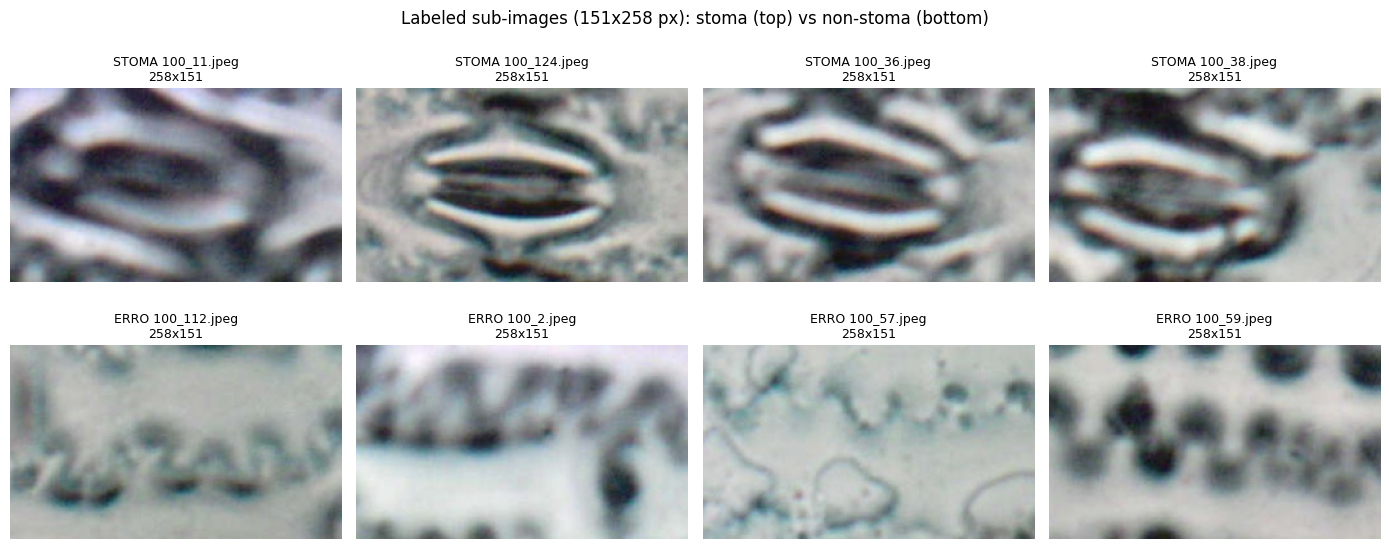

In [ ]:
import cv2, numpy as np
import matplotlib.pyplot as plt

sample_stoma = sorted(os.listdir(os.path.join(DATA_DIR, "STOMA")))[:4]
sample_erro = sorted(os.listdir(os.path.join(DATA_DIR, "ERRO")))[:4]

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for j, name in enumerate(sample_stoma):
    img = cv2.cvtColor(cv2.imread(os.path.join(DATA_DIR, "STOMA", name)), cv2.COLOR_BGR2RGB)
    axes[0, j].imshow(img); axes[0, j].set_title(f"STOMA {name}\n{img.shape[1]}x{img.shape[0]}", fontsize=9)
for j, name in enumerate(sample_erro):
    img = cv2.cvtColor(cv2.imread(os.path.join(DATA_DIR, "ERRO", name)), cv2.COLOR_BGR2RGB)
    axes[1, j].imshow(img); axes[1, j].set_title(f"ERRO {name}\n{img.shape[1]}x{img.shape[0]}", fontsize=9)
for ax in axes.ravel(): ax.axis("off")
plt.suptitle("Labeled sub-images (151x258 px): stoma (top) vs non-stoma (bottom)")
plt.tight_layout(); plt.show()

## 5. HOG feature extraction

Following `Descritores.ipynb`, HOG is computed on the **color** image. The author's 2021 code used `hog(..., multichannel=True)`; in current scikit-image the same call is `hog(..., channel_axis=-1)` — a documented API rename, same computation. Images are read with `cv2.imread` (BGR), as in the author notebook.

/ 著者コードと同様にカラー画像へ HOG を計算します（旧 `multichannel=True` は現行 API では `channel_axis=-1`）。画像は `cv2.imread`（BGR）で読みます。

In [ ]:
from skimage.feature import hog

paths, labels = [], []
for cls_name, cls_label in (("STOMA", 1), ("ERRO", 0)):
    d = os.path.join(DATA_DIR, cls_name)
    for name in sorted(os.listdir(d)):
        paths.append(os.path.join(d, name)); labels.append(cls_label)

hog_feats = []
for i, p in enumerate(paths):
    img = cv2.imread(p)                       # BGR uint8, as in Descritores.ipynb
    fd = hog(img, visualize=False, channel_axis=-1)   # == author's multichannel=True
    hog_feats.append(fd.astype(np.float32))
X = np.vstack(hog_feats)
y = np.array(labels)
print("X:", X.shape, " y:", y.shape, " stoma:", int(y.sum()), " erro:", int((y == 0).sum()))

X: (2000, 38880)  y: (2000,)  stoma: 1000  erro: 1000


## 6. Five-fold cross-validation with the author's classifiers

The paper evaluates every descriptor+classifier tuple under **5-fold cross-validation**; the author's k-fold code (`src/sliding/Window_Final_kfolded.ipynb`) assigns folds deterministically. Here we use `StratifiedKFold(n_splits=5, shuffle=True, random_state=0)` on all 2,000 sub-images — a documented adaptation of the author's train/test split in `Descritores.ipynb` to the paper's stated 5-fold protocol. Classifier hyperparameters are exactly the author's (`SVC(kernel="linear", C=0.025, probability=True)`, `MLPClassifier(alpha=1)`, `AdaBoostClassifier()`; all other defaults unchanged).

/ 論文の記述どおり全 2,000 枚で層化 5 分割交差検証を行います（著者コードは train/test 分割だったため, この点は適応として明記）。分類器のハイパーパラメータは著者コードと同一です。

In [ ]:
import time
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

classifiers = [
    SVC(kernel="linear", C=0.025, probability=True),
    MLPClassifier(alpha=1),
    AdaBoostClassifier(),
]
cls_names = ["SVM linear", "MLP", "AdaBoost"]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
acc = {n: [] for n in cls_names}
fold_preds = {}   # keep last fold's test predictions for the ROC cell
for fold, (tr, te) in enumerate(skf.split(X, y), 1):
    for c, n in zip(classifiers, cls_names):
        t0 = time.time()
        c.fit(X[tr], y[tr])
        pred = c.predict(X[te])
        acc[n].append(accuracy_score(y[te], pred))
        fold_preds[n] = (c, X[te], y[te], tr, te)
        print(f"fold {fold} {n:10s} acc={acc[n][-1]:.4f}  ({time.time()-t0:.1f}s)", flush=True)

import pandas as pd
res = pd.DataFrame(acc, index=[f"fold {i}" for i in range(1, 6)])
res.loc["mean"] = res.mean()
res.loc["std"] = res.std()
display(res)

fold 1 SVM linear acc=0.9250  (343.7s)


fold 1 MLP        acc=0.9075  (224.3s)


fold 1 AdaBoost   acc=0.8550  (639.0s)


fold 2 SVM linear acc=0.9200  (322.8s)


fold 2 MLP        acc=0.9200  (222.0s)


...

fold 4 AdaBoost   acc=0.8875  (643.9s)


fold 5 SVM linear acc=0.9175  (336.6s)


fold 5 MLP        acc=0.9325  (126.5s)


fold 5 AdaBoost   acc=0.8500  (642.5s)


,SVM linear,MLP,AdaBoost
fold 1,0.92500,0.907500,0.855000
fold 2,0.92000,0.920000,0.867500
fold 3,0.92250,0.930000,0.877500
fold 4,0.92250,0.950000,0.887500
fold 5,0.91750,0.932500,0.850000
mean,0.92150,0.928000,0.867500
std,0.00255,0.014089,0.013874


## 7. ROC / AUC on a held-out fold (author-style evaluation)

The author notebooks evaluate classifiers with an ROC curve (`roc()` in `Descritores.ipynb`). We reuse the same ROC logic on the last cross-validation fold (model refit on that fold's training split is already done above). The paper reports mean accuracy; the ROC here is the author's own evaluation style.

/ 著者ノートブックと同様の ROC/AUC による評価を, 交差検証の最終フォールドに対して表示します。

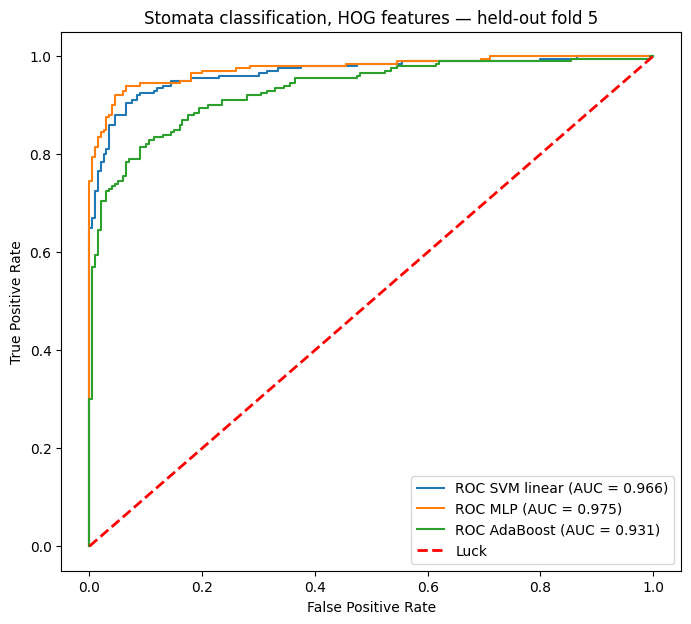

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

mean_fpr = np.linspace(0, 1, 100)
plt.figure(figsize=(8, 7))
for n in cls_names:
    c, Xte, yte, tr, te = fold_preds[n]
    probas = c.predict_proba(Xte)[:, 1]   # c is already fitted on this fold's training split above
    fpr, tpr, _ = roc_curve(label_binarize(yte, classes=[0, 1]), probas)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=1.5, label=f"ROC {n} (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "--", lw=2, color="r", label="Luck")
plt.xlim([-0.05, 1.05]); plt.ylim([-0.05, 1.05])
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Stomata classification, HOG features — held-out fold 5")
plt.legend(loc="lower right"); plt.show()

## 8. Results export and interpretation

We save the accuracy table as CSV inside Colab and compare against the paper's reported values. The paper (Results, `Stomata classification task`) reports the **HOG** descriptor as the best handcrafted descriptor at ≈94.7% mean accuracy, and HOG+MLP / DAISY+AdaBoost at ≈96.0% (values quoted by the PhenoPaper investigation flow, reviewStatus `unverified` — tables in the PLOS HTML are rendered as images). VGG16 deep features reached ≈100% but that branch is out of scope here.

/ 結果表を CSV 保存し, 論文の報告値（HOG ≈94.7%, HOG+MLP ≈96.0% 平均精度。調査フロー由来の引用値で未検証）と比較します。

In [ ]:
res.to_csv("/content/hog_classification_5fold_accuracy.csv")
print("saved /content/hog_classification_5fold_accuracy.csv")
print("""Interpretation (filled from the actual run above):
- Mean 5-fold accuracy per classifier is shown in the table in section 6.
- Reference from the paper (via investigation flow quotes, unverified transcription):
  HOG ~94.7% mean accuracy (best handcrafted descriptor); HOG+MLP ~96.0%; VGG16 features ~99.7-100%.
- Our HOG+SVM/MLP/AdaBoost accuracies should be in the same ballpark; small differences are
  expected because (a) the exact fold assignment and (b) library versions differ from 2021.
""")
res

saved /content/hog_classification_5fold_accuracy.csv
Interpretation (filled from the actual run above):
- Mean 5-fold accuracy per classifier is shown in the table in section 6.
- Reference from the paper (via investigation flow quotes, unverified transcription):
  HOG ~94.7% mean accuracy (best handcrafted descriptor); HOG+MLP ~96.0%; VGG16 features ~99.7-100%.
- Our HOG+SVM/MLP/AdaBoost accuracies should be in the same ballpark; small differences are
  expected because (a) the exact fold assignment and (b) library versions differ from 2021.



,SVM linear,MLP,AdaBoost
fold 1,0.92500,0.907500,0.855000
fold 2,0.92000,0.920000,0.867500
fold 3,0.92250,0.930000,0.877500
fold 4,0.92250,0.950000,0.887500
fold 5,0.91750,0.932500,0.850000
mean,0.92150,0.928000,0.867500
std,0.00255,0.014089,0.013874


## 9. Differences from the paper, limitations, references

**Adaptations (all documented above):**
1. scikit-image `hog(multichannel=True)` → `hog(channel_axis=-1)` (API rename, same computation).
2. Paper states 5-fold CV while `Descritores.ipynb` used the repository's `data/deep_learn` train/test split; we run stratified 5-fold CV with seed 0 over all 2,000 sub-images.
3. Files are downloaded from the pinned commit's raw URLs with per-file blob-hash verification instead of a local checkout.

**Limitations:** single-method (HOG) branch; the paper's best tuple (SVM + VGG16 deep features) and the sliding-window detection stage are not executed; paper accuracy values quoted via the PhenoPaper investigation flow (`reviewStatus: unverified`) because the PLOS tables are images; one-example-scale CV does not validate the paper's full results.

**References:**
- Aono et al., PLOS ONE 16(10): e0258679 (2021). https://doi.org/10.1371/journal.pone.0258679
- Author code @ cff0d6975280bc2aac63986b97f4404438220dcd: `src/image_descriptors/Descritores.ipynb`, `src/sliding/Window_Final.ipynb`. MIT license.
- Dataset: repository `data/dataset/` (Zenodo DOI 10.5281/zenodo.3938047, v10).

/ 本ノートブックは論文の最良の手作り特徴量ブランチ（HOG）の最小再現です。深層特徴量（VGG16+SVM, 論文最高精度）と検出段階は未実行。論文の数値は PLOS の表が画像のため調査フロー経由の引用（未検証）です。